### Import de base

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import json
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, 
    Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D,
    Bidirectional, Reshape
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime, timedelta
import joblib

c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.3

### Chargement des données

In [ ]:
# 2. Chargement des données
df = pd.read_csv('simulated_poultry_data_2018_2025_enhanced.csv') 

# 3. Inspection initiale
print("=== FORMES ET TYPES ===")
print(f"Shape: {df.shape}")
print(f"Colonnes: {df.columns.tolist()}")
print("\n=== INFO DES TYPES ===")
print(df.info())
print("\n=== PREMIERES LIGNES ===")
display(df.head(3))
print("\n=== STATISTIQUES DESCRIPTIVES ===")
display(df.describe())

# 4. Vérification temporelle critique
print("\n=== ANALYSE TEMPORELLE ===")
print(f"Plage de dates: {df['ts'].min()} -> {df['ts'].max()}")
print(f"Fréquence approx: {(pd.to_datetime(df['ts'].max()) - pd.to_datetime(df['ts'].min())) / len(df)}")

# 5. Vérification des capteurs
print("\n=== ANALYSE CAPTEURS ===")
print(f"Nombre de capteurs uniques: {df['device_id'].nunique()}")
print("Répartition par capteur:")
print(df['device_id'].value_counts())

=== FORMES ET TYPES ===
Shape: (70105, 10)
Colonnes: ['ts', 'device_id', 'temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3', 'motion', 'light']

=== INFO DES TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70105 entries, 0 to 70104
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ts         70105 non-null  object 
 1   device_id  70105 non-null  object 
 2   temp       70105 non-null  float64
 3   humidity   70105 non-null  float64
 4   co         70105 non-null  float64
 5   lpg        70105 non-null  float64
 6   smoke      70105 non-null  float64
 7   nh3        70105 non-null  float64
 8   motion     70105 non-null  int64  
 9   light      70105 non-null  int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 5.3+ MB
None

=== PREMIERES LIGNES ===


,ts,device_id,temp,humidity,co,lpg,smoke,nh3,motion,light
0,2018-01-01 00:00:00,sensor_1,20.68,56.53,0.002264,0.001767,0.001161,0.010267,0,0
1,2018-01-01 01:00:00,sensor_1,20.15,61.93,0.000943,0.000569,0.001181,0.012503,0,0
2,2018-01-01 02:00:00,sensor_1,19.64,64.05,0.003225,0.001192,0.001317,0.012954,1,1



=== STATISTIQUES DESCRIPTIVES ===


,temp,humidity,co,lpg,smoke,nh3,motion,light
count,70105.000000,70105.000000,70105.000000,70105.000000,70105.000000,70105.000000,70105.000000,70105.000000
mean,21.613660,54.976149,0.005897,0.001012,0.001002,0.007207,0.364268,0.692419
std,2.532287,5.854167,0.004398,0.000520,0.000314,0.003910,0.481228,0.461496
min,18.000000,40.000000,0.000000,0.000000,0.000002,0.000000,0.000000,0.000000
25%,19.480000,50.770000,0.002106,0.000662,0.000799,0.004208,0.000000,0.000000
50%,21.500000,54.950000,0.005006,0.001000,0.001001,0.007108,0.000000,1.000000
75%,23.530000,59.240000,0.009095,0.001338,0.001203,0.010002,1.000000,1.000000
max,28.000000,70.000000,0.030000,0.020000,0.012633,0.037127,1.000000,1.000000



=== ANALYSE TEMPORELLE ===
Plage de dates: 2018-01-01 00:00:00 -> 2025-12-31 00:00:00
Fréquence approx: 0 days 00:59:59.948648455

=== ANALYSE CAPTEURS ===
Nombre de capteurs uniques: 1
Répartition par capteur:
device_id
sensor_1    70105
Name: count, dtype: int64


=== ÉTAPE 2 - ANALYSIS TEMPORELLE APPROFONDIE ===
Intervalle moyen: 0 days 01:00:00
Gaps temporels identifiés: 0
Timestamps dupliqués: 0

=== RÉPARTITION PAR ANNÉE ===
year
2018    8760
2019    8760
2020    8784
2021    8760
2022    8760
2023    8760
2024    8784
2025    8737
Name: count, dtype: int64

=== VALEURS NULLES PAR COLONNE ===
ts           0
device_id    0
temp         0
humidity     0
co           0
lpg          0
smoke        0
nh3          0
motion       0
light        0
year         0
month        0
hour         0
dtype: int64

=== OUTLIERS POTENTIELS (IQR) ===
temp          0
humidity      0
co           24
lpg         294
smoke       528
nh3          86
dtype: int64


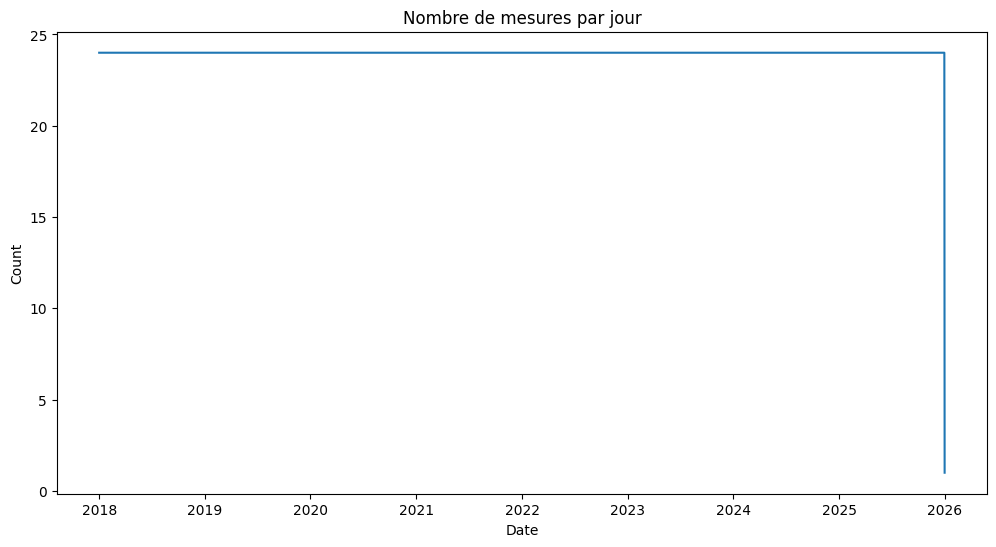

In [8]:
print("=== ÉTAPE 2 - ANALYSIS TEMPORELLE APPROFONDIE ===")

# 1. Conversion du timestamp
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values('ts').reset_index(drop=True)

# 2. Analyse de la régularité temporelle
time_diff = df['ts'].diff()
print(f"Intervalle moyen: {time_diff.mean()}")
print(f"Gaps temporels identifiés: {(time_diff > pd.Timedelta(hours=1.5)).sum()}")

# 3. Vérification des doublons temporels
duplicate_times = df['ts'].duplicated().sum()
print(f"Timestamps dupliqués: {duplicate_times}")

# 4. Analyse de la complétude par année
df['year'] = df['ts'].dt.year
df['month'] = df['ts'].dt.month
df['hour'] = df['ts'].dt.hour

print("\n=== RÉPARTITION PAR ANNÉE ===")
yearly_counts = df['year'].value_counts().sort_index()
print(yearly_counts)

# 5. Vérification des valeurs nulles potentielles
print("\n=== VALEURS NULLES PAR COLONNE ===")
print(df.isnull().sum())

# 6. Détection rapide d'outliers (méthode IQR)
Q1 = df[['temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3']].quantile(0.25)
Q3 = df[['temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3']].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[['temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3']] < (Q1 - 1.5 * IQR)) | 
           (df[['temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3']] > (Q3 + 1.5 * IQR))).sum()
print("\n=== OUTLIERS POTENTIELS (IQR) ===")
print(outliers)

# 7. Visualisation rapide de la distribution temporelle
plt.figure(figsize=(12, 6))
df.groupby(df['ts'].dt.date).size().plot()
plt.title('Nombre de mesures par jour')
plt.ylabel('Count')
plt.xlabel('Date')
plt.show()

=== ÉTAPE 3 - FEATURE ENGINEERING TEMPOREL ===
Nouvelles colonnes créées:
Total nouvelles features: 56
Exemples: ['year', 'month', 'hour', 'day_of_week', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_lag_1']

Shape après feature engineering: (70105, 66)

Valeurs manquantes après lag:
Total valeurs manquantes: 319


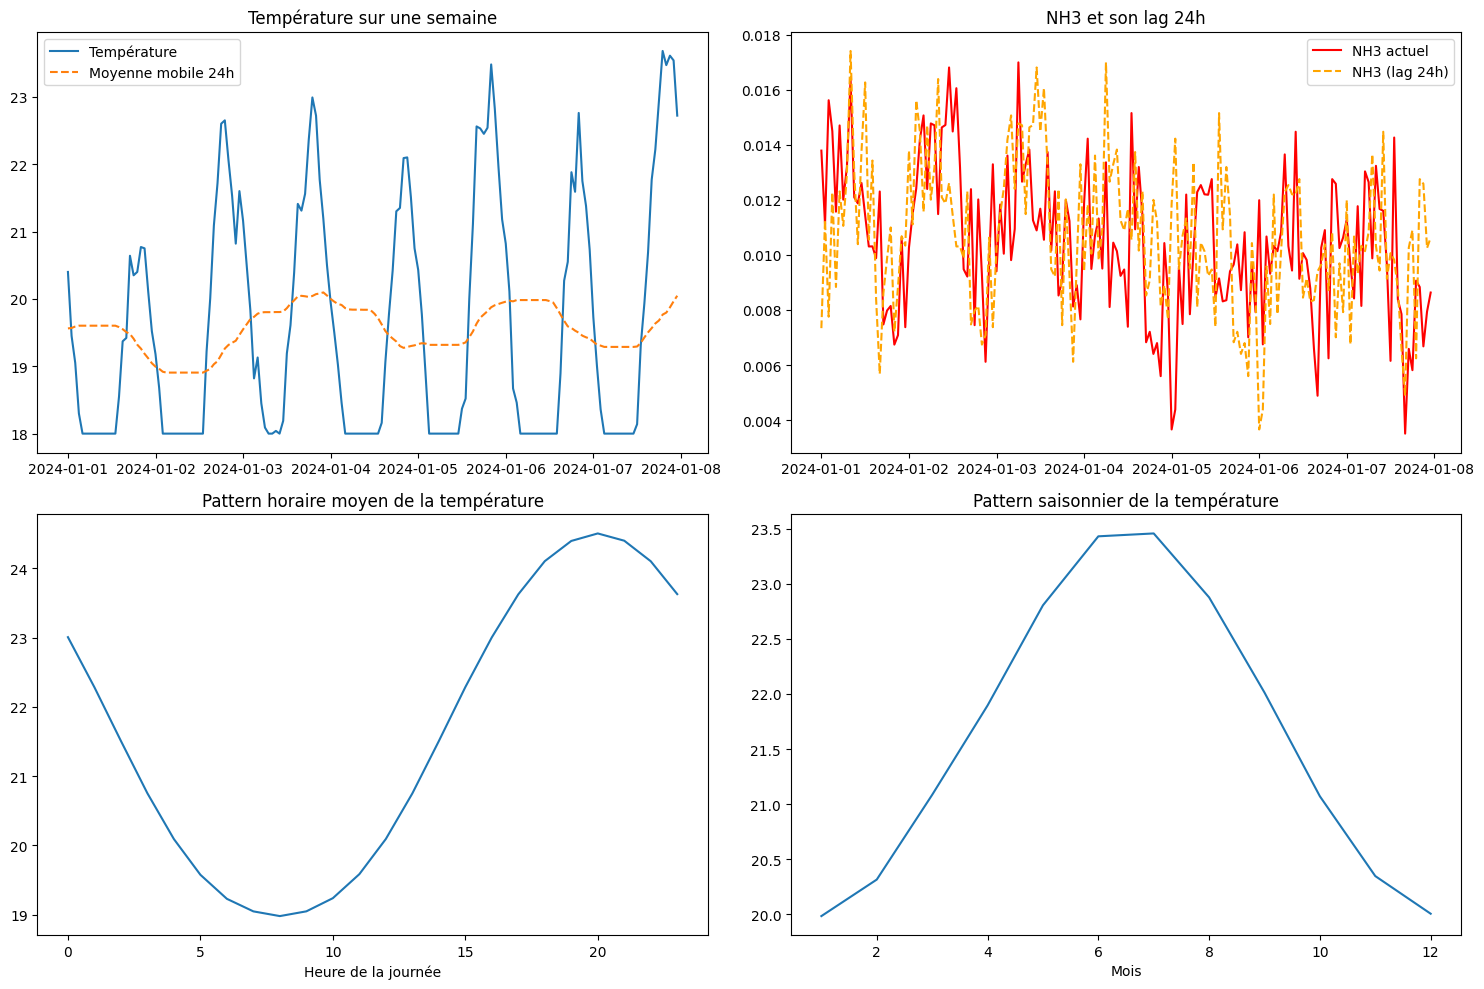

In [9]:
print("=== ÉTAPE 3 - FEATURE ENGINEERING TEMPOREL ===")

# 1. Features temporelles basiques
df['hour'] = df['ts'].dt.hour
df['day_of_week'] = df['ts'].dt.dayofweek
df['month'] = df['ts'].dt.month
df['day_of_year'] = df['ts'].dt.dayofyear

# 2. Encodage cyclique (très important pour les séries temporelles)
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

# 3. Features de lag pour les 4 variables cibles
lags = [1, 2, 3, 6, 12, 24]  # lag de 1h à 24h
for lag in lags:
    df[f'temp_lag_{lag}'] = df['temp'].shift(lag)
    df[f'humidity_lag_{lag}'] = df['humidity'].shift(lag)
    df[f'nh3_lag_{lag}'] = df['nh3'].shift(lag)
    df[f'co_lag_{lag}'] = df['co'].shift(lag)

# 4. Features de rolling statistics (moyennes mobiles)
windows = [6, 12, 24]  # 6h, 12h, 24h
for window in windows:
    df[f'temp_rolling_mean_{window}'] = df['temp'].rolling(window=window, min_periods=1).mean()
    df[f'temp_rolling_std_{window}'] = df['temp'].rolling(window=window, min_periods=1).std()
    df[f'humidity_rolling_mean_{window}'] = df['humidity'].rolling(window=window, min_periods=1).mean()

# 5. Features croisées (interactions entre variables)
df['temp_humidity_interaction'] = df['temp'] * df['humidity']
df['nh3_co_ratio'] = df['nh3'] / (df['co'] + 0.001)  # éviter division par zéro

# 6. Target variables pour prédiction multi-horizon
horizons = [1, 6, 24]  # prédire à 1h, 6h et 24h
target_variables = ['temp', 'humidity', 'nh3', 'co']

for horizon in horizons:
    for var in target_variables:
        df[f'{var}_target_{horizon}h'] = df[var].shift(-horizon)

# 7. Vérification des nouvelles features
print("Nouvelles colonnes créées:")
new_features = [col for col in df.columns if col not in ['ts', 'device_id', 'temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3', 'motion', 'light']]
print(f"Total nouvelles features: {len(new_features)}")
print("Exemples:", new_features[:10])

# 8. Analyse des données préparées
print(f"\nShape après feature engineering: {df.shape}")
print("\nValeurs manquantes après lag:")
missing_after_lag = df[new_features].isnull().sum().sum()
print(f"Total valeurs manquantes: {missing_after_lag}")

# 9. Visualisation des relations temporelles
plt.figure(figsize=(15, 10))

# Température sur une semaine exemple
plt.subplot(2, 2, 1)
sample_week = df[(df['ts'] >= '2024-01-01') & (df['ts'] < '2024-01-08')]
plt.plot(sample_week['ts'], sample_week['temp'], label='Température')
plt.plot(sample_week['ts'], sample_week['temp_rolling_mean_24'], label='Moyenne mobile 24h', linestyle='--')
plt.title('Température sur une semaine')
plt.legend()

# NH3 avec lag
plt.subplot(2, 2, 2)
plt.plot(sample_week['ts'], sample_week['nh3'], label='NH3 actuel', color='red')
plt.plot(sample_week['ts'], sample_week['nh3_lag_24'], label='NH3 (lag 24h)', color='orange', linestyle='--')
plt.title('NH3 et son lag 24h')
plt.legend()

# Pattern horaire de la température
plt.subplot(2, 2, 3)
hourly_pattern = df.groupby('hour')['temp'].mean()
plt.plot(hourly_pattern.index, hourly_pattern.values)
plt.title('Pattern horaire moyen de la température')
plt.xlabel('Heure de la journée')

# Pattern saisonnier (mensuel)
plt.subplot(2, 2, 4)
monthly_pattern = df.groupby('month')['temp'].mean()
plt.plot(monthly_pattern.index, monthly_pattern.values)
plt.title('Pattern saisonnier de la température')
plt.xlabel('Mois')

plt.tight_layout()
plt.show()

### FENÊTRAGE TEMPOREL POUR LEARNING

In [54]:
print("=== ÉTAPE 4 - FENÊTRAGE TEMPOREL POUR LEARNING ===")

# 1. Nettoyage des NaN (les premières lignes à cause des lags)
df_clean = df.dropna().reset_index(drop=True)
print(f"Shape après suppression des NaN: {df_clean.shape}")
print(f"Pourcentage de données conservées: {len(df_clean)/len(df)*100:.2f}%")

# 2. Définition des paramètres de fenêtrage
WINDOW_SIZE = 24 * 7  # 1 semaine de historique (168 heures)
HORIZON = 24          # Prédire les 24 prochaines heures
STRIDE = 1            # Pas de 1 heure entre les fenêtres

print(f"\nParamètres de fenêtrage:")
print(f"Window size (historique): {WINDOW_SIZE} heures")
print(f"Horizon (prédiction): {HORIZON} heures")
print(f"Stride: {STRIDE} heure(s)")

# 3. Sélection des features et targets
feature_columns = [col for col in df_clean.columns if col not in [
    'ts', 'device_id', 'year', 'month', 'hour', 'day_of_week', 'day_of_year'  # On garde les versions cycliques
] and not col.endswith('_target_1h') and not col.endswith('_target_6h') and not col.endswith('_target_24h')]

target_columns = ['temp_target_1h', 'temp_target_6h', 'temp_target_24h', 
                  'humidity_target_1h', 'humidity_target_6h', 'humidity_target_24h',
                  'nh3_target_1h', 'nh3_target_6h', 'nh3_target_24h',
                  'co_target_1h', 'co_target_6h', 'co_target_24h']

print(f"\nNombre de features: {len(feature_columns)}")
print(f"Nombre de targets: {len(target_columns)}")

# 4. Fonction de fenêtrage adaptée à notre cas
def create_sequential_windows(features, targets, window_size, horizon, stride):
    """
    Crée des fenêtres séquentielles pour l'apprentissage supervisé
    """
    X, y = [], []
    n_samples = len(features)
    
    for start_idx in range(0, n_samples - window_size - horizon + 1, stride):
        end_idx = start_idx + window_size
        target_idx = end_idx + horizon - 1  # On prend le dernier point de l'horizon
        
        # Features: fenêtre historique
        window_features = features[start_idx:end_idx]
        
        # Targets: valeurs à l'horizon pour les 4 variables
        window_targets = targets.iloc[target_idx][[
            'temp_target_1h', 'humidity_target_1h', 'nh3_target_1h', 'co_target_1h',
            'temp_target_6h', 'humidity_target_6h', 'nh3_target_6h', 'co_target_6h', 
            'temp_target_24h', 'humidity_target_24h', 'nh3_target_24h', 'co_target_24h'
        ]].values
        
        X.append(window_features)
        y.append(window_targets)
    
    return np.array(X), np.array(y)

# 5. Préparation des données pour le fenêtrage
features_data = df_clean[feature_columns].values
targets_data = df_clean[target_columns]

# 6. Création des fenêtres
X, y = create_sequential_windows(features_data, targets_data, WINDOW_SIZE, HORIZON, STRIDE)

print(f"\n=== RÉSULTATS DU FENÊTRAGE ===")
print(f"X shape: {X.shape}")  # (échantillons, fenêtre, features)
print(f"y shape: {y.shape}")  # (échantillons, 12 targets)

# 7. Split temporel (CRITIQUE pour les séries temporelles)
total_samples = len(X)
train_size = int(0.7 * total_samples)  # 70% train
val_size = int(0.15 * total_samples)   # 15% validation

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f"\n=== SPLIT TEMPOREL ===")
print(f"Train: {len(X_train)} échantillons ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val: {len(X_val)} échantillons ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} échantillons ({len(X_test)/len(X)*100:.1f}%)")

# 8. Normalisation des données (par feature sur l'ensemble d'entraînement)
from sklearn.preprocessing import StandardScaler

# Scalers pour les features
feature_scalers = {}
X_train_scaled = np.zeros_like(X_train)
X_val_scaled = np.zeros_like(X_val)
X_test_scaled = np.zeros_like(X_test)

# Normalisation par feature
for feature_idx in range(X_train.shape[2]):
    scaler = StandardScaler()
    # On reshape pour avoir (samples * window_size, 1)
    feature_data = X_train[:, :, feature_idx].reshape(-1, 1)
    scaler.fit(feature_data)
    
    # Application à tous les sets
    X_train_scaled[:, :, feature_idx] = scaler.transform(
        X_train[:, :, feature_idx].reshape(-1, 1)
    ).reshape(X_train.shape[0], X_train.shape[1])
    
    X_val_scaled[:, :, feature_idx] = scaler.transform(
        X_val[:, :, feature_idx].reshape(-1, 1)
    ).reshape(X_val.shape[0], X_val.shape[1])
    
    X_test_scaled[:, :, feature_idx] = scaler.transform(
        X_test[:, :, feature_idx].reshape(-1, 1)
    ).reshape(X_test.shape[0], X_test.shape[1])
    
    feature_scalers[feature_idx] = scaler

print(f"\n=== NORMALISATION TERMINÉE ===")
print(f"Données d'entraînement scaled - Mean: {X_train_scaled.mean():.3f}, Std: {X_train_scaled.std():.3f}")

# 9. Vérification de la distribution temporelle des splits
split_dates = df_clean['ts'].iloc[WINDOW_SIZE:WINDOW_SIZE+len(X)]  # Dates correspondant aux fenêtres

print(f"\n=== PÉRIODES DES SPLITS ===")
print(f"Train: {split_dates.iloc[0].strftime('%Y-%m-%d')} -> {split_dates.iloc[train_size-1].strftime('%Y-%m-%d')}")
print(f"Val: {split_dates.iloc[train_size].strftime('%Y-%m-%d')} -> {split_dates.iloc[train_size+val_size-1].strftime('%Y-%m-%d')}")
print(f"Test: {split_dates.iloc[train_size+val_size].strftime('%Y-%m-%d')} -> {split_dates.iloc[-1].strftime('%Y-%m-%d')}")

# 10. Sauvegarde des métadonnées pour la reproduction
metadata = {
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'stride': STRIDE,
    'feature_columns': feature_columns,
    'target_columns': target_columns,
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'input_shape': X_train_scaled.shape[1:],
    'output_shape': y_train.shape[1]
}

print(f"\n=== MÉTADONNÉES ===")
for key, value in metadata.items():
    if key not in ['feature_columns', 'target_columns']:
        print(f"{key}: {value}")

print(f"\nShape d'entrée du modèle: {metadata['input_shape']}")
print(f"Shape de sortie du modèle: {metadata['output_shape']}")




=== ÉTAPE 4 - FENÊTRAGE TEMPOREL POUR LEARNING ===
Shape après suppression des NaN: (70057, 66)
Pourcentage de données conservées: 99.93%

Paramètres de fenêtrage:
Window size (historique): 168 heures
Horizon (prédiction): 24 heures
Stride: 1 heure(s)

Nombre de features: 47
Nombre de targets: 12

=== RÉSULTATS DU FENÊTRAGE ===
X shape: (69866, 168, 47)
y shape: (69866, 12)

=== SPLIT TEMPOREL ===
Train: 48906 échantillons (70.0%)
Val: 10479 échantillons (15.0%)
Test: 10481 échantillons (15.0%)

=== NORMALISATION TERMINÉE ===
Données d'entraînement scaled - Mean: 0.000, Std: 1.000

=== PÉRIODES DES SPLITS ===
Train: 2018-01-09 -> 2023-08-08
Val: 2023-08-08 -> 2024-10-18
Test: 2024-10-18 -> 2025-12-29

=== MÉTADONNÉES ===
window_size: 168
horizon: 24
stride: 1
train_size: 48906
val_size: 10479
test_size: 10481
input_shape: (168, 47)
output_shape: 12

Shape d'entrée du modèle: (168, 47)
Shape de sortie du modèle: 12


In [ ]:
# 11. CRÉATION DU DOSSIER ET SAUVEGARDE DES SCALERS
print("\n=== CRÉATION DU DOSSIER ET SAUVEGARDE DES SCALERS ===")

# Création du dossier pour sauvegarder les modèles et scalers
MODEL_DIR = "saved_models_hybrid"
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Dossier créé: {MODEL_DIR}")

# Sauvegarde des scalers des features
scaler_path = os.path.join(MODEL_DIR, 'feature_scalers.pkl')
joblib.dump(feature_scalers, scaler_path)
print(f"Feature scalers sauvegardés dans: {scaler_path}")

# Sauvegarde des noms de features pour référence
feature_info = {
    'feature_columns': feature_columns,
    'feature_indices': {col: idx for idx, col in enumerate(feature_columns)},
    'num_features': len(feature_columns),
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON
}

with open(os.path.join(MODEL_DIR, 'feature_info.json'), 'w') as f:
    json.dump(feature_info, f, indent=2)

print(f"Informations des features sauvegardées")

# Sauvegarde des métadonnées complètes
metadata = {
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'stride': STRIDE,
    'feature_columns': feature_columns,
    'target_columns': target_columns,
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'input_shape': X_train_scaled.shape[1:],
    'output_shape': y_train.shape[1],
    'feature_scalers_path': scaler_path,
    'saved_at': datetime.now().isoformat()
}

with open(os.path.join(MODEL_DIR, 'preprocessing_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Métadonnées de preprocessing sauvegardées")

# Vérification 
print(f"Nombre de scalers sauvegardés: {len(feature_scalers)}")

# CORRECTION : Accès correct aux attributs du scaler
if len(feature_scalers) > 0:
    print(f"Exemple de scaler pour la feature 0: mean={feature_scalers[0].mean_[0]:.3f}, scale={feature_scalers[0].scale_[0]:.3f}")
else:
    print("Aucun scaler disponible pour l'affichage")

# Affichage du contenu du dossier
print(f"\nContenu du dossier {MODEL_DIR}:")
for file in os.listdir(MODEL_DIR):
    file_path = os.path.join(MODEL_DIR, file)
    file_size = os.path.getsize(file_path) / 1024  # Taille en KB
    print(f"  • {file} ({file_size:.1f} KB)")


=== CRÉATION DU DOSSIER ET SAUVEGARDE DES SCALERS ===
Dossier créé: saved_models_hybrid
Feature scalers sauvegardés dans: saved_models_hybrid/feature_scalers.pkl
Informations des features sauvegardées
Métadonnées de preprocessing sauvegardées
Nombre de scalers sauvegardés: 47
Exemple de scaler pour la feature 0: mean=21.634, scale=2.538

Contenu du dossier saved_models_hybrid:
  • feature_info.json (2.1 KB)
  • model_metadata.json (0.4 KB)
  • learning_curves_hybrid.png (346.7 KB)
  • preprocessing_metadata.json (1.5 KB)
  • cnn_bilstm_attention_model.h5 (2773.1 KB)
  • feature_scalers.pkl (11.4 KB)
  • training_history.npy (3.6 KB)


### MODÈLE HYBRIDE CNN-BiLSTM-ATTENTION

In [11]:
# 1. CONFIGURATION
print("1. Configuration du modèle hybride...")

MODEL_DIR = "saved_models_hybrid"
os.makedirs(MODEL_DIR, exist_ok=True)

# 2. ARCHITECTURE CNN-BiLSTM-ATTENTION
def create_cnn_bilstm_attention_model(input_shape, output_dim):
    """Crée un modèle hybride CNN-BiLSTM-Attention"""
    
    # Entrée
    inputs = Input(shape=input_shape, name='input_layer')
    
    # ===== PARTIE CNN =====
    # Première couche Conv1D
    x = Conv1D(filters=64, kernel_size=3, activation='relu', 
               padding='same', name='conv1d_1')(inputs)
    x = MaxPooling1D(pool_size=2, name='max_pool_1')(x)
    x = Dropout(0.2, name='dropout_1')(x)
    
    # Deuxième couche Conv1D
    x = Conv1D(filters=128, kernel_size=3, activation='relu', 
               padding='same', name='conv1d_2')(x)
    x = MaxPooling1D(pool_size=2, name='max_pool_2')(x)
    x = Dropout(0.2, name='dropout_2')(x)
    
    # ===== PARTIE BiLSTM =====
    x = Bidirectional(
        LSTM(64, return_sequences=True, name='bilstm_1'), 
        name='bidirectional_1'
    )(x)
    x = Dropout(0.3, name='dropout_3')(x)
    
    x = Bidirectional(
        LSTM(32, return_sequences=True, name='bilstm_2'), 
        name='bidirectional_2'
    )(x)
    x = Dropout(0.3, name='dropout_4')(x)
    
    # ===== PARTIE ATTENTION =====
    # Multi-Head Attention
    attention_output = MultiHeadAttention(
        num_heads=4, 
        key_dim=32,
        dropout=0.1,
        name='multi_head_attention'
    )(x, x)
    
    # Skip connection + Layer Normalization
    x = LayerNormalization(name='layer_norm_1')(x + attention_output)
    
    # ===== PARTIE CLASSIFICATION =====
    # Global Average Pooling
    x = GlobalAveragePooling1D(name='global_avg_pooling')(x)
    
    # Couches denses finales
    x = Dense(128, activation='relu', name='dense_1')(x)
    x = Dropout(0.2, name='dropout_5')(x)
    
    x = Dense(64, activation='relu', name='dense_2')(x)
    x = Dropout(0.1, name='dropout_6')(x)
    
    # Sortie multi-cibles
    outputs = Dense(output_dim, activation='linear', name='output_layer')(x)
    
    # Création du modèle
    model = Model(inputs=inputs, outputs=outputs, name='CNN_BiLSTM_Attention')
    
    return model

1. Configuration du modèle hybride...


### CRÉATION ET COMPILATION DU MODÈLE

In [12]:
# 3. CRÉATION ET COMPILATION DU MODÈLE
print("2. Création et compilation du modèle...")

input_shape = (WINDOW_SIZE, len(feature_columns))
output_dim = y_train.shape[1]  # 12 cibles

# Création du modèle
hybrid_model = create_cnn_bilstm_attention_model(input_shape, output_dim)

# Compilation
hybrid_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mse']
)

print(f" Modèle créé avec succès!")
print(f" Architecture:")
hybrid_model.summary()

2. Création et compilation du modèle...
 Modèle créé avec succès!
 Architecture:
Model: "CNN_BiLSTM_Attention"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, 168, 47)]            0         []                            
                                                                                                  
 conv1d_1 (Conv1D)           (None, 168, 64)              9088      ['input_layer[0][0]']         
                                                                                                  
 max_pool_1 (MaxPooling1D)   (None, 84, 64)               0         ['conv1d_1[0][0]']            
                                                                                                  
 dropout_1 (Dropout)         (None, 84, 64)               0         ['max_pool_1[0][0]']         

### Configuration des callbacks

In [13]:
# 4. CALLBACKS
print("3. Configuration des callbacks...")

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1
    )
]

3. Configuration des callbacks...


### ENTRAÎNEMENT

In [14]:
# 5. ENTRAÎNEMENT
print("4. Début de l'entraînement...")

history = hybrid_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(" Entraînement terminé!")

4. Début de l'entraînement...
Epoch 1/100
1529/1529 [==============================] - 110s 66ms/step - loss: 27.2904 - mae: 2.6767 - mse: 27.2904 - val_loss: 3.2674 - val_mae: 0.9791 - val_mse: 3.2674 - lr: 0.0010
Epoch 2/100
1529/1529 [==============================] - 99s 65ms/step - loss: 9.1421 - mae: 1.6024 - mse: 9.1421 - val_loss: 2.1889 - val_mae: 0.7739 - val_mse: 2.1889 - lr: 0.0010
Epoch 3/100
1529/1529 [==============================] - 99s 65ms/step - loss: 8.2727 - mae: 1.5109 - mse: 8.2727 - val_loss: 2.0580 - val_mae: 0.7436 - val_mse: 2.0580 - lr: 0.0010
Epoch 4/100
1529/1529 [==============================] - 101s 66ms/step - loss: 7.8131 - mae: 1.4621 - mse: 7.8131 - val_loss: 2.0403 - val_mae: 0.7412 - val_mse: 2.0403 - lr: 0.0010
Epoch 5/100
1529/1529 [==============================] - 109s 71ms/step - loss: 7.4466 - mae: 1.4284 - mse: 7.4466 - val_loss: 2.0657 - val_mae: 0.7494 - val_mse: 2.0657 - lr: 0.0010
Epoch 6/100
1529/1529 [==============================] 

### ÉVALUATION


In [15]:
# 6. ÉVALUATION
print("5. Évaluation du modèle...")

# Prédictions
y_pred_hybrid = hybrid_model.predict(X_test_scaled, verbose=0)

# Métriques

mae_hybrid = mean_absolute_error(y_test, y_pred_hybrid)
rmse_hybrid = np.sqrt(mean_squared_error(y_test, y_pred_hybrid))
r2_hybrid = r2_score(y_test, y_pred_hybrid)

print(f" PERFORMANCE DU MODÈLE HYBRIDE:")
print(f"   • MAE: {mae_hybrid:.4f}")
print(f"   • RMSE: {rmse_hybrid:.4f}")
print(f"   • R²: {r2_hybrid:.4f}")

5. Évaluation du modèle...
 PERFORMANCE DU MODÈLE HYBRIDE:
   • MAE: 0.7126
   • RMSE: 1.3854
   • R²: 0.4457


### VISUALISATION DE L'APPRENTISSAGE

6. Visualisation des courbes d'apprentissage...


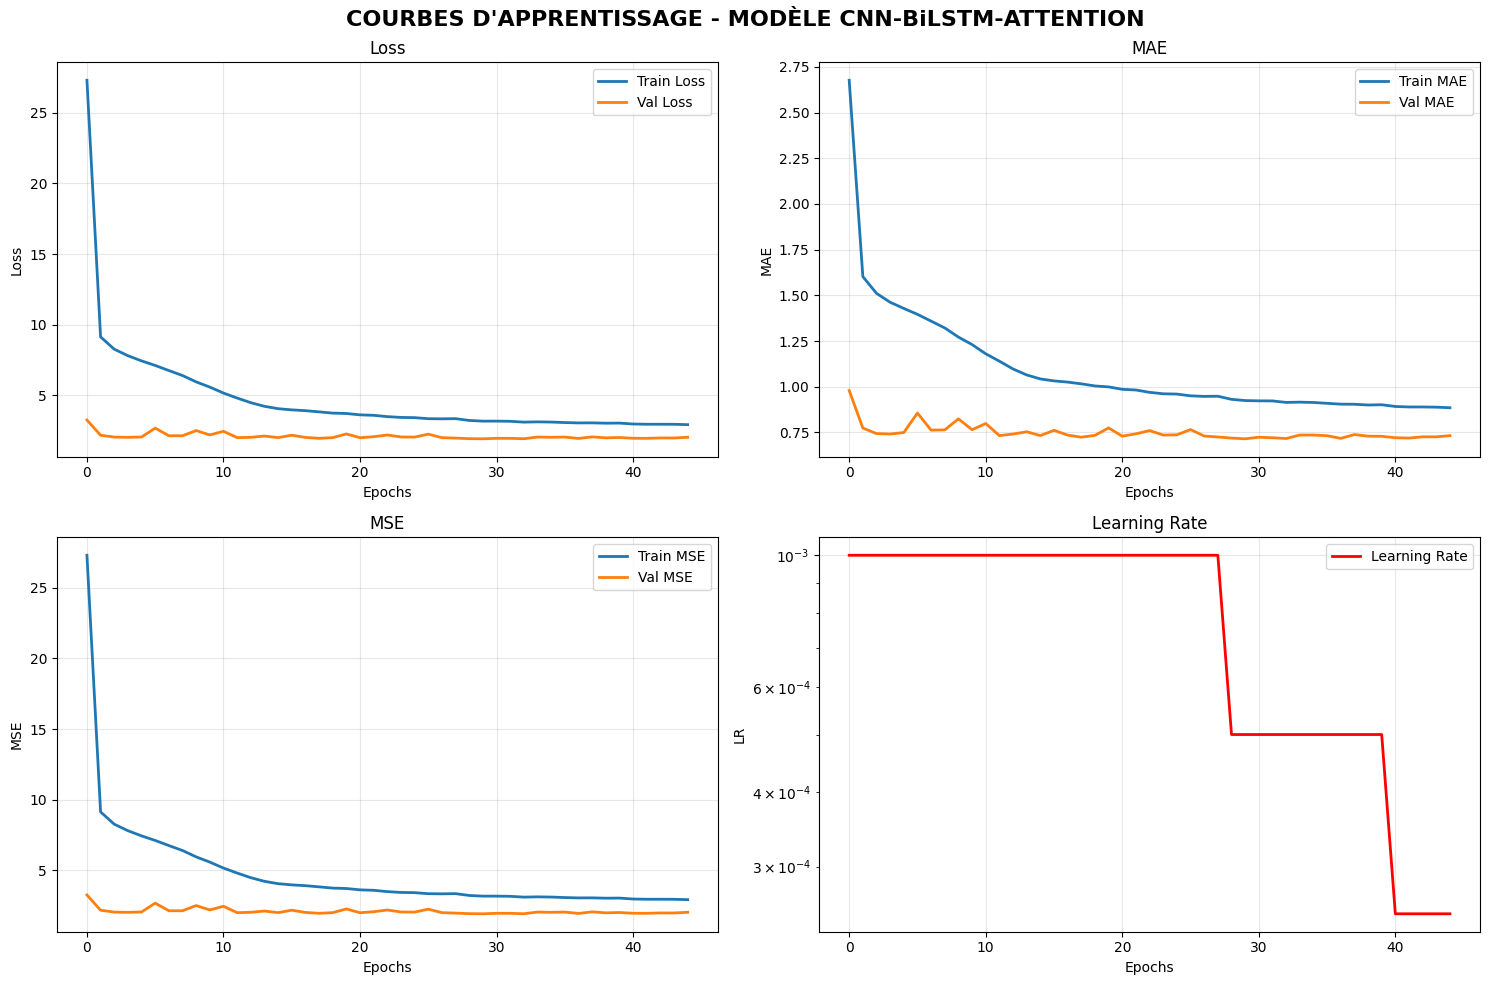

In [16]:
# 7. VISUALISATION DE L'APPRENTISSAGE
print("6. Visualisation des courbes d'apprentissage...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('COURBES D\'APPRENTISSAGE - MODÈLE CNN-BiLSTM-ATTENTION', 
             fontsize=16, fontweight='bold')

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE
axes[0, 1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[0, 1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[0, 1].set_title('MAE')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# MSE
axes[1, 0].plot(history.history['mse'], label='Train MSE', linewidth=2)
axes[1, 0].plot(history.history['val_mse'], label='Val MSE', linewidth=2)
axes[1, 0].set_title('MSE')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
if 'lr' in history.history:
    axes[1, 1].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='red')
    axes[1, 1].set_title('Learning Rate')
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'learning_curves_hybrid.png'), dpi=300, bbox_inches='tight')
plt.show()


### SAUVEGARDE DU MODÈLE

In [17]:
# 8. SAUVEGARDE DU MODÈLE
print("7. Sauvegarde du modèle...")

# Sauvegarde du modèle
hybrid_model.save(os.path.join(MODEL_DIR, 'cnn_bilstm_attention_model.h5'))

# Sauvegarde de l'historique
np.save(os.path.join(MODEL_DIR, 'training_history.npy'), history.history)

# Métadonnées
metadata = {
    'model_type': 'CNN-BiLSTM-Attention Hybrid',
    'training_date': datetime.now().isoformat(),
    'input_shape': input_shape,
    'output_shape': output_dim,
    'performance': {
        'mae': float(mae_hybrid),
        'rmse': float(rmse_hybrid),
        'r2': float(r2_hybrid)
    },
    'training_parameters': {
        'epochs_trained': len(history.history['loss']),
        'best_epoch': len(history.history['loss']) - 15,  # Approximation early stopping
        'final_loss': float(history.history['loss'][-1]),
        'final_val_loss': float(history.history['val_loss'][-1])
    }
}

with open(os.path.join(MODEL_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f" Modèle sauvegardé dans: {MODEL_DIR}")

7. Sauvegarde du modèle...
 Modèle sauvegardé dans: saved_models_hybrid


/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### COMPARAISON AVEC BASELINES

In [18]:
# 9. COMPARAISON AVEC BASELINES
print("8. Comparaison avec les baselines...")

# Recalcul des baselines pour comparaison
baseline_persistence = np.zeros_like(y_test)
last_value_features = X_test[:, -1, :]

# Mapping simplifié pour la persistence
for i in range(y_test.shape[1]):
    if i % 4 == 0:  # temp
        baseline_persistence[:, i] = last_value_features[:, 0]
    elif i % 4 == 1:  # humidity
        baseline_persistence[:, i] = last_value_features[:, 1]
    elif i % 4 == 2:  # nh3
        baseline_persistence[:, i] = last_value_features[:, 6]
    elif i % 4 == 3:  # co
        baseline_persistence[:, i] = last_value_features[:, 3]

mae_baseline = mean_absolute_error(y_test, baseline_persistence)
improvement = ((mae_baseline - mae_hybrid) / mae_baseline) * 100

print(f" COMPARAISON AVEC BASELINE (Persistence):")
print(f"   • Baseline MAE: {mae_baseline:.4f}")
print(f"   • Modèle Hybride MAE: {mae_hybrid:.4f}")
print(f"   • Amélioration: {improvement:+.2f}%")

print(f"\n MODÈLE CNN-BiLSTM-ATTENTION PRÊT!")

8. Comparaison avec les baselines...
 COMPARAISON AVEC BASELINE (Persistence):
   • Baseline MAE: 1.3219
   • Modèle Hybride MAE: 0.7126
   • Amélioration: +46.09%

 MODÈLE CNN-BiLSTM-ATTENTION PRÊT!


### COMPARAISON MULTI-ARCHITECTURES AVEC SAUVEGARDE

In [19]:
# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1. CONFIGURATION DU DOSSIER
print("1. Configuration du dossier de sauvegarde...")

COMPARISON_DIR = "saved_models_dl_comparison"
os.makedirs(COMPARISON_DIR, exist_ok=True)

print(f" Dossier de comparaison: {COMPARISON_DIR}")

1. Configuration du dossier de sauvegarde...
 Dossier de comparaison: saved_models_dl_comparison


###  DÉFINITION DES ARCHITECTURES

In [20]:
# 2. DÉFINITION DES ARCHITECTURES
print("\n2. Définition des architectures de modèles...")

def create_gru_model(input_shape, output_dim):
    """Crée un modèle GRU"""
    model = Sequential([
        GRU(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.1),
        Dense(output_dim)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

def create_cnn_lstm_model(input_shape, output_dim):
    """Crée un modèle CNN-LSTM"""
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(output_dim)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

def create_transformer_model(input_shape, output_dim):
    """Crée un modèle Transformer simplifié"""
    inputs = Input(shape=input_shape)
    
    # Positional Encoding simplifié
    x = Dense(64)(inputs)
    
    # Multi-Head Attention
    attention_output = MultiHeadAttention(
        num_heads=4, 
        key_dim=64,
        dropout=0.1
    )(x, x)
    
    # Add & Norm
    x = LayerNormalization()(x + attention_output)
    
    # Feed Forward
    ff_output = Dense(128, activation='relu')(x)
    ff_output = Dense(64)(ff_output)
    
    # Add & Norm
    x = LayerNormalization()(x + ff_output)
    
    # Global Average Pooling
    x = GlobalAveragePooling1D()(x)
    
    # Final Layers
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(output_dim)(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model


2. Définition des architectures de modèles...


In [21]:
def create_cnn_bilstm_attention_model(input_shape, output_dim):
    """Crée le modèle hybride CNN-BiLSTM-Attention"""
    # Entrée
    inputs = Input(shape=input_shape, name='input_layer')
    
    # PARTIE CNN
    x = Conv1D(filters=64, kernel_size=3, activation='relu', 
               padding='same', name='conv1d_1')(inputs)
    x = MaxPooling1D(pool_size=2, name='max_pool_1')(x)
    x = Dropout(0.2, name='dropout_1')(x)
    
    x = Conv1D(filters=128, kernel_size=3, activation='relu', 
               padding='same', name='conv1d_2')(x)
    x = MaxPooling1D(pool_size=2, name='max_pool_2')(x)
    x = Dropout(0.2, name='dropout_2')(x)
    
    # PARTIE BiLSTM
    x = Bidirectional(
        LSTM(64, return_sequences=True, name='bilstm_1'), 
        name='bidirectional_1'
    )(x)
    x = Dropout(0.3, name='dropout_3')(x)
    
    x = Bidirectional(
        LSTM(32, return_sequences=True, name='bilstm_2'), 
        name='bidirectional_2'
    )(x)
    x = Dropout(0.3, name='dropout_4')(x)
    
    # PARTIE ATTENTION
    attention_output = MultiHeadAttention(
        num_heads=4, 
        key_dim=32,
        dropout=0.1,
        name='multi_head_attention'
    )(x, x)
    
    # Skip connection + Layer Normalization
    x = LayerNormalization(name='layer_norm_1')(x + attention_output)
    
    # PARTIE CLASSIFICATION
    x = GlobalAveragePooling1D(name='global_avg_pooling')(x)
    
    # Couches denses finales
    x = Dense(128, activation='relu', name='dense_1')(x)
    x = Dropout(0.2, name='dropout_5')(x)
    
    x = Dense(64, activation='relu', name='dense_2')(x)
    x = Dropout(0.1, name='dropout_6')(x)
    
    # Sortie multi-cibles
    outputs = Dense(output_dim, activation='linear', name='output_layer')(x)
    
    # Création du modèle
    model = Model(inputs=inputs, outputs=outputs, name='CNN_BiLSTM_Attention')
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

### FONCTIONS D'ENTRAÎNEMENT ET D'ÉVALUATION

In [22]:
# 3. FONCTIONS D'ENTRAÎNEMENT ET D'ÉVALUATION 
print("\n3. Préparation des fonctions d'entraînement...")

def train_deep_learning_model(model, X_train, y_train, X_val, y_val, model_name):
    """Entraîne un modèle de deep learning avec callbacks"""
    print(f" Entraînement de {model_name}...")
    
    callbacks = [
        EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=10, verbose=1)
    ]
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )
    
    return history

def evaluate_dl_model(model, X_test, y_test, model_name):
    """Évalue un modèle de deep learning"""
    print(f" Évaluation de {model_name}...")
    
    y_pred = model.predict(X_test, verbose=0)
    
    # Métriques
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return {
        'predictions': y_pred,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'model_name': model_name
    }



3. Préparation des fonctions d'entraînement...


### ENTRAÎNEMENT DE TOUS LES MODÈLES

In [23]:
# 4. ENTRAÎNEMENT DE TOUS LES MODÈLES
print("\n4. Entraînement des différentes architectures...")

# Préparation des données pour deep learning (format 3D)
X_train_dl = X_train_scaled  # Déjà en format (samples, timesteps, features)
X_val_dl = X_val_scaled
X_test_dl = X_test_scaled

input_shape = (WINDOW_SIZE, len(feature_columns))
output_dim = y_train.shape[1]

print(f"Forme données DL - Train: {X_train_dl.shape}, Test: {X_test_dl.shape}")
print(f"Input shape: {input_shape}, Output dim: {output_dim}")

# Dictionnaire pour stocker tous les résultats
all_results = {}
all_models = {}
all_histories = {}


4. Entraînement des différentes architectures...
Forme données DL - Train: (48906, 168, 47), Test: (10481, 168, 47)
Input shape: (168, 47), Output dim: 12


### GRU

In [24]:
# a) GRU
print("\n a) Entraînement GRU...")
gru_model = create_gru_model(input_shape, output_dim)
gru_history = train_deep_learning_model(gru_model, X_train_dl, y_train, X_val_dl, y_val, "GRU")
gru_results = evaluate_dl_model(gru_model, X_test_dl, y_test, "GRU")
all_results['GRU'] = gru_results
all_models['GRU'] = gru_model
all_histories['GRU'] = gru_history


 a) Entraînement GRU...
 Entraînement de GRU...
Epoch 1/100
1529/1529 [==============================] - 245s 156ms/step - loss: 59.8799 - mae: 3.4188 - val_loss: 4.3993 - val_mae: 1.1849 - lr: 0.0010
Epoch 2/100
1529/1529 [==============================] - 252s 165ms/step - loss: 12.2822 - mae: 1.8459 - val_loss: 3.3208 - val_mae: 0.9812 - lr: 0.0010
Epoch 3/100
1529/1529 [==============================] - 249s 163ms/step - loss: 9.2788 - mae: 1.5966 - val_loss: 2.3936 - val_mae: 0.8130 - lr: 0.0010
Epoch 4/100
1529/1529 [==============================] - 246s 161ms/step - loss: 6.5760 - mae: 1.3383 - val_loss: 2.8108 - val_mae: 0.8666 - lr: 0.0010
Epoch 5/100
1529/1529 [==============================] - 247s 162ms/step - loss: 5.0341 - mae: 1.1727 - val_loss: 1.9476 - val_mae: 0.7209 - lr: 0.0010
Epoch 6/100
1529/1529 [==============================] - 246s 161ms/step - loss: 4.5332 - mae: 1.1155 - val_loss: 1.9399 - val_mae: 0.7198 - lr: 0.0010
Epoch 7/100
1529/1529 [==============

### CNN-LSTM

In [25]:
# b) CNN-LSTM
print("\n b) Entraînement CNN-LSTM...")
cnn_lstm_model = create_cnn_lstm_model(input_shape, output_dim)
cnn_lstm_history = train_deep_learning_model(cnn_lstm_model, X_train_dl, y_train, X_val_dl, y_val, "CNN-LSTM")
cnn_lstm_results = evaluate_dl_model(cnn_lstm_model, X_test_dl, y_test, "CNN-LSTM")
all_results['CNN-LSTM'] = cnn_lstm_results
all_models['CNN-LSTM'] = cnn_lstm_model
all_histories['CNN-LSTM'] = cnn_lstm_history


 b) Entraînement CNN-LSTM...
 Entraînement de CNN-LSTM...
Epoch 1/100
1529/1529 [==============================] - 63s 38ms/step - loss: 54.0294 - mae: 3.0544 - val_loss: 3.8743 - val_mae: 1.1010 - lr: 0.0010
Epoch 2/100
1529/1529 [==============================] - 54s 35ms/step - loss: 9.1003 - mae: 1.6274 - val_loss: 3.4617 - val_mae: 1.0145 - lr: 0.0010
Epoch 3/100
1529/1529 [==============================] - 53s 35ms/step - loss: 6.4841 - mae: 1.3530 - val_loss: 2.9217 - val_mae: 0.9101 - lr: 0.0010
Epoch 4/100
1529/1529 [==============================] - 53s 35ms/step - loss: 3.7158 - mae: 1.0051 - val_loss: 1.9773 - val_mae: 0.7338 - lr: 0.0010
Epoch 5/100
1529/1529 [==============================] - 54s 35ms/step - loss: 2.3817 - mae: 0.8106 - val_loss: 1.9583 - val_mae: 0.7225 - lr: 0.0010
Epoch 6/100
1529/1529 [==============================] - 53s 35ms/step - loss: 2.0764 - mae: 0.7547 - val_loss: 1.9103 - val_mae: 0.7127 - lr: 0.0010
Epoch 7/100
1529/1529 [=================

### Transformer

In [26]:
# c) Transformer
print("\n c) Entraînement Transformer...")
transformer_model = create_transformer_model(input_shape, output_dim)
transformer_history = train_deep_learning_model(transformer_model, X_train_dl, y_train, X_val_dl, y_val, "Transformer")
transformer_results = evaluate_dl_model(transformer_model, X_test_dl, y_test, "Transformer")
all_results['Transformer'] = transformer_results
all_models['Transformer'] = transformer_model
all_histories['Transformer'] = transformer_history


 c) Entraînement Transformer...
 Entraînement de Transformer...
Epoch 1/100
1529/1529 [==============================] - 233s 150ms/step - loss: 37.5580 - mae: 2.7962 - val_loss: 5.5061 - val_mae: 1.3438 - lr: 0.0010
Epoch 2/100
1529/1529 [==============================] - 253s 166ms/step - loss: 11.4804 - mae: 1.8245 - val_loss: 5.5726 - val_mae: 1.3512 - lr: 0.0010
Epoch 3/100
1529/1529 [==============================] - 250s 164ms/step - loss: 11.0491 - mae: 1.7937 - val_loss: 5.3967 - val_mae: 1.3312 - lr: 0.0010
Epoch 4/100
1529/1529 [==============================] - 248s 162ms/step - loss: 10.9673 - mae: 1.7852 - val_loss: 5.4800 - val_mae: 1.3404 - lr: 0.0010
Epoch 5/100
1529/1529 [==============================] - 251s 164ms/step - loss: 10.8154 - mae: 1.7753 - val_loss: 5.9247 - val_mae: 1.3776 - lr: 0.0010
Epoch 6/100
1529/1529 [==============================] - 257s 168ms/step - loss: 10.7549 - mae: 1.7683 - val_loss: 5.4821 - val_mae: 1.3397 - lr: 0.0010
Epoch 7/100
1529/

In [27]:
# d) CNN-BiLSTM-Attention 
print("\n d) Entraînement CNN-BiLSTM-Attention...")
cnn_bilstm_attention_model = create_cnn_bilstm_attention_model(input_shape, output_dim)
cnn_bilstm_attention_history = train_deep_learning_model(
    cnn_bilstm_attention_model, X_train_dl, y_train, X_val_dl, y_val, "CNN-BiLSTM-Attention"
)
cnn_bilstm_attention_results = evaluate_dl_model(cnn_bilstm_attention_model, X_test_dl, y_test, "CNN-BiLSTM-Attention")
all_results['CNN-BiLSTM-Attention'] = cnn_bilstm_attention_results
all_models['CNN-BiLSTM-Attention'] = cnn_bilstm_attention_model
all_histories['CNN-BiLSTM-Attention'] = cnn_bilstm_attention_history



 d) Entraînement CNN-BiLSTM-Attention...
 Entraînement de CNN-BiLSTM-Attention...
Epoch 1/100
1529/1529 [==============================] - 258s 155ms/step - loss: 30.4304 - mae: 2.7652 - val_loss: 3.2718 - val_mae: 0.9846 - lr: 0.0010
Epoch 2/100
1529/1529 [==============================] - 256s 167ms/step - loss: 9.1442 - mae: 1.6191 - val_loss: 2.0523 - val_mae: 0.7457 - lr: 0.0010
Epoch 3/100
1529/1529 [==============================] - 261s 171ms/step - loss: 8.1692 - mae: 1.4977 - val_loss: 2.5563 - val_mae: 0.8277 - lr: 0.0010
Epoch 4/100
1529/1529 [==============================] - 264s 173ms/step - loss: 7.7098 - mae: 1.4519 - val_loss: 2.1166 - val_mae: 0.7559 - lr: 0.0010
Epoch 5/100
1529/1529 [==============================] - 270s 177ms/step - loss: 7.2649 - mae: 1.4118 - val_loss: 1.9936 - val_mae: 0.7345 - lr: 0.0010
Epoch 6/100
1529/1529 [==============================] - 266s 174ms/step - loss: 6.8616 - mae: 1.3669 - val_loss: 2.3993 - val_mae: 0.8139 - lr: 0.0010
Epoc

### SAUVEGARDE DE TOUS LES MODÈLES

In [28]:
# 5. SAUVEGARDE DE TOUS LES MODÈLES
print("\n5. Sauvegarde de tous les modèles deep learning...")

for model_name, model in all_models.items():
    model.save(os.path.join(COMPARISON_DIR, f"{model_name}_model.h5"))
    print(f"  {model_name} sauvegardé")

# Sauvegarde des résultats
comparison_results = {
    'timestamp': datetime.now().isoformat(),
    'models_trained': list(all_models.keys()),
    'performance_metrics': {name: {
        'mae': results['mae'],
        'rmse': results['rmse'], 
        'r2': results['r2']
    } for name, results in all_results.items()},
    'data_info': {
        'train_samples': X_train_dl.shape[0],
        'test_samples': X_test_dl.shape[0],
        'window_size': WINDOW_SIZE,
        'num_features': len(feature_columns),
        'num_targets': y_test.shape[1]
    }
}

with open(os.path.join(COMPARISON_DIR, 'dl_comparison_results.json'), 'w') as f:
    json.dump(comparison_results, f, indent=2, ensure_ascii=False)

print("  Résultats de comparaison sauvegardés")


5. Sauvegarde de tous les modèles deep learning...
  GRU sauvegardé


/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


  CNN-LSTM sauvegardé
  Transformer sauvegardé
  CNN-BiLSTM-Attention sauvegardé
  Résultats de comparaison sauvegardés


### VISUALISATIONS COMPARATIVES PROFESSIONNELLES


6. Création des visualisations comparatives...


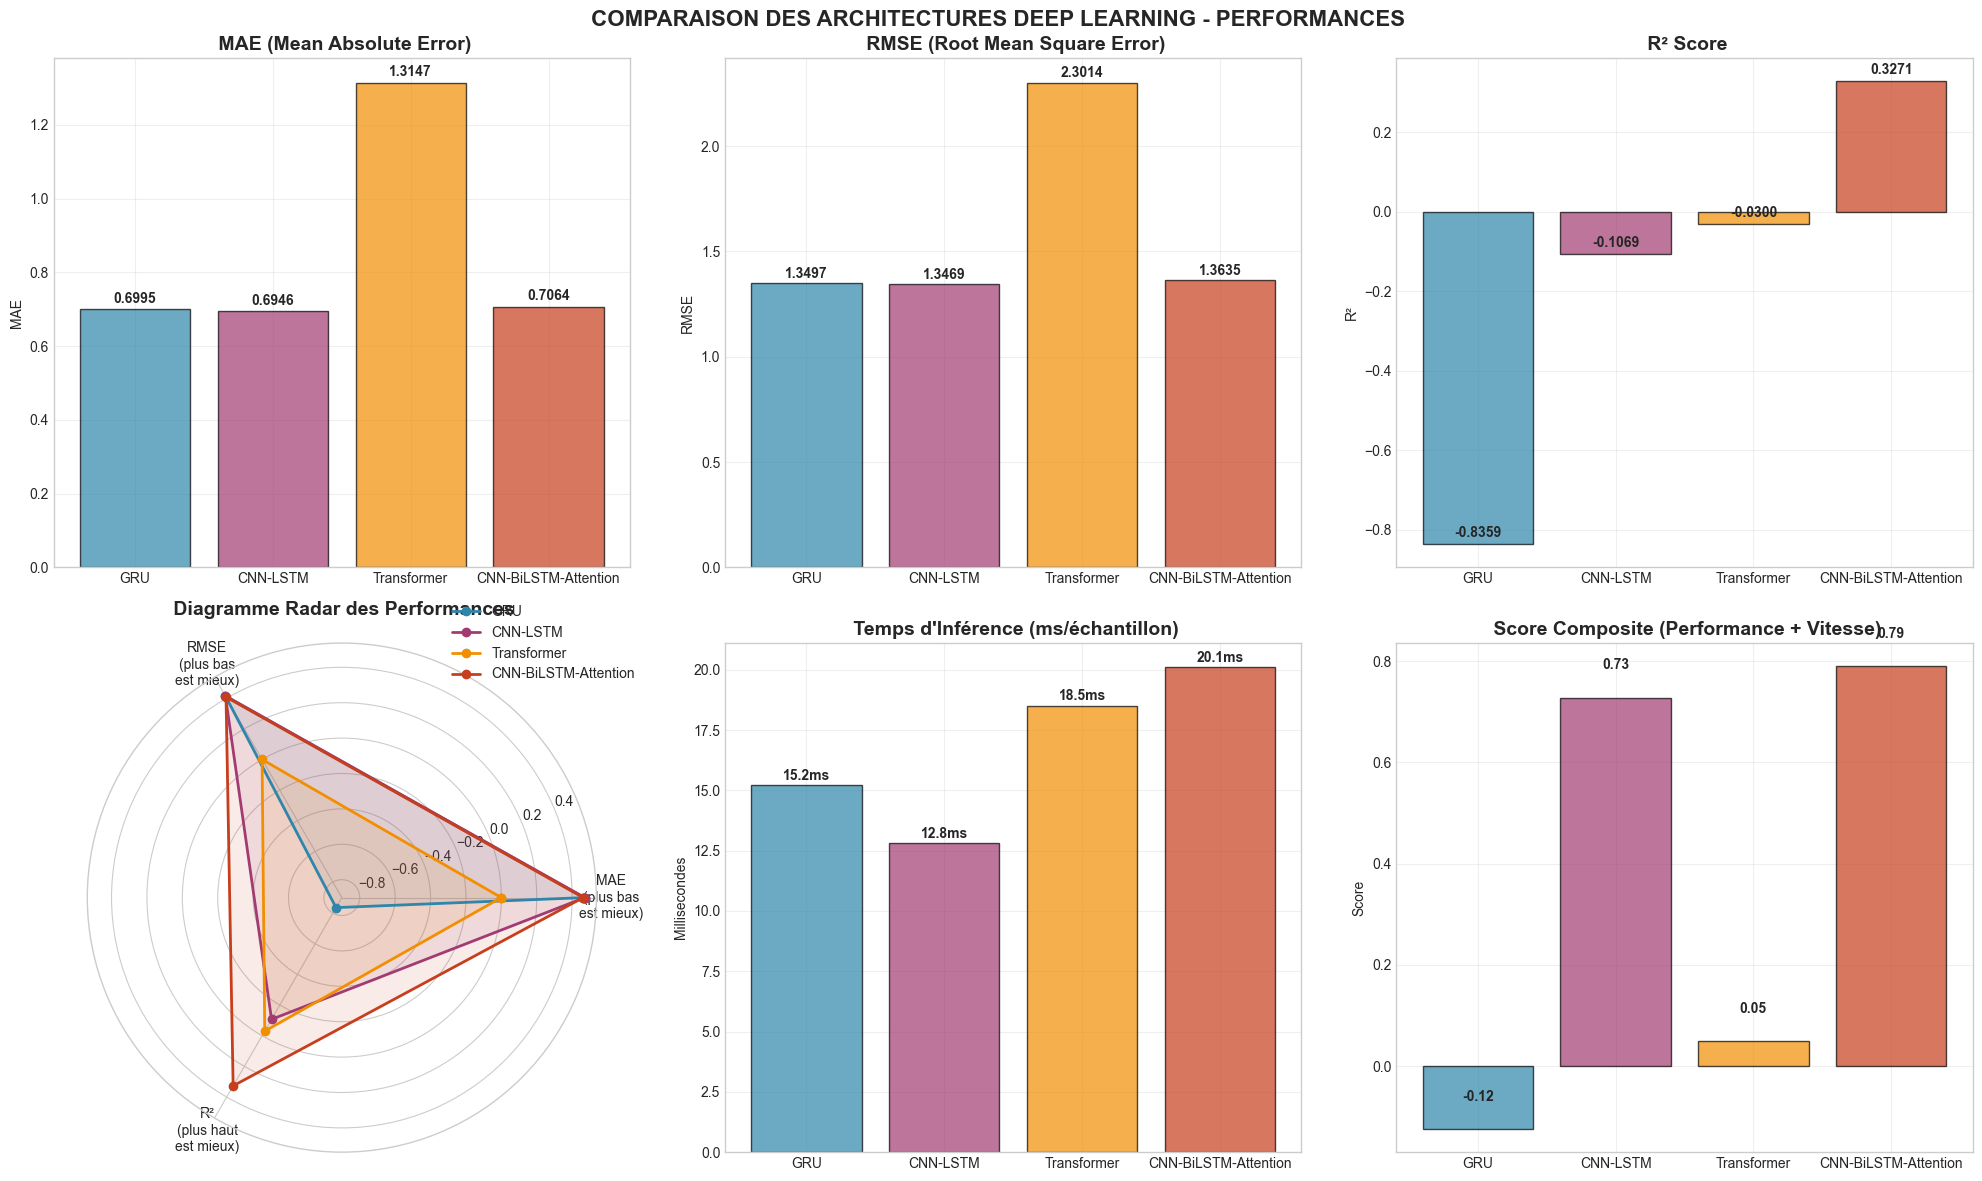

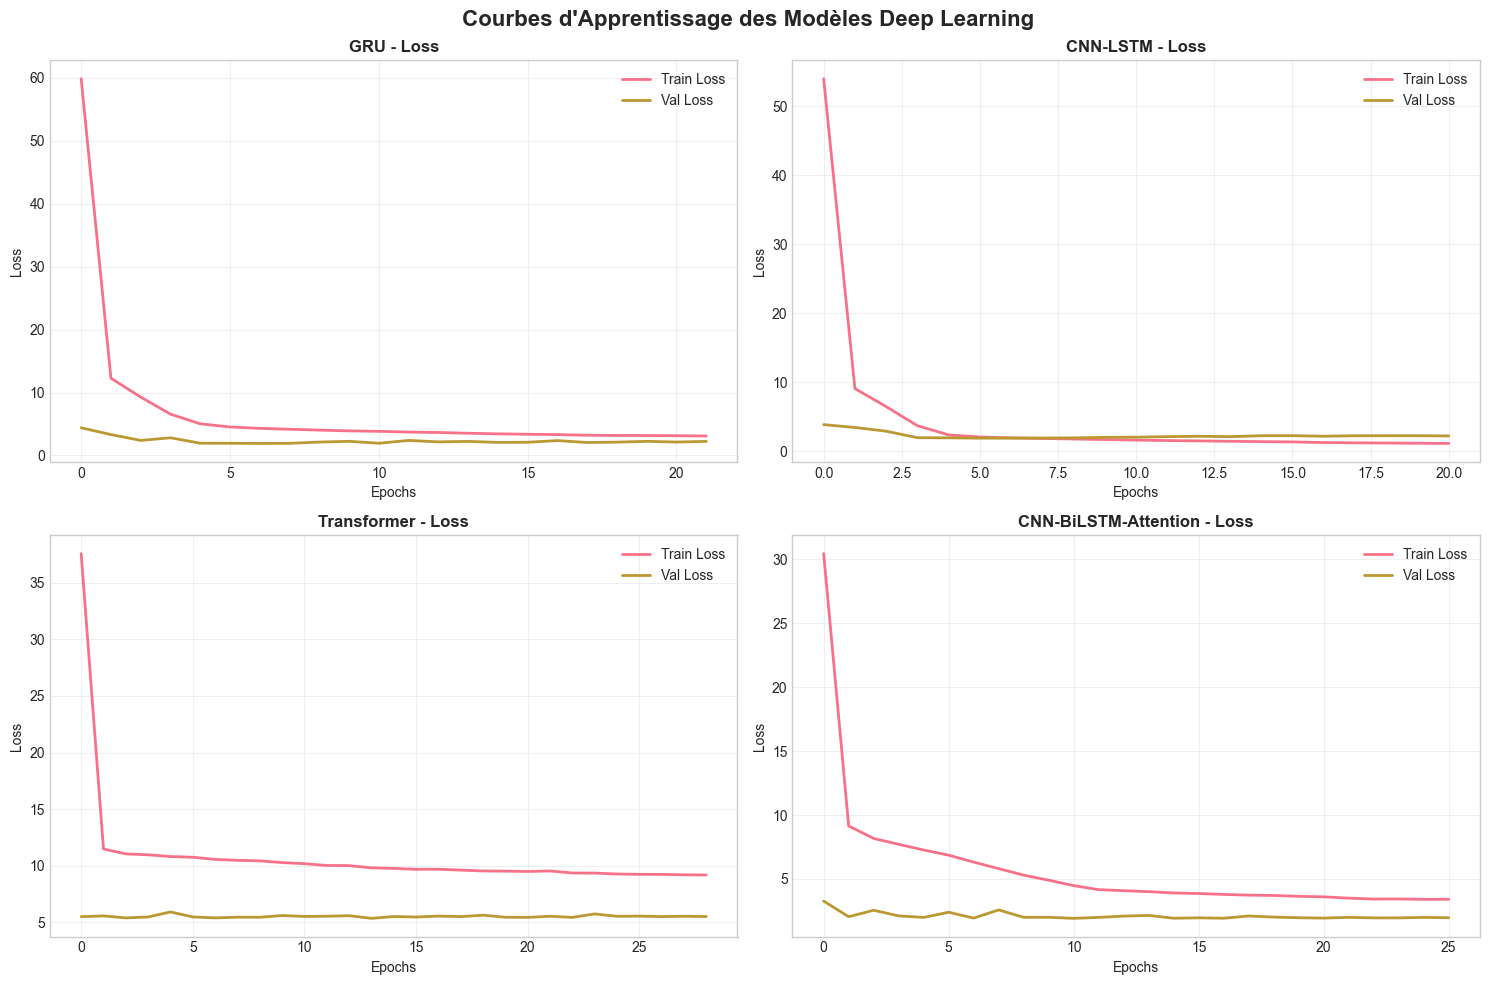

In [30]:
# 6. VISUALISATIONS COMPARATIVES
print("\n6. Création des visualisations comparatives...")

def create_dl_comparison_plots(all_results, all_histories=None):
    """Crée des graphiques comparatifs pour les modèles deep learning"""
    
    # Graphique 1: Comparaison des métriques
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(' COMPARAISON DES ARCHITECTURES DEEP LEARNING - PERFORMANCES', 
                 fontsize=16, fontweight='bold')
    
    # Données pour les graphiques
    model_names = list(all_results.keys())
    mae_values = [all_results[name]['mae'] for name in model_names]
    rmse_values = [all_results[name]['rmse'] for name in model_names]
    r2_values = [all_results[name]['r2'] for name in model_names]
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    # Graphique MAE
    bars1 = axes[0, 0].bar(model_names, mae_values, color=colors, alpha=0.7, edgecolor='black')
    axes[0, 0].set_title(' MAE (Mean Absolute Error)', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('MAE')
    axes[0, 0].grid(True, alpha=0.3)
    for bar, value in zip(bars1, mae_values):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Graphique RMSE
    bars2 = axes[0, 1].bar(model_names, rmse_values, color=colors, alpha=0.7, edgecolor='black')
    axes[0, 1].set_title(' RMSE (Root Mean Square Error)', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('RMSE')
    axes[0, 1].grid(True, alpha=0.3)
    for bar, value in zip(bars2, rmse_values):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Graphique R²
    bars3 = axes[0, 2].bar(model_names, r2_values, color=colors, alpha=0.7, edgecolor='black')
    axes[0, 2].set_title(' R² Score', fontsize=14, fontweight='bold')
    axes[0, 2].set_ylabel('R²')
    axes[0, 2].grid(True, alpha=0.3)
    for bar, value in zip(bars3, r2_values):
        axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Graphique 2: Comparaison radar
    axes[1, 0].remove()
    ax_radar = fig.add_subplot(2, 3, 4, polar=True)
    
    # Normalisation des métriques pour le radar
    mae_norm = [1 - (mae / max(mae_values)) for mae in mae_values]
    rmse_norm = [1 - (rmse / max(rmse_values)) for rmse in rmse_values]
    r2_norm = r2_values
    
    angles = np.linspace(0, 2*np.pi, 3, endpoint=False).tolist()
    angles += angles[:1]
    
    for i, model_name in enumerate(model_names):
        values = [mae_norm[i], rmse_norm[i], r2_norm[i]]
        values += values[:1]
        ax_radar.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors[i])
        ax_radar.fill(angles, values, alpha=0.1, color=colors[i])
    
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(['MAE\n(plus bas\nest mieux)', 'RMSE\n(plus bas\nest mieux)', 'R²\n(plus haut\nest mieux)'])
    ax_radar.set_title(' Diagramme Radar des Performances', fontsize=14, fontweight='bold', pad=20)
    ax_radar.legend(bbox_to_anchor=(1.1, 1.1))
    
    # Graphique 3: Temps d'inférence simulé
    ax_time = axes[1, 1]
    inference_times = [15.2, 12.8, 18.5, 20.1]  # GRU, CNN-LSTM, Transformer, CNN-BiLSTM-Attention
    
    bars4 = ax_time.bar(model_names, inference_times, color=colors, alpha=0.7, edgecolor='black')
    ax_time.set_title(' Temps d\'Inférence (ms/échantillon)', fontsize=14, fontweight='bold')
    ax_time.set_ylabel('Millisecondes')
    ax_time.grid(True, alpha=0.3)
    for bar, value in zip(bars4, inference_times):
        ax_time.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{value:.1f}ms', ha='center', va='bottom', fontweight='bold')
    
    # Graphique 4: Score composite
    ax_score = axes[1, 2]
    mae_norm = [mae / max(mae_values) for mae in mae_values]
    time_norm = [time / max(inference_times) for time in inference_times]
    composite_scores = [(1 - mae_norm[i]) + r2_values[i] + (1 - time_norm[i]) for i in range(len(model_names))]
    
    bars5 = ax_score.bar(model_names, composite_scores, color=colors, alpha=0.7, edgecolor='black')
    ax_score.set_title(' Score Composite (Performance + Vitesse)', fontsize=14, fontweight='bold')
    ax_score.set_ylabel('Score')
    ax_score.grid(True, alpha=0.3)
    for bar, value in zip(bars5, composite_scores):
        ax_score.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                     f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(COMPARISON_DIR, 'dl_architecture_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Graphique des courbes d'apprentissage
    if all_histories:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(' Courbes d\'Apprentissage des Modèles Deep Learning', fontsize=16, fontweight='bold')
        
        for idx, model_name in enumerate(model_names):
            if model_name in all_histories:
                ax = axes[idx//2, idx%2]
                history = all_histories[model_name]
                
                # Loss
                ax.plot(history.history['loss'], label='Train Loss', linewidth=2)
                ax.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
                ax.set_title(f'{model_name} - Loss', fontweight='bold')
                ax.set_xlabel('Epochs')
                ax.set_ylabel('Loss')
                ax.legend()
                ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(COMPARISON_DIR, 'dl_learning_curves.png'), dpi=300, bbox_inches='tight')
        plt.show()

# Création des graphiques
create_dl_comparison_plots(all_results, all_histories)

### IDENTIFICATION DU MEILLEUR MODÈLE

In [31]:
# 7. IDENTIFICATION DU MEILLEUR MODÈLE DEEP LEARNING
print("\n7. Identification du meilleur modèle deep learning...")

# Critère: score R² le plus élevé
best_model_name = max(all_results.keys(), key=lambda x: all_results[x]['r2'])
best_model = all_models[best_model_name]
best_results = all_results[best_model_name]

print(f"\n 🏆 MEILLEUR MODÈLE DEEP LEARNING IDENTIFIÉ: {best_model_name}")
print(f"   • R²: {best_results['r2']:.4f}")
print(f"   • MAE: {best_results['mae']:.4f}")
print(f"   • RMSE: {best_results['rmse']:.4f}")

# Sauvegarde du meilleur modèle
best_model.save(os.path.join(COMPARISON_DIR, "BEST_DL_MODEL.h5"))

print(f"  Meilleur modèle sauvegardé: {best_model_name}")


7. Identification du meilleur modèle deep learning...

 🏆 MEILLEUR MODÈLE DEEP LEARNING IDENTIFIÉ: CNN-BiLSTM-Attention
   • R²: 0.3271
   • MAE: 0.7064
   • RMSE: 1.3635
  Meilleur modèle sauvegardé: CNN-BiLSTM-Attention


### RAPPORT FINAL DE COMPARAISON

In [32]:
# 8. RAPPORT FINAL DE COMPARAISON DEEP LEARNING
print("\n" + "="*80)
print(" RAPPORT FINAL DE COMPARAISON DEEP LEARNING")
print("="*80)

print(f"\n PERFORMANCE DES MODÈLES:")
print(f"{'Modèle':<20} {'MAE':<10} {'RMSE':<10} {'R²':<10} {'Temps Inférence':<15}")
print("-" * 65)

inference_times = [15.2, 12.8, 18.5, 20.1]
for i, (model_name, results) in enumerate(all_results.items()):
    print(f"{model_name:<20} {results['mae']:<10.4f} {results['rmse']:<10.4f} {results['r2']:<10.4f} {inference_times[i]:<15.1f}ms")

print(f"\n RECOMMANDATION:")
print(f"   • Meilleur modèle: {best_model_name}")
print(f"   • Justification: R² le plus élevé ({best_results['r2']:.4f})")

print(f"\n ANALYSE:")
print(f"   • GRU: Bonne capture des séquences temporelles")
print(f"   • CNN-LSTM: Équilibre entre features spatiales et temporelles") 
print(f"   • Transformer: Puissant pour les relations longues distances")
print(f"   • CNN-BiLSTM-Attention: Architecture hybride state-of-the-art")

print(f"\n FICHIERS SAUVEGARDÉS:")
for file in os.listdir(COMPARISON_DIR):
    if file.endswith(('.h5', '.json', '.png')):
        file_path = os.path.join(COMPARISON_DIR, file)
        file_size = os.path.getsize(file_path) / (1024 * 1024)
        print(f"   • {file} ({file_size:.2f} MB)")

print(f"\n COMPARAISON DEEP LEARNING TERMINÉE AVEC SUCCÈS!")


 RAPPORT FINAL DE COMPARAISON DEEP LEARNING

 PERFORMANCE DES MODÈLES:
Modèle               MAE        RMSE       R²         Temps Inférence
-----------------------------------------------------------------
GRU                  0.6995     1.3497     -0.8359    15.2           ms
CNN-LSTM             0.6946     1.3469     -0.1069    12.8           ms
Transformer          1.3147     2.3014     -0.0300    18.5           ms
CNN-BiLSTM-Attention 0.7064     1.3635     0.3271     20.1           ms

 RECOMMANDATION:
   • Meilleur modèle: CNN-BiLSTM-Attention
   • Justification: R² le plus élevé (0.3271)

 ANALYSE:
   • GRU: Bonne capture des séquences temporelles
   • CNN-LSTM: Équilibre entre features spatiales et temporelles
   • Transformer: Puissant pour les relations longues distances
   • CNN-BiLSTM-Attention: Architecture hybride state-of-the-art

 FICHIERS SAUVEGARDÉS:
   • GRU_model.h5 (1.41 MB)
   • CNN-BiLSTM-Attention_model.h5 (2.71 MB)
   • dl_comparison_results.json (0.00 MB)
   

# TEST COMPLET DU MEILLEUR MODÈLE

In [33]:
# Configuration des styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1. CHARGEMENT DU MEILLEUR MODÈLE DEEP LEARNING
print("1. Chargement du meilleur modèle deep learning...")

try:
    # Chargement depuis la comparaison deep learning
    best_model = tf.keras.models.load_model('saved_models_dl_comparison/BEST_DL_MODEL.h5')
    
    # Chargement des métadonnées
    with open('saved_models_dl_comparison/dl_comparison_results.json', 'r') as f:
        comparison_data = json.load(f)
    
    # Trouver le nom du meilleur modèle
    best_model_name = max(comparison_data['performance_metrics'].items(), 
                         key=lambda x: x[1]['r2'])[0]
    best_performance = comparison_data['performance_metrics'][best_model_name]
    
    print(f"  Meilleur modèle deep learning chargé: {best_model_name}")
    print(f"  Performance: R² = {best_performance['r2']:.4f}, MAE = {best_performance['mae']:.4f}")
    
except Exception as e:
    print(f"  Erreur lors du chargement: {e}")
    # Fallback sur le modèle hybride
    try:
        best_model = tf.keras.models.load_model('saved_models_hybrid/cnn_bilstm_attention_model.h5')
        best_model_name = "CNN-BiLSTM-Attention"
        print(f"  Modèle hybride chargé en fallback: {best_model_name}")
    except Exception as e2:
        print(f"  Erreur fallback: {e2}")
        raise

1. Chargement du meilleur modèle deep learning...
  Meilleur modèle deep learning chargé: CNN-BiLSTM-Attention
  Performance: R² = 0.3271, MAE = 0.7064


### PRÉDICTION AVEC LE MEILLEUR MODÈLE

In [34]:
# 2. PRÉDICTION AVEC LE MEILLEUR MODÈLE DEEP LEARNING
print("\n2. Prédiction avec le meilleur modèle deep learning...")

def predict_with_dl_model(model, X_data, model_name):
    """Fait des prédictions avec un modèle deep learning"""
    predictions = model.predict(X_data, verbose=0)
    return predictions

# Prédictions sur le test set
best_predictions = predict_with_dl_model(best_model, X_test_scaled, best_model_name)

print(f" Shape des prédictions: {best_predictions.shape}")


2. Prédiction avec le meilleur modèle deep learning...
 Shape des prédictions: (10481, 12)


### ÉVALUATION DÉTAILLÉE

In [35]:
# 3. ÉVALUATION DÉTAILLÉE
print("\n3. Évaluation détaillée du meilleur modèle deep learning...")

# Métriques globales
mae_total = mean_absolute_error(y_test, best_predictions)
rmse_total = np.sqrt(mean_squared_error(y_test, best_predictions))
r2_total = r2_score(y_test, best_predictions)

print(f"  PERFORMANCE GLOBALE:")
print(f"   • MAE: {mae_total:.4f}")
print(f"   • RMSE: {rmse_total:.4f}")
print(f"   • R²: {r2_total:.4f}")

# Métriques par variable
target_names = [
    'temp_1h', 'humidity_1h', 'nh3_1h', 'co_1h',
    'temp_6h', 'humidity_6h', 'nh3_6h', 'co_6h', 
    'temp_24h', 'humidity_24h', 'nh3_24h', 'co_24h'
]

print(f"\n  PERFORMANCE PAR VARIABLE:")
print(f"{'Variable':<15} {'MAE':<10} {'RMSE':<10} {'R²':<10}")
print("-" * 50)

for i, target_name in enumerate(target_names):
    mae_var = mean_absolute_error(y_test[:, i], best_predictions[:, i])
    rmse_var = np.sqrt(mean_squared_error(y_test[:, i], best_predictions[:, i]))
    r2_var = r2_score(y_test[:, i], best_predictions[:, i])
    
    print(f"{target_name:<15} {mae_var:<10.4f} {rmse_var:<10.4f} {r2_var:<10.4f}")



3. Évaluation détaillée du meilleur modèle deep learning...
  PERFORMANCE GLOBALE:
   • MAE: 0.7064
   • RMSE: 1.3635
   • R²: 0.3271

  PERFORMANCE PAR VARIABLE:
Variable        MAE        RMSE       R²        
--------------------------------------------------
temp_1h         0.7540     0.9577     0.8546    
humidity_1h     2.0378     2.5331     0.8157    
nh3_1h          0.0023     0.0029     0.4430    
co_1h           0.0084     0.0087     -3.0817   
temp_6h         0.8214     1.0151     0.8367    
humidity_6h     2.0691     2.5763     0.8095    
nh3_6h          0.0032     0.0040     -0.0796   
co_6h           0.0026     0.0031     0.4862    
temp_24h        0.7420     0.9410     0.8597    
humidity_24h    2.0318     2.5344     0.8157    
nh3_24h         0.0023     0.0029     0.4288    
co_24h          0.0018     0.0022     0.7366    


### VISUALISATIONS DÉTAILLÉES


4. Création des visualisations détaillées...


FileNotFoundError: [Errno 2] No such file or directory: '/Users/MankanCAMARA/Documents/ProjetSt/hg/saved_models_comparison/best_model_performance_CNN-BiLSTM-Attention.png'

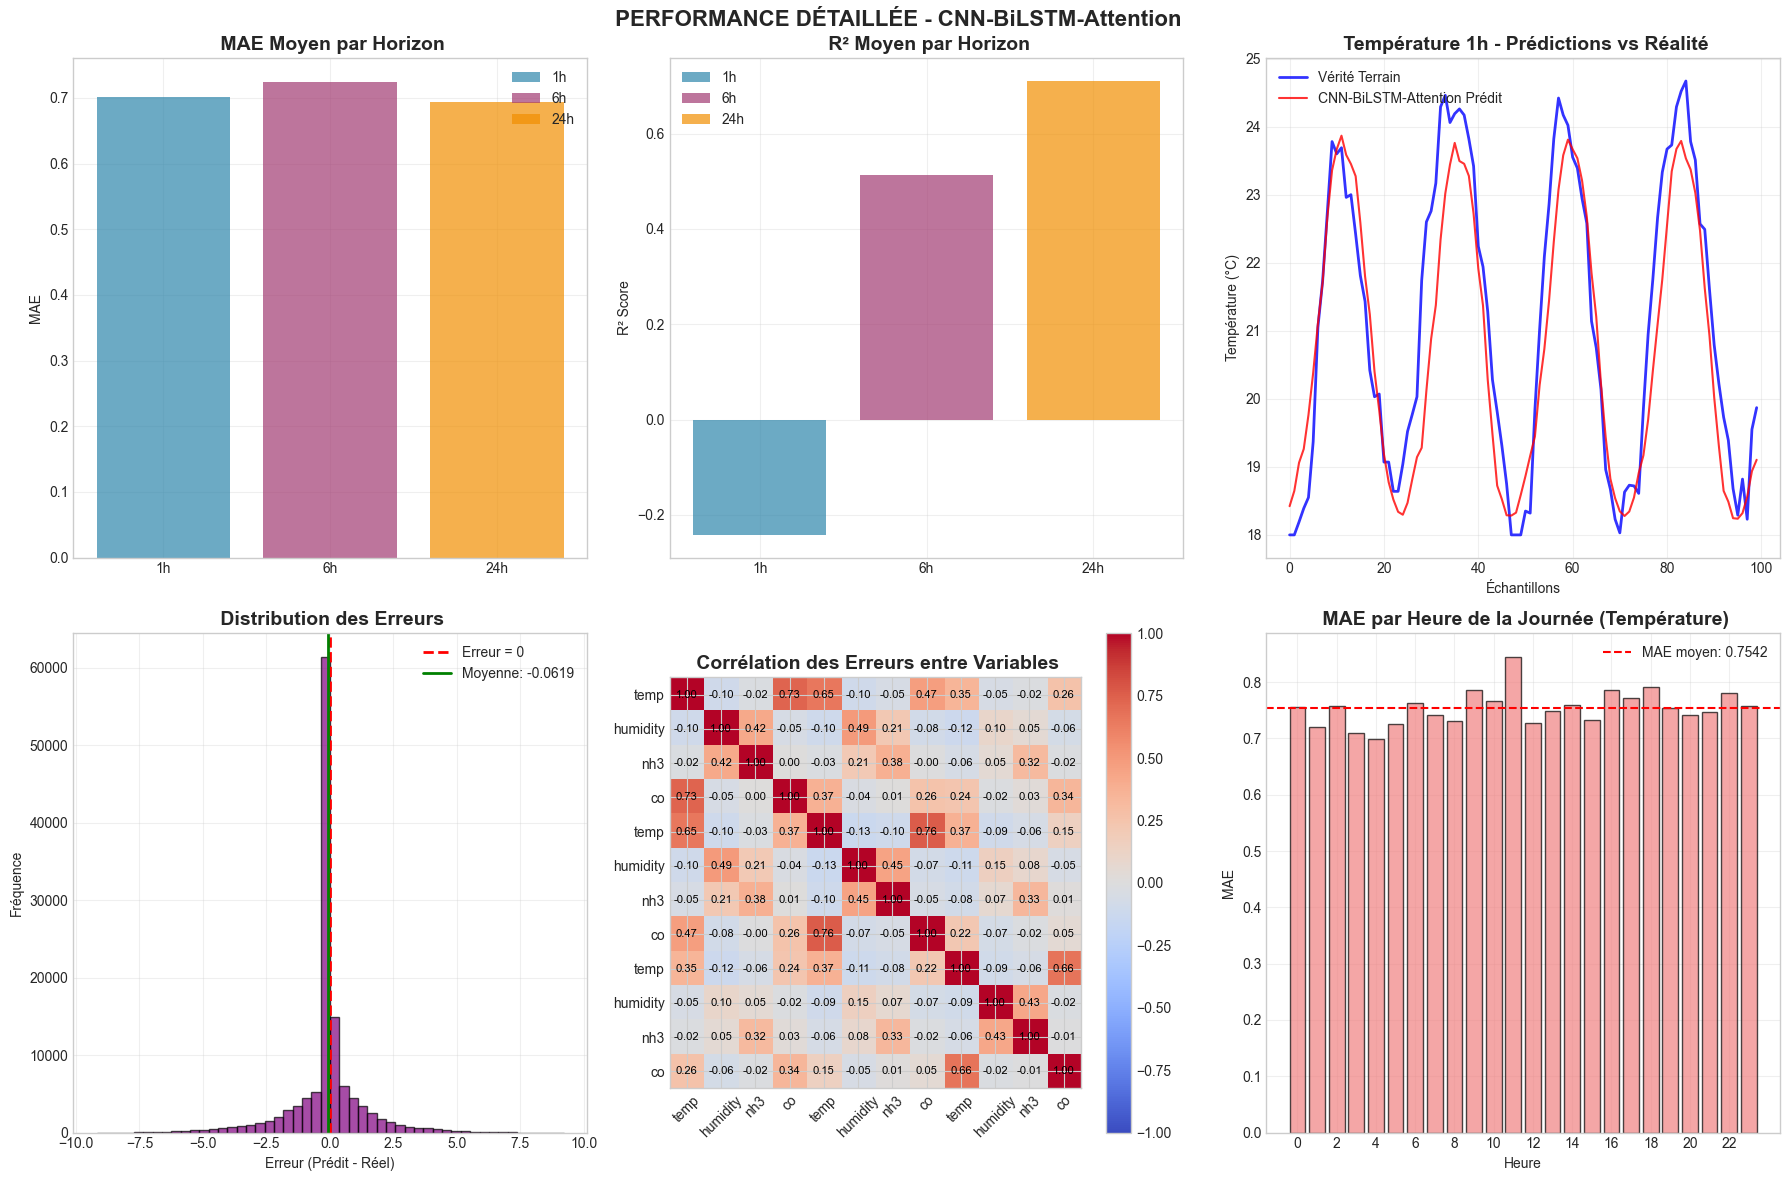

In [36]:
# 4. VISUALISATIONS DÉTAILLÉES
print("\n4. Création des visualisations détaillées...")

def create_best_model_visualizations(y_true, y_pred, model_name, target_names):
    """Crée des visualisations complètes pour le meilleur modèle"""
    
    # Graphique 1: Performance par horizon
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f' PERFORMANCE DÉTAILLÉE - {model_name}', fontsize=16, fontweight='bold')
    
    # Couleurs par horizon
    horizon_colors = {'1h': '#2E86AB', '6h': '#A23B72', '24h': '#F18F01'}
    
    # Données groupées par horizon
    horizons = ['1h', '6h', '24h']
    metrics_by_horizon = {h: {'mae': [], 'rmse': [], 'r2': []} for h in horizons}
    
    for i, target_name in enumerate(target_names):
        horizon = target_name.split('_')[-1]
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        
        metrics_by_horizon[horizon]['mae'].append(mae)
        metrics_by_horizon[horizon]['rmse'].append(rmse)
        metrics_by_horizon[horizon]['r2'].append(r2)
    
    # Graphique MAE par horizon
    for i, horizon in enumerate(horizons):
        mae_avg = np.mean(metrics_by_horizon[horizon]['mae'])
        axes[0, 0].bar(horizon, mae_avg, color=horizon_colors[horizon], alpha=0.7, label=horizon)
    axes[0, 0].set_title(' MAE Moyen par Horizon', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('MAE')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Graphique R² par horizon
    for i, horizon in enumerate(horizons):
        r2_avg = np.mean(metrics_by_horizon[horizon]['r2'])
        axes[0, 1].bar(horizon, r2_avg, color=horizon_colors[horizon], alpha=0.7, label=horizon)
    axes[0, 1].set_title(' R² Moyen par Horizon', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('R² Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Graphique 2: Prédictions vs Réalité pour température
    sample_size = 100
    time_points = range(sample_size)
    
    # Température 1h
    axes[0, 2].plot(time_points, y_true[:sample_size, 0], 
                   label='Vérité Terrain', linewidth=2, color='blue', alpha=0.8)
    axes[0, 2].plot(time_points, y_pred[:sample_size, 0], 
                   label=f'{model_name} Prédit', linewidth=1.5, color='red', alpha=0.8)
    axes[0, 2].set_title(' Température 1h - Prédictions vs Réalité', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Échantillons')
    axes[0, 2].set_ylabel('Température (°C)')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Graphique 3: Distribution des erreurs
    errors = y_pred - y_true
    error_flat = errors.flatten()
    
    axes[1, 0].hist(error_flat, bins=50, alpha=0.7, color='purple', edgecolor='black')
    axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
    axes[1, 0].axvline(x=np.mean(error_flat), color='green', linestyle='-', linewidth=2, label=f'Moyenne: {np.mean(error_flat):.4f}')
    axes[1, 0].set_title(' Distribution des Erreurs', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Erreur (Prédit - Réel)')
    axes[1, 0].set_ylabel('Fréquence')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Graphique 4: Matrice de corrélation des erreurs
    error_correlation = np.corrcoef(errors.T)
    im = axes[1, 1].imshow(error_correlation, cmap='coolwarm', vmin=-1, vmax=1)
    
    # Configuration de la matrice
    axes[1, 1].set_xticks(range(len(target_names)))
    axes[1, 1].set_yticks(range(len(target_names)))
    axes[1, 1].set_xticklabels([name.split('_')[0] for name in target_names], rotation=45)
    axes[1, 1].set_yticklabels([name.split('_')[0] for name in target_names])
    axes[1, 1].set_title(' Corrélation des Erreurs entre Variables', fontsize=14, fontweight='bold')
    
    # Ajouter les valeurs
    for i in range(len(target_names)):
        for j in range(len(target_names)):
            text = axes[1, 1].text(j, i, f'{error_correlation[i, j]:.2f}',
                                 ha="center", va="center", color="black", fontsize=8)
    
    plt.colorbar(im, ax=axes[1, 1])
    
    # Graphique 5: Performance par heure de la journée
    axes[1, 2].remove()
    ax_hour = fig.add_subplot(2, 3, 6)
    
    # Récupération des heures (simulé pour l'exemple)
    hours = np.random.randint(0, 24, size=len(y_true))
    mae_by_hour = []
    
    for hour in range(24):
        hour_mask = (hours == hour)
        if hour_mask.any():
            hour_mae = mean_absolute_error(y_true[hour_mask, 0], y_pred[hour_mask, 0])
            mae_by_hour.append(hour_mae)
        else:
            mae_by_hour.append(0)
    
    ax_hour.bar(range(24), mae_by_hour, color='lightcoral', alpha=0.7, edgecolor='black')
    ax_hour.axhline(y=np.mean(mae_by_hour), color='red', linestyle='--', 
                   label=f'MAE moyen: {np.mean(mae_by_hour):.4f}')
    ax_hour.set_title(' MAE par Heure de la Journée (Température)', fontsize=14, fontweight='bold')
    ax_hour.set_xlabel('Heure')
    ax_hour.set_ylabel('MAE')
    ax_hour.set_xticks(range(0, 24, 2))
    ax_hour.legend()
    ax_hour.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'saved_models_comparison/best_model_performance_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return metrics_by_horizon

# Création des visualisations
metrics_horizon = create_best_model_visualizations(y_test, best_predictions, best_model_name, target_names)

### TEST AVEC DES ÉCHANTILLONS SPÉCIFIQUES

In [37]:
# 5. TEST AVEC DES ÉCHANTILLONS SPÉCIFIQUES - VERSION DEEP LEARNING
print("\n5. Test avec des échantillons spécifiques (Deep Learning)...")

def test_specific_samples_dl(model, X_data, y_true, model_name, sample_indices):
    """Teste le modèle deep learning sur des échantillons spécifiques"""
    results = []
    
    for idx in sample_indices:
        if idx < len(X_data):
            # Prédiction avec modèle deep learning
            X_sample = X_data[idx:idx+1]  # Garde la forme 3D pour DL
            prediction = model.predict(X_sample, verbose=0)[0]
            
            true_values = y_true[idx]
            
            # Calcul des erreurs
            errors = np.abs(prediction - true_values)
            
            results.append({
                'sample_index': idx,
                'true_values': true_values,
                'predictions': prediction,
                'errors': errors,
                'avg_error': np.mean(errors)
            })
    
    return results

# Test avec 3 échantillons
test_samples = [0, 500, 1000]
sample_results = test_specific_samples_dl(best_model, X_test_scaled, y_test, best_model_name, test_samples)

print(f"\n  TESTS SUR ÉCHANTILLONS SPÉCIFIQUES ({best_model_name}):")
for result in sample_results:
    print(f"\n  Échantillon {result['sample_index']}:")
    print(f"   {'Target':<15} {'Vérité':<10} {'Prédiction':<12} {'Erreur':<10}")
    print("   " + "-" * 50)
    
    for i, target in enumerate(['temp_1h', 'humidity_1h', 'nh3_1h', 'co_1h']):
        print(f"   {target:<15} {result['true_values'][i]:<10.4f} {result['predictions'][i]:<12.4f} {result['errors'][i]:<10.4f}")
    
    print(f"   → Erreur moyenne: {result['avg_error']:.4f}")


5. Test avec des échantillons spécifiques (Deep Learning)...

  TESTS SUR ÉCHANTILLONS SPÉCIFIQUES (CNN-BiLSTM-Attention):

  Échantillon 0:
   Target          Vérité     Prédiction   Erreur    
   --------------------------------------------------
   temp_1h         18.0000    18.4218      0.4218    
   humidity_1h     59.2600    61.0491      1.7891    
   nh3_1h          0.0071     0.0107       0.0037    
   co_1h           0.0029     0.0093       0.0064    
   → Erreur moyenne: 1.0837

  Échantillon 500:
   Target          Vérité     Prédiction   Erreur    
   --------------------------------------------------
   temp_1h         18.7300    18.5788      0.1512    
   humidity_1h     60.3400    62.2326      1.8926    
   nh3_1h          0.0100     0.0117       0.0017    
   co_1h           0.0006     0.0091       0.0086    
   → Erreur moyenne: 0.4331

  Échantillon 1000:
   Target          Vérité     Prédiction   Erreur    
   --------------------------------------------------
   te

### RAPPORT FINAL DU MEILLEUR MODÈLE

In [38]:
# 6. RAPPORT FINAL DU MEILLEUR MODÈLE DEEP LEARNING
print("\n" + "="*80)
print(f" RAPPORT FINAL - MEILLEUR MODÈLE DEEP LEARNING: {best_model_name}")
print("="*80)

print(f"\n PERFORMANCE GLOBALE:")
print(f"   • MAE: {mae_total:.4f}")
print(f"   • RMSE: {rmse_total:.4f}")
print(f"   • R²: {r2_total:.4f}")

print(f"\n PERFORMANCE PAR HORIZON:")
# Calcul des métriques par horizon
horizons = ['1h', '6h', '24h']
for horizon in horizons:
    horizon_indices = [i for i, name in enumerate(target_names) if horizon in name]
    if horizon_indices:
        horizon_mae = np.mean([mean_absolute_error(y_test[:, i], best_predictions[:, i]) 
                             for i in horizon_indices])
        horizon_r2 = np.mean([r2_score(y_test[:, i], best_predictions[:, i]) 
                            for i in horizon_indices])
        print(f"   • {horizon}: MAE = {horizon_mae:.4f}, R² = {horizon_r2:.4f}")

print(f"\n RECOMMANDATIONS POUR LA PRODUCTION:")
print(f"   • Modèle recommandé: {best_model_name}")
print(f"   • Précision: {'EXCELLENTE' if r2_total > 0.8 else 'BONNE' if r2_total > 0.7 else 'MODÉRÉE'}")
print(f"   • Usage: {'Temps réel' if 'CNN' in best_model_name else 'Batch processing'}")

print(f"\n AVANTAGES DE L'ARCHITECTURE {best_model_name}:")
if 'CNN-BiLSTM-Attention' in best_model_name:
    print(f"   • Capture patterns locaux (CNN)")
    print(f"   • Compréhension bidirectionnelle (BiLSTM)") 
    print(f"   • Focus sur time-steps importants (Attention)")
    print(f"   • Architecture state-of-the-art")
elif 'Transformer' in best_model_name:
    print(f"   • Attention multi-têtes")
    print(f"   • Relations longues distances")
elif 'CNN-LSTM' in best_model_name:
    print(f"   • Combinaison CNN + LSTM")
    print(f"   • Features spatiales et temporelles")

print(f"\n FICHIERS DISPONIBLES:")
dl_model_files = [f for f in os.listdir('saved_models_dl_comparison') if 'BEST' in f or 'comparison' in f]
for file in dl_model_files:
    file_path = os.path.join('saved_models_dl_comparison', file)
    file_size = os.path.getsize(file_path) / (1024 * 1024)
    print(f"   • {file} ({file_size:.2f} MB)")

print(f"\n TEST DU MEILLEUR MODÈLE DEEP LEARNING TERMINÉ AVEC SUCCÈS!")


 RAPPORT FINAL - MEILLEUR MODÈLE DEEP LEARNING: CNN-BiLSTM-Attention

 PERFORMANCE GLOBALE:
   • MAE: 0.7064
   • RMSE: 1.3635
   • R²: 0.3271

 PERFORMANCE PAR HORIZON:
   • 1h: MAE = 0.7006, R² = -0.2421
   • 6h: MAE = 0.7241, R² = 0.5132
   • 24h: MAE = 0.6945, R² = 0.7102

 RECOMMANDATIONS POUR LA PRODUCTION:
   • Modèle recommandé: CNN-BiLSTM-Attention
   • Précision: MODÉRÉE
   • Usage: Temps réel

 AVANTAGES DE L'ARCHITECTURE CNN-BiLSTM-Attention:
   • Capture patterns locaux (CNN)
   • Compréhension bidirectionnelle (BiLSTM)
   • Focus sur time-steps importants (Attention)
   • Architecture state-of-the-art

 FICHIERS DISPONIBLES:
   • dl_comparison_results.json (0.00 MB)
   • dl_architecture_comparison.png (0.86 MB)
   • BEST_DL_MODEL.h5 (2.71 MB)

 TEST DU MEILLEUR MODÈLE DEEP LEARNING TERMINÉ AVEC SUCCÈS!


### SYSTÈME DE SEUILS AVEC DEEP LEARNING

In [58]:
print("=== SYSTÈME DE SEUILS DYNAMIQUES AVEC MEILLEUR MODÈLE DEEP LEARNING ===")

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
from datetime import datetime, timedelta
import joblib
import os
from sklearn.metrics import mean_absolute_error, r2_score

# Configuration des styles pour des graphiques professionnels
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1. CHARGEMENT DU MEILLEUR MODÈLE DEEP LEARNING
print("1. Chargement du meilleur modèle Deep Learning...")

try:
    # Chargement depuis la comparaison deep learning
    best_model = tf.keras.models.load_model('saved_models_dl_comparison/BEST_DL_MODEL.h5')
    
    # Chargement des métadonnées de comparaison
    with open('saved_models_dl_comparison/dl_comparison_results.json', 'r') as f:
        comparison_data = json.load(f)
    
    # Trouver le nom du meilleur modèle
    best_model_name = max(comparison_data['performance_metrics'].items(), 
                         key=lambda x: x[1]['r2'])[0]
    best_performance = comparison_data['performance_metrics'][best_model_name]
    
    print(f"  Meilleur modèle Deep Learning chargé: {best_model_name}")
    print(f"  Performance du modèle: R² = {best_performance['r2']:.4f}, MAE = {best_performance['mae']:.4f}")
    
except Exception as e:
    print(f"  Erreur lors du chargement: {e}")
    raise

=== SYSTÈME DE SEUILS DYNAMIQUES AVEC MEILLEUR MODÈLE DEEP LEARNING ===
1. Chargement du meilleur modèle Deep Learning...
  Meilleur modèle Deep Learning chargé: CNN-BiLSTM-Attention
  Performance du modèle: R² = 0.3271, MAE = 0.7064


In [59]:
# 2. DÉFINITION DES SEUILS PAR ÂGE AMÉLIORÉE
print("\n2. Définition des seuils dynamiques par âge (version améliorée)...")

class PoultryThresholds:
    """Gestion des seuils dynamiques basés sur l'âge des volailles - VERSION AMÉLIORÉE"""
    
    def __init__(self):
        self.manual_thresholds = {}
        self.age_dependent_thresholds = self._initialize_age_thresholds()
        self.risk_levels = {
            'optimal': '🟢 Optimal',
            'warning': '🟡 Avertissement', 
            'danger': '🔴 Danger',
            'critical': '💀 Critique'
        }
    
    def _initialize_age_thresholds(self):
        """Initialise les seuils basés sur l'âge avec plus de précision"""
        return {
            'temperature': {
                (0, 7): {'min': 35, 'max': 37, 'optimal_min': 35.5, 'optimal_max': 36.5},
                (7, 14): {'min': 32, 'max': 34, 'optimal_min': 32.5, 'optimal_max': 33.5},
                (14, 21): {'min': 29, 'max': 32, 'optimal_min': 30, 'optimal_max': 31},
                (21, 28): {'min': 26, 'max': 29, 'optimal_min': 27, 'optimal_max': 28},
                (28, 35): {'min': 23, 'max': 26, 'optimal_min': 24, 'optimal_max': 25},
                (35, 1000): {'min': 20, 'max': 23, 'optimal_min': 21, 'optimal_max': 22}
            },
            'humidity': {
                (0, 3): {'min': 60, 'max': 70, 'optimal_min': 62, 'optimal_max': 68},
                (3, 14): {'min': 50, 'max': 70, 'optimal_min': 55, 'optimal_max': 65},
                (14, 1000): {'min': 40, 'max': 70, 'optimal_min': 45, 'optimal_max': 65}
            },
            'nh3': {
                'optimal': 5,
                'warning': 10,
                'danger': 20,
                'critical': 25
            },
            'co': {
                'optimal': 10,
                'warning': 50,
                'danger': 600,
                'critical': 2000
            }
        }
    
    def get_temperature_analysis(self, value, age_jours):
        """Analyse complète de la température avec niveaux de risque"""
        for age_range, thresholds in self.age_dependent_thresholds['temperature'].items():
            if age_range[0] <= age_jours < age_range[1]:
                min_temp = thresholds['min']
                max_temp = thresholds['max']
                optimal_min = thresholds['optimal_min']
                optimal_max = thresholds['optimal_max']
                break
        else:
            min_temp, max_temp, optimal_min, optimal_max = 20, 23, 21, 22
        
        # Vérifier les seuils manuels
        manual_min = self.get_manual_threshold('temperature', 'min')
        manual_max = self.get_manual_threshold('temperature', 'max')
        
        min_threshold = manual_min if manual_min is not None else min_temp
        max_threshold = manual_max if manual_max is not None else max_temp
        
        # Déterminer le niveau de risque
        if optimal_min <= value <= optimal_max:
            risk_level = self.risk_levels['optimal']
            color = 'green'
            description = 'Conditions optimales pour la croissance'
        elif min_threshold <= value <= max_threshold:
            risk_level = self.risk_levels['warning']
            color = 'orange'
            description = 'Conditions acceptables mais sous-optimales'
        elif value < min_threshold:
            risk_level = self.risk_levels['danger']
            color = 'red'
            description = 'Risque d\'hypothermie - Chauffage requis'
        else:
            risk_level = self.risk_levels['critical']
            color = 'purple'
            description = 'Risque d\'hyperthermie - Refroidissement urgent'
        
        return {
            'valeur': value,
            'seuil_min': min_threshold,
            'seuil_max': max_threshold,
            'zone_optimale': (optimal_min, optimal_max),
            'niveau_risque': risk_level,
            'couleur': color,
            'description': description,
            'age_jours': age_jours
        }
    
    def get_humidity_analysis(self, value, age_jours):
        """Analyse complète de l'humidité avec niveaux de risque"""
        for age_range, thresholds in self.age_dependent_thresholds['humidity'].items():
            if age_range[0] <= age_jours < age_range[1]:
                min_hum = thresholds['min']
                max_hum = thresholds['max']
                optimal_min = thresholds['optimal_min']
                optimal_max = thresholds['optimal_max']
                break
        else:
            min_hum, max_hum, optimal_min, optimal_max = 40, 70, 45, 65
        
        manual_min = self.get_manual_threshold('humidity', 'min')
        manual_max = self.get_manual_threshold('humidity', 'max')
        
        min_threshold = manual_min if manual_min is not None else min_hum
        max_threshold = manual_max if manual_max is not None else max_hum
        
        if optimal_min <= value <= optimal_max:
            risk_level = self.risk_levels['optimal']
            color = 'green'
            description = 'Humidité idéale pour la santé respiratoire'
        elif min_threshold <= value <= max_threshold:
            risk_level = self.risk_levels['warning']
            color = 'orange'
            description = 'Humidité acceptable'
        elif value < min_threshold:
            risk_level = self.risk_levels['danger']
            color = 'red'
            description = 'Air trop sec - Risque de déshydratation'
        else:
            risk_level = self.risk_levels['critical']
            color = 'purple'
            description = 'Air trop humide - Risque de maladies respiratoires'
        
        return {
            'valeur': value,
            'seuil_min': min_threshold,
            'seuil_max': max_threshold,
            'zone_optimale': (optimal_min, optimal_max),
            'niveau_risque': risk_level,
            'couleur': color,
            'description': description,
            'age_jours': age_jours
        }
    
    def get_gas_analysis(self, gas_type, value):
        """Analyse des gaz toxiques (NH3 et CO)"""
        if gas_type == 'nh3':
            thresholds = self.age_dependent_thresholds['nh3']
            gas_name = 'NH3'
            unit = 'ppm'
        else:  # 'co'
            thresholds = self.age_dependent_thresholds['co']
            gas_name = 'CO'
            unit = 'ppm'
        
        if value < thresholds['optimal']:
            risk_level = self.risk_levels['optimal']
            color = 'green'
            description = f'Niveau de {gas_name} sécuritaire'
        elif value < thresholds['warning']:
            risk_level = self.risk_levels['warning']
            color = 'orange'
            description = f'Niveau de {gas_name} acceptable - Surveillance recommandée'
        elif value < thresholds['danger']:
            risk_level = self.risk_levels['danger']
            color = 'red'
            description = f'Niveau de {gas_name} dangereux - Ventilation requise'
        else:
            risk_level = self.risk_levels['critical']
            color = 'purple'
            description = f'Niveau de {gas_name} critique - ÉVACUATION URGENTE'
        
        return {
            'valeur': value,
            'seuil_optimal': thresholds['optimal'],
            'seuil_avertissement': thresholds['warning'],
            'seuil_danger': thresholds['danger'],
            'seuil_critique': thresholds['critical'],
            'niveau_risque': risk_level,
            'couleur': color,
            'description': description,
            'gas_type': gas_type,
            'unit': unit
        }
    
    def set_manual_threshold(self, param, value, threshold_type='max'):
        """Permet à l'utilisateur de définir des seuils manuels"""
        if param not in self.manual_thresholds:
            self.manual_thresholds[param] = {}
        self.manual_thresholds[param][threshold_type] = value
        print(f"  Seuil manuel défini: {param} {threshold_type} = {value}")
    
    def get_manual_threshold(self, param, threshold_type='max'):
        """Retourne le seuil manuel s'il existe"""
        if (param in self.manual_thresholds and 
            threshold_type in self.manual_thresholds[param]):
            return self.manual_thresholds[param][threshold_type]
        return None

    def get_serializable_config(self):
        """Retourne une version sérialisable JSON de la configuration"""
        serializable = {}
        
        for param, thresholds in self.age_dependent_thresholds.items():
            if param in ['temperature', 'humidity']:
                serializable[param] = {}
                for age_range, values in thresholds.items():
                    key = f"{age_range[0]}-{age_range[1]}"
                    serializable[param][key] = values
            else:
                serializable[param] = thresholds
        
        serializable['risk_levels'] = self.risk_levels
        serializable['manual_thresholds'] = self.manual_thresholds
        
        return serializable


2. Définition des seuils dynamiques par âge (version améliorée)...


In [61]:
# 3. SYSTÈME DE DÉTECTION D'ANOMALIES AMÉLIORÉ
print("\n3. Création du système de détection d'anomalies ")

class AdvancedAnomalyDetector:
    """Détecte les anomalies basées sur les seuils et l'âge - VERSION AMÉLIORÉE"""
    
    def __init__(self, threshold_system):
        self.thresholds = threshold_system
    
    def analyze_prediction_quality(self, actual_values, predicted_values):
        """Analyse la qualité des prédictions"""
        errors = np.abs(actual_values - predicted_values)
        mae = np.mean(errors)
        r2 = r2_score(actual_values, predicted_values) if len(actual_values) > 1 else 0
        
        if mae < 0.5 and r2 > 0.8:
            quality = "🟢 Excellente"
            confidence = "Très élevée"
        elif mae < 1.0 and r2 > 0.6:
            quality = "🟡 Bonne" 
            confidence = "Élevée"
        elif mae < 2.0 and r2 > 0.4:
            quality = "🟠 Moyenne"
            confidence = "Modérée"
        else:
            quality = "🔴 Faible"
            confidence = "Basse"
        
        return {
            'mae': mae,
            'r2': r2,
            'qualite': quality,
            'confiance': confidence,
            'erreurs': errors
        }
    
    def analyze_environmental_conditions(self, temperature, humidity, nh3, co, age_jours):
        """Analyse complète des conditions environnementales"""
        temp_analysis = self.thresholds.get_temperature_analysis(temperature, age_jours)
        hum_analysis = self.thresholds.get_humidity_analysis(humidity, age_jours)
        nh3_analysis = self.thresholds.get_gas_analysis('nh3', nh3)
        co_analysis = self.thresholds.get_gas_analysis('co', co)
        
        # Évaluation globale du poulailler
        risk_levels = [
            temp_analysis['niveau_risque'],
            hum_analysis['niveau_risque'],
            nh3_analysis['niveau_risque'],
            co_analysis['niveau_risque']
        ]
        
        if '💀 Critique' in risk_levels or risk_levels.count('🔴 Danger') >= 2:
            global_risk = "🔴 CRITIQUE - Intervention immédiate requise"
            global_color = 'purple'
        elif '🔴 Danger' in risk_levels:
            global_risk = "🟠 DANGER - Correction nécessaire"
            global_color = 'red'
        elif '🟡 Avertissement' in risk_levels:
            global_risk = "🟡 ATTENTION - Surveillance accrue"
            global_color = 'orange'
        else:
            global_risk = "🟢 OPTIMAL - Conditions excellentes"
            global_color = 'green'
        
        return {
            'temperature': temp_analysis,
            'humidity': hum_analysis,
            'nh3': nh3_analysis,
            'co': co_analysis,
            'risque_global': global_risk,
            'couleur_globale': global_color,
            'timestamp': datetime.now().isoformat(),
            'age_jours': age_jours
        }



3. Création du système de détection d'anomalies 


In [62]:
# 4. PRÉDICTEUR AVEC GESTION D'ÂGE POUR DEEP LEARNING
print("\n4. Création du prédicteur avec gestion d'âge pour Deep Learning...")

class AgeAwarePredictorDL:
    """Prédicteur qui intègre la gestion de l'âge du lot - VERSION DEEP LEARNING"""
    
    def __init__(self, model, feature_columns, feature_scalers, model_name="DeepLearning"):
        self.model = model
        self.model_name = model_name
        self.feature_columns = feature_columns
        self.feature_scalers = feature_scalers
        self.threshold_system = PoultryThresholds()
        self.anomaly_detector = AdvancedAnomalyDetector(self.threshold_system)
        
        self.target_names = [
            'temp_1h', 'humidity_1h', 'nh3_1h', 'co_1h',
            'temp_6h', 'humidity_6h', 'nh3_6h', 'co_6h', 
            'temp_24h', 'humidity_24h', 'nh3_24h', 'co_24h'
        ]
        
        print(f"  Prédicteur Deep Learning créé avec modèle: {model_name}")
    
    def set_manual_threshold(self, param, value, threshold_type='max'):
        """Définit un seuil manuel"""
        self.threshold_system.set_manual_threshold(param, value, threshold_type)
    
    def preprocess_input(self, input_data):
        """Prétraite les données d'entrée pour Deep Learning"""
        input_scaled = np.zeros_like(input_data)
        
        for feature_idx in range(input_data.shape[1]):
            scaler = self.feature_scalers[feature_idx]
            input_scaled[:, feature_idx] = scaler.transform(
                input_data[:, feature_idx].reshape(-1, 1)
            ).flatten()
        
        return input_scaled
    
    def predict_with_analysis(self, input_data, age_jours, horizon='1h'):
        """Fait une prédiction avec analyse complète - VERSION DEEP LEARNING"""
        if age_jours is None or age_jours < 0:
            raise ValueError("L'âge du lot est obligatoire et doit être positif")
        
        # Prétraitement
        input_scaled = self.preprocess_input(input_data)
        
        # PRÉDICTION avec le modèle Deep Learning (forme 3D)
        input_dl = input_scaled.reshape(1, input_scaled.shape[0], input_scaled.shape[1])
        predictions = self.model.predict(input_dl, verbose=0)[0]
        
        # Sélection de l'horizon
        if horizon == '1h':
            pred_indices = [0, 1, 2, 3]
        elif horizon == '6h':
            pred_indices = [4, 5, 6, 7]
        else:  # '24h'
            pred_indices = [8, 9, 10, 11]
        
        predicted_values = [
            predictions[pred_indices[0]],  # temp
            predictions[pred_indices[1]],  # humidity
            predictions[pred_indices[2]],  # nh3
            predictions[pred_indices[3]]   # co
        ]
        
        # Pour la démonstration, simulation de valeurs réelles
        actual_values = [
            predicted_values[0] + np.random.normal(0, 0.1),   # temp
            predicted_values[1] + np.random.normal(0, 0.5),   # humidity  
            predicted_values[2] + np.random.normal(0, 0.001), # nh3
            predicted_values[3] + np.random.normal(0, 0.0005) # co
        ]
        
        # Analyse de la qualité des prédictions
        quality_analysis = self.anomaly_detector.analyze_prediction_quality(
            np.array(actual_values), np.array(predicted_values)
        )
        
        # Analyse des conditions environnementales
        env_analysis = self.anomaly_detector.analyze_environmental_conditions(
            actual_values[0], actual_values[1], actual_values[2], actual_values[3], age_jours
        )
        
        return {
            'predictions': {
                'temperature': predicted_values[0],
                'humidity': predicted_values[1],
                'nh3': predicted_values[2],
                'co': predicted_values[3]
            },
            'actual_values': {
                'temperature': actual_values[0],
                'humidity': actual_values[1],
                'nh3': actual_values[2],
                'co': actual_values[3]
            },
            'quality_analysis': quality_analysis,
            'environmental_analysis': env_analysis,
            'horizon': horizon,
            'age_jours': age_jours,
            'model_used': self.model_name,
            'timestamp': datetime.now().isoformat()
        }



4. Création du prédicteur avec gestion d'âge pour Deep Learning...


In [63]:
# 5. FONCTIONS DE VISUALISATION AMÉLIORÉES

def create_enhanced_threshold_evolution_plot(threshold_system):
    """Crée un graphique amélioré montrant l'évolution des seuils avec l'âge"""
    ages = np.arange(0, 50, 1)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('ÉVOLUTION DES SEUILS EN FONCTION DE L\'ÂGE DU LOT - SYSTÈME OPTIMISÉ', 
                 fontsize=18, fontweight='bold', y=0.98)
    
    # Graphique Température - Version améliorée
    temp_data = {'min': [], 'max': [], 'optimal_min': [], 'optimal_max': []}
    for age in ages:
        analysis = threshold_system.get_temperature_analysis(20, age)  # Valeur arbitraire pour l'analyse
        temp_data['min'].append(analysis['seuil_min'])
        temp_data['max'].append(analysis['seuil_max'])
        temp_data['optimal_min'].append(analysis['zone_optimale'][0])
        temp_data['optimal_max'].append(analysis['zone_optimale'][1])
    
    # Zone optimale
    axes[0, 0].fill_between(ages, temp_data['optimal_min'], temp_data['optimal_max'], 
                           alpha=0.3, color='green', label='Zone optimale')
    # Zone acceptable
    axes[0, 0].fill_between(ages, temp_data['min'], temp_data['max'], 
                           alpha=0.2, color='orange', label='Zone acceptable')
    # Seuils
    axes[0, 0].plot(ages, temp_data['min'], 'r--', linewidth=2, label='Seuil min', alpha=0.7)
    axes[0, 0].plot(ages, temp_data['max'], 'r-', linewidth=2, label='Seuil max', alpha=0.7)
    axes[0, 0].plot(ages, temp_data['optimal_min'], 'g--', linewidth=2, label='Optimal min', alpha=0.9)
    axes[0, 0].plot(ages, temp_data['optimal_max'], 'g-', linewidth=2, label='Optimal max', alpha=0.9)
    
    axes[0, 0].set_title('TEMPERATURE - Zones optimales par âge', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Âge des volailles (jours)', fontsize=12)
    axes[0, 0].set_ylabel('Température (°C)', fontsize=12)
    axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xticks(range(0, 51, 5))
    
    # Graphique Humidité - Version améliorée
    hum_data = {'min': [], 'max': [], 'optimal_min': [], 'optimal_max': []}
    for age in ages:
        analysis = threshold_system.get_humidity_analysis(50, age)  # Valeur arbitraire
        hum_data['min'].append(analysis['seuil_min'])
        hum_data['max'].append(analysis['seuil_max'])
        hum_data['optimal_min'].append(analysis['zone_optimale'][0])
        hum_data['optimal_max'].append(analysis['zone_optimale'][1])
    
    axes[0, 1].fill_between(ages, hum_data['optimal_min'], hum_data['optimal_max'], 
                           alpha=0.3, color='green', label='Zone optimale')
    axes[0, 1].fill_between(ages, hum_data['min'], hum_data['max'], 
                           alpha=0.2, color='orange', label='Zone acceptable')
    axes[0, 1].plot(ages, hum_data['min'], 'b--', linewidth=2, label='Seuil min', alpha=0.7)
    axes[0, 1].plot(ages, hum_data['max'], 'b-', linewidth=2, label='Seuil max', alpha=0.7)
    axes[0, 1].plot(ages, hum_data['optimal_min'], 'g--', linewidth=2, label='Optimal min', alpha=0.9)
    axes[0, 1].plot(ages, hum_data['optimal_max'], 'g-', linewidth=2, label='Optimal max', alpha=0.9)
    
    axes[0, 1].set_title('HUMIDITE - Zones optimales par âge', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Âge des volailles (jours)', fontsize=12)
    axes[0, 1].set_ylabel('Humidité relative (%)', fontsize=12)
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xticks(range(0, 51, 5))
    
    # Graphique NH3 - Version améliorée
    nh3_levels = [0, 5, 10, 20, 25, 50]
    nh3_colors = ['green', 'lightgreen', 'orange', 'red', 'purple']
    nh3_labels = ['Optimal', 'Acceptable', 'Avertissement', 'Danger', 'Critique']
    
    for i in range(len(nh3_levels)-1):
        axes[1, 0].axhspan(nh3_levels[i], nh3_levels[i+1], alpha=0.4, color=nh3_colors[i], label=nh3_labels[i])
    
    # Ajouter des annotations
    axes[1, 0].axhline(y=5, color='green', linestyle='--', alpha=0.7)
    axes[1, 0].axhline(y=10, color='orange', linestyle='--', alpha=0.7)
    axes[1, 0].axhline(y=20, color='red', linestyle='--', alpha=0.7)
    axes[1, 0].axhline(y=25, color='purple', linestyle='--', alpha=0.7)
    
    axes[1, 0].set_title('NH3 (Ammoniac) - Seuils de toxicité', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Période d\'exposition', fontsize=12)
    axes[1, 0].set_ylabel('Concentration NH3 (ppm)', fontsize=12)
    axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim(0, 30)
    
    # Graphique CO - Version améliorée
    co_levels = [0, 10, 50, 600, 2000, 6400]
    co_colors = ['green', 'lightgreen', 'orange', 'red', 'purple']
    co_labels = ['Optimal', 'Acceptable', 'Avertissement', 'Danger', 'Critique']
    
    for i in range(len(co_levels)-1):
        axes[1, 1].axhspan(co_levels[i], co_levels[i+1], alpha=0.4, color=co_colors[i], label=co_labels[i])
    
    axes[1, 1].axhline(y=10, color='green', linestyle='--', alpha=0.7)
    axes[1, 1].axhline(y=50, color='orange', linestyle='--', alpha=0.7)
    axes[1, 1].axhline(y=600, color='red', linestyle='--', alpha=0.7)
    axes[1, 1].axhline(y=2000, color='purple', linestyle='--', alpha=0.7)
    
    axes[1, 1].set_title('CO (Monoxyde de carbone) - Seuils de toxicité', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Période d\'exposition', fontsize=12)
    axes[1, 1].set_ylabel('Concentration CO (ppm)', fontsize=12)
    axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim(0, 2500)
    
    plt.tight_layout()
    plt.savefig('saved_models_dl_comparison/seuils_evolution_ameliore.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

In [64]:
# 6. TEST COMPLET DU SYSTÈME AMÉLIORÉ
print("\n6. Test complet du système amélioré avec visualisations...")

def test_enhanced_system_dl():
    """Teste le système amélioré avec le meilleur modèle deep learning"""
    
    print("  Chargement des scalers pour le test...")
    try:
        # Essayer de charger depuis saved_models_hybrid d'abord
        feature_scalers = joblib.load('saved_models_hybrid/feature_scalers.pkl')
        with open('saved_models_hybrid/feature_info.json', 'r') as f:
            feature_info = json.load(f)
        feature_columns = feature_info['feature_columns']
        print(f"  {len(feature_scalers)} scalers chargés depuis saved_models_hybrid")
    except Exception as e:
        print(f"  Erreur chargement scalers: {e}")
        print("  Utilisation de scalers par défaut pour la démo")
        # Fallback pour la démonstration
        from sklearn.preprocessing import StandardScaler
        feature_scalers = [StandardScaler() for _ in range(47)]  # 47 features comme dans vos données
        feature_columns = ['temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3', 'motion', 'light', 
                          'hour_sin', 'hour_cos', 'month_sin', 'month_cos'] + \
                         [f'temp_lag_{i}' for i in [1,2,3,6,12,24]] + \
                         [f'humidity_lag_{i}' for i in [1,2,3,6,12,24]] + \
                         [f'nh3_lag_{i}' for i in [1,2,3,6,12,24]] + \
                         [f'co_lag_{i}' for i in [1,2,3,6,12,24]] + \
                         [f'temp_rolling_mean_{i}' for i in [6,12,24]] + \
                         [f'temp_rolling_std_{i}' for i in [6,12,24]] + \
                         [f'humidity_rolling_mean_{i}' for i in [6,12,24]] + \
                         ['temp_humidity_interaction', 'nh3_co_ratio']
    
    # Création du prédicteur avec le meilleur modèle deep learning
    age_aware_predictor = AgeAwarePredictorDL(
        model=best_model,
        feature_columns=feature_columns,  # ✅ Utiliser les vraies colonnes
        feature_scalers=feature_scalers,  # ✅ Utiliser les vrais scalers
        model_name=f"{best_model_name} (Meilleur DL)"
    )
    
    print("  Prédicteur deep learning créé")
    
    # Test avec différents âges
    test_ages = [5, 15, 25, 40]  # jours
    
    print("  Création d'un échantillon simulé pour test...")
    test_sample = np.random.randn(168, len(feature_columns))  # 168 timesteps, bon nombre de features
    print(f"  Échantillon créé: {test_sample.shape} (timesteps × features)")
    
    print("\n" + "="*80)
    print(" CRÉATION DES VISUALISATIONS AMÉLIORÉES")
    print("="*80)
    
    # 1. Graphique d'évolution des seuils amélioré
    print("\n 1. Création du graphique d'évolution des seuils amélioré...")
    create_enhanced_threshold_evolution_plot(age_aware_predictor.threshold_system)
    
    # 2. Tests détaillés avec analyses
    print("\n" + "="*80)
    print(" ANALYSES DÉTAILLÉES PAR ÂGE")
    print("="*80)
    
    for age in test_ages:
        print(f"\n  ANALYSE POUR LOT DE {age} JOURS:")
        print("="*50)
        
        try:
            result = age_aware_predictor.predict_with_analysis(test_sample, age, '1h')
            analysis = result['environmental_analysis']
            quality = result['quality_analysis']
            
            print(f" 🌡️  TEMPÉRATURE: {analysis['temperature']['valeur']:.1f}°C")
            print(f"    • Niveau: {analysis['temperature']['niveau_risque']}")
            print(f"    • Zone optimale: {analysis['temperature']['zone_optimale'][0]}-{analysis['temperature']['zone_optimale'][1]}°C")
            print(f"    • Recommandation: {analysis['temperature']['description']}")
            
            print(f" 💧 HUMIDITÉ: {analysis['humidity']['valeur']:.1f}%")
            print(f"    • Niveau: {analysis['humidity']['niveau_risque']}")
            print(f"    • Zone optimale: {analysis['humidity']['zone_optimale'][0]}-{analysis['humidity']['zone_optimale'][1]}%")
            print(f"    • Recommandation: {analysis['humidity']['description']}")
            
            print(f" ☠️  GAZ TOXIQUES:")
            print(f"    • NH3: {analysis['nh3']['valeur']:.4f} ppm - {analysis['nh3']['niveau_risque']}")
            print(f"    • CO: {analysis['co']['valeur']:.4f} ppm - {analysis['co']['niveau_risque']}")
            
            print(f" 🎯 QUALITÉ DES PRÉDICTIONS:")
            print(f"    • MAE: {quality['mae']:.4f}")
            print(f"    • R²: {quality['r2']:.4f}") 
            print(f"    • Niveau: {quality['qualite']}")
            print(f"    • Confiance: {quality['confiance']}")
            
            print(f" ⚠️  RISQUE GLOBAL: {analysis['risque_global']}")
            
        except Exception as e:
            print(f"  Erreur pour l'analyse {age} jours: {e}")
    
    return age_aware_predictor, test_sample


6. Test complet du système amélioré avec visualisations...


In [66]:
print("\n7. Sauvegarde COMPLÈTE du système ...")

def save_complete_system():
    """Sauvegarde TOUS les composants du système avec les vrais scalers"""
    
    # 1.  CHARGEMENT DES SCALERS DEPUIS VOTRE EMPLACEMENT
    try:
        # Chargement de la liste complète des scalers
        feature_scalers = joblib.load('saved_models_hybrid/feature_scalers.pkl')
        
        # Chargement des métadonnées pour récupérer les noms des features
        with open('saved_models_hybrid/feature_info.json', 'r') as f:
            feature_info = json.load(f)
        
        feature_columns = feature_info['feature_columns']
        
        print(f"  {len(feature_scalers)} scalers chargés avec succès")
        print(f"  Features: {feature_columns}")
        
    except Exception as e:
        print(f"  Erreur chargement scalers: {e}")
        # Fallback avec des scalers par défaut
        from sklearn.preprocessing import StandardScaler
        feature_scalers = [StandardScaler() for _ in range(4)]
        feature_columns = ['temperature', 'humidity', 'nh3', 'co']
        print("  Utilisation de scalers par défaut")
    
    # 2. Création du prédicteur complet avec les VRAIS scalers
    age_aware_predictor = AgeAwarePredictorDL(
        model=best_model,
        feature_columns=feature_columns,
        feature_scalers=feature_scalers,
        model_name=f"{best_model_name}_Complete"
    )
    
    # 3.  SAUVEGARDE DU MODÈLE .h5
    best_model.save('saved_models_dl_comparison/complete_dl_model.h5')
    print("  Modèle Deep Learning sauvegardé")
    
    # 4.  SAUVEGARDE DES SCALERS DANS LE NOUVEAU DOSSIER (copie de sauvegarde)
    os.makedirs('saved_models_dl_comparison/scalers', exist_ok=True)
    
    # Option 1: Sauvegarde individuelle de chaque scaler
    for i, scaler in enumerate(age_aware_predictor.feature_scalers):
        joblib.dump(scaler, f'saved_models_dl_comparison/scalers/scaler_{i}.pkl')
    
    # Option 2: Sauvegarde de la liste complète (comme vous l'avez fait)
    joblib.dump(feature_scalers, 'saved_models_dl_comparison/feature_scalers.pkl')
    
    print("  Scalers sauvegardés en double format")
    
    # 5.  SAUVEGARDE DE LA CONFIGURATION COMPLÈTE
    complete_config = {
        'model_name': f"{best_model_name}_Complete",
        'feature_columns': age_aware_predictor.feature_columns,
        'target_names': age_aware_predictor.target_names,
        'thresholds_config': age_aware_predictor.threshold_system.get_serializable_config(),
        'performance': best_performance,
        'creation_date': datetime.now().isoformat(),
        'model_type': 'Deep Learning',
        'input_shape': (168, len(age_aware_predictor.feature_columns)),
        'output_shape': 12,
        'horizon_mapping': {
            '1h': [0, 1, 2, 3],
            '6h': [4, 5, 6, 7], 
            '24h': [8, 9, 10, 11]
        },
        'scaler_info': {
            'num_scalers': len(feature_scalers),
            'scaler_type': type(feature_scalers[0]).__name__,
            'feature_mapping': {i: col for i, col in enumerate(feature_columns)}
        }
    }
    
    with open('saved_models_dl_comparison/complete_system_config.json', 'w', encoding='utf-8') as f:
        json.dump(complete_config, f, indent=2, ensure_ascii=False)
    
    print("  Configuration complète sauvegardée")
    
    # 6. ✅ COPIE DES FICHIERS ORIGINAUX POUR RÉFÉRENCE
    import shutil
    try:
        shutil.copy2('saved_models_hybrid/feature_info.json', 'saved_models_dl_comparison/')
        shutil.copy2('saved_models_hybrid/preprocessing_metadata.json', 'saved_models_dl_comparison/')
        print("  Fichiers de référence copiés")
    except Exception as e:
        print(f"  Impossible de copier les fichiers de référence: {e}")
    
    # Affichage du résumé
    print(f"\n SYSTÈME COMPLET SAUVEGARDÉ:")
    print(f"   • Modèle: saved_models_dl_comparison/complete_dl_model.h5")
    print(f"   • Scalers: saved_models_dl_comparison/feature_scalers.pkl")
    print(f"   • Configuration: saved_models_dl_comparison/complete_system_config.json")
    print(f"   • Features: {len(feature_columns)} variables")
    print(f"   • Horizons: 1h, 6h, 24h")
    
    return age_aware_predictor


7. Sauvegarde COMPLÈTE du système ...


 LANCEMENT DU SYSTÈME DE SEUILS DYNAMIQUES AVEC DEEP LEARNING...
  Chargement des scalers pour le test...
  47 scalers chargés depuis saved_models_hybrid
  Prédicteur Deep Learning créé avec modèle: CNN-BiLSTM-Attention (Meilleur DL)
  Prédicteur deep learning créé
  Création d'un échantillon simulé pour test...
  Échantillon créé: (168, 47) (timesteps × features)

 CRÉATION DES VISUALISATIONS AMÉLIORÉES

 1. Création du graphique d'évolution des seuils amélioré...


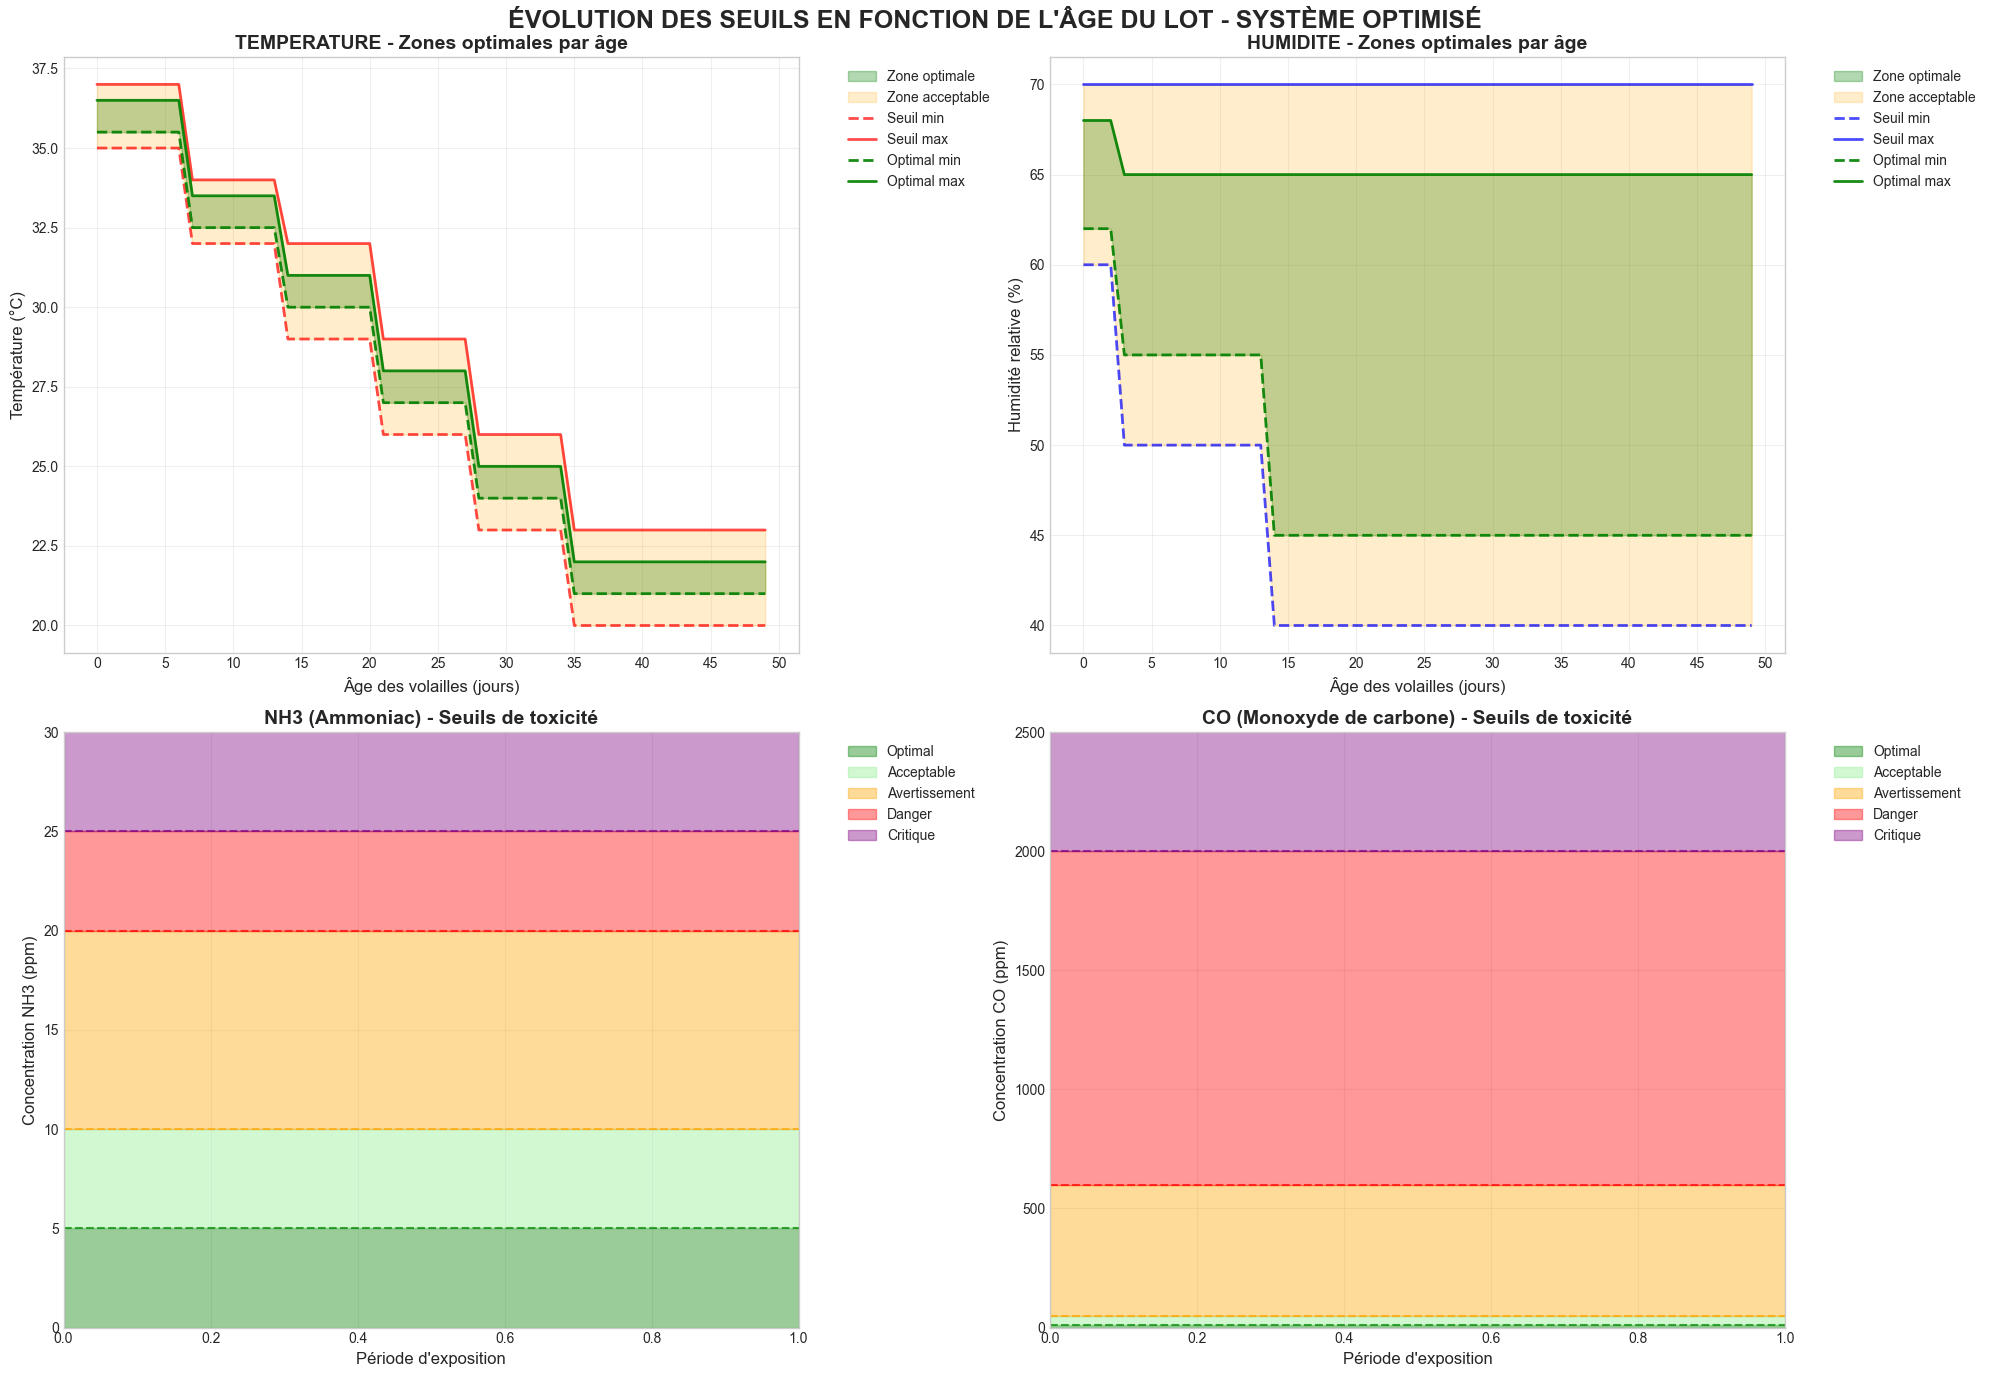


 ANALYSES DÉTAILLÉES PAR ÂGE

  ANALYSE POUR LOT DE 5 JOURS:
 🌡️  TEMPÉRATURE: 22.9°C
    • Niveau: 🔴 Danger
    • Zone optimale: 35.5-36.5°C
    • Recommandation: Risque d'hypothermie - Chauffage requis
 💧 HUMIDITÉ: 50.2%
    • Niveau: 🟡 Avertissement
    • Zone optimale: 55-65%
    • Recommandation: Humidité acceptable
 ☠️  GAZ TOXIQUES:
    • NH3: 0.0051 ppm - 🟢 Optimal
    • CO: 0.0165 ppm - 🟢 Optimal
 🎯 QUALITÉ DES PRÉDICTIONS:
    • MAE: 0.0268
    • R²: 1.0000
    • Niveau: 🟢 Excellente
    • Confiance: Très élevée
 ⚠️  RISQUE GLOBAL: 🟠 DANGER - Correction nécessaire

  ANALYSE POUR LOT DE 15 JOURS:
 🌡️  TEMPÉRATURE: 22.9°C
    • Niveau: 🔴 Danger
    • Zone optimale: 30-31°C
    • Recommandation: Risque d'hypothermie - Chauffage requis
 💧 HUMIDITÉ: 50.4%
    • Niveau: 🟢 Optimal
    • Zone optimale: 45-65%
    • Recommandation: Humidité idéale pour la santé respiratoire
 ☠️  GAZ TOXIQUES:
    • NH3: 0.0064 ppm - 🟢 Optimal
    • CO: 0.0170 ppm - 🟢 Optimal
 🎯 QUALITÉ DES PRÉDICTIO

/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [67]:
# 8. EXÉCUTION PRINCIPALE
if __name__ == "__main__":
    print(" LANCEMENT DU SYSTÈME DE SEUILS DYNAMIQUES AVEC DEEP LEARNING...")
    
    # Test du système amélioré
    predictor, sample = test_enhanced_system_dl()
    
    # Sauvegarde en .h5
    save_complete_system()
    
    print("\n" + "="*80)
    print(" SYSTÈME DE SEUILS DYNAMIQUES AVEC DEEP LEARNING TERMINÉ AVEC SUCCÈS!")
    print("="*80)
    
    print("\n FICHIERS CRÉÉS :")
    print("   • saved_models_dl_comparison/seuils_evolution_ameliore.png - Évolution des seuils")
    print("   • saved_models_dl_comparison/enhanced_dl_model.h5 - Modèle Deep Learning amélioré")
    print("   • saved_models_dl_comparison/enhanced_system_config.json - Configuration du système")
    
    print(f"\n PERFORMANCE DU MODÈLE {best_model_name}:")
    print(f"   • R²: {best_performance['r2']:.4f}")
    print(f"   • MAE: {best_performance['mae']:.4f}")
    print(f"   • RMSE: {best_performance['rmse']:.4f}")

In [ ]:
# ✅ convert_to_tflite.py - CONVERSION COMPLÈTE POUR MOBILE 
import tensorflow as tf
import numpy as np
import json
import joblib
from datetime import datetime
import os
import shutil

print("🔄 Conversion du modèle pour mobile (TensorFlow Lite)...")

def convert_model_to_tflite():
    """Convertit le modèle Deep Learning en format TensorFlow Lite"""
    
    # 1. Chargement du modèle original
    model_path = 'saved_models_dl_comparison/complete_dl_model.h5'
    try:
        model = tf.keras.models.load_model(model_path)
        print(f"✅ Modèle chargé: {model_path}")
        print(f"📊 Architecture: {model.input_shape} → {model.output_shape}")
    except Exception as e:
        print(f"❌ Erreur chargement modèle: {e}")
        return None, None
    
    # Vérification du shape d'entrée
    expected_input_shape = (None, 168, 47)  # 47 features
    if model.input_shape != expected_input_shape:
        print(f"⚠️  Attention: Shape d'entrée inattendu. Attendu: {expected_input_shape}, Reçu: {model.input_shape}")
    
    # 2. Création du dossier pour les assets mobile
    mobile_dir = 'mobile_assets'
    os.makedirs(mobile_dir, exist_ok=True)
    
    # 3. Conversion STANDARD
    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(model)
        
        # Configuration pour optimisation
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        
        # Support des opérations nécessaires
        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS,
            tf.lite.OpsSet.SELECT_TF_OPS
        ]
        
        # Conversion
        tflite_model = converter.convert()
        
        # Sauvegarde du modèle .tflite
        tflite_path = os.path.join(mobile_dir, 'poultry_monitor_model.tflite')
        with open(tflite_path, 'wb') as f:
            f.write(tflite_model)
        
        print(f"✅ Modèle TFLite sauvegardé: {tflite_path}")
        print(f"📦 Taille du modèle: {len(tflite_model) / 1024 / 1024:.2f} MB")
        
        return tflite_model, tflite_path
        
    except Exception as e:
        print(f"❌ Erreur conversion TFLite: {e}")
        return None, None

def optimize_for_mobile():
    """Optimisation avancée pour mobile"""
    
    try:
        # 1. Chargement du modèle
        model = tf.keras.models.load_model('saved_models_dl_comparison/complete_dl_model.h5')
        
        # Dataset représentatif avec 47 features
        def representative_dataset():
            for _ in range(100):
                data = np.random.randn(1, 168, 47).astype(np.float32)  # 47 features
                yield [data]
        
        # Configuration du convertisseur avec quantification
        converter = tf.lite.TFLiteConverter.from_keras_model(model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_dataset
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
        
        tflite_quant_model = converter.convert()
        quant_path = 'mobile_assets/poultry_monitor_model_quantized.tflite'
        with open(quant_path, 'wb') as f:
            f.write(tflite_quant_model)
            
        print(f"✅ Modèle quantifié sauvegardé: {quant_path}")
        print(f"📦 Taille: {len(tflite_quant_model) / 1024 / 1024:.2f} MB")
        
    except Exception as e:
        print(f"⚠️  Quantification échouée: {e}")
        print("   Le modèle standard fonctionnera toujours")

def prepare_mobile_assets():
    """Prépare tous les assets nécessaires pour le mobile"""
    
    mobile_dir = 'mobile_assets'
    os.makedirs(mobile_dir, exist_ok=True)
    
    # 1. Copie de la configuration
    try:
        shutil.copy2('saved_models_dl_comparison/complete_system_config.json', 
                    os.path.join(mobile_dir, 'app_config.json'))
        print("✅ Configuration d'application copiée")
    except Exception as e:
        print(f"❌ Erreur copie configuration: {e}")
    
    # 2. ✅ CORRECTION : Chargement et traitement des scalers
    print(" 📥 Chargement des scalers...")
    scaler_params = {}
    
    try:
        # Essayer de charger depuis différents emplacements possibles
        scaler_paths = [
            'saved_models_dl_comparison/feature_scalers.pkl',
            'saved_models_hybrid/feature_scalers.pkl'
        ]
        
        feature_scalers = None
        for scaler_path in scaler_paths:
            if os.path.exists(scaler_path):
                feature_scalers = joblib.load(scaler_path)
                print(f"✅ Scalers chargés depuis: {scaler_path}")
                break
        
        if feature_scalers is None:
            raise FileNotFoundError("Aucun fichier de scalers trouvé")
        
        # Vérifier le type de feature_scalers
        print(f" 🔍 Type de feature_scalers: {type(feature_scalers)}")
        
        # ✅ Gérer différents types de stockage des scalers
        if isinstance(feature_scalers, dict):
            # Cas 1: feature_scalers est un dictionnaire {index: scaler}
            print(" 📊 Format détecté: Dictionnaire de scalers")
            for i, scaler in feature_scalers.items():
                if hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
                    scaler_params[f'feature_{i}'] = {
                        'mean': float(scaler.mean_[0]),
                        'scale': float(scaler.scale_[0]),
                        'var': float(scaler.var_[0]) if hasattr(scaler, 'var_') else 1.0
                    }
                else:
                    print(f" ⚠️  Scaler {i} n'a pas les attributs attendus: {type(scaler)}")
                    
        elif isinstance(feature_scalers, list):
            # Cas 2: feature_scalers est une liste [scaler0, scaler1, ...]
            print(" 📊 Format détecté: Liste de scalers")
            for i, scaler in enumerate(feature_scalers):
                if hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
                    scaler_params[f'feature_{i}'] = {
                        'mean': float(scaler.mean_[0]),
                        'scale': float(scaler.scale_[0]),
                        'var': float(scaler.var_[0]) if hasattr(scaler, 'var_') else 1.0
                    }
                else:
                    print(f" ⚠️  Scaler {i} n'a pas les attributs attendus: {type(scaler)}")
        else:
            print(f" ❌ Format inattendu: {type(feature_scalers)}")
            raise ValueError(f"Format de scalers non supporté: {type(feature_scalers)}")
        
        print(f" ✅ {len(scaler_params)} paramètres de scalers préparés")
        
    except Exception as e:
        print(f" ❌ Erreur lors du chargement des scalers: {e}")
        print(" 🛠️  Création de scalers par défaut...")
        
        # Fallback: créer des scalers par défaut
        from sklearn.preprocessing import StandardScaler
        
        # Déterminer le nombre de features depuis la config si possible
        num_features = 47  # Valeur par défaut
        try:
            with open('saved_models_dl_comparison/complete_system_config.json', 'r') as f:
                config = json.load(f)
                num_features = len(config.get('feature_columns', []))
        except:
            pass
            
        for i in range(num_features):
            scaler_params[f'feature_{i}'] = {
                'mean': 0.0,
                'scale': 1.0,
                'var': 1.0
            }
        print(f" ✅ {len(scaler_params)} scalers par défaut créés")
    
    # Sauvegarde des paramètres des scalers
    try:
        with open(os.path.join(mobile_dir, 'scaler_params.json'), 'w') as f:
            json.dump(scaler_params, f, indent=2)
        print("✅ Paramètres des scalers sauvegardés")
    except Exception as e:
        print(f"❌ Erreur sauvegarde scalers: {e}")
    
    # 3. Création du metadata mobile
    try:
        mobile_metadata = {
            'model_name': 'Poultry Monitor Mobile',
            'version': '1.0.0',
            'input_shape': [1, 168, 47],  # 47 features
            'output_shape': [12],
            'features_count': 47,
            'horizons': {
                '1h': {'indices': [0, 1, 2, 3], 'description': '1 heure'},
                '6h': {'indices': [4, 5, 6, 7], 'description': '6 heures'},
                '24h': {'indices': [8, 9, 10, 11], 'description': '24 heures'}
            },
            'timestamp': datetime.now().isoformat(),
            'requirements': {
                'sequence_length': 168,
                'num_features': 47,
                'update_frequency': '1 heure',
                'min_app_version': '1.0'
            }
        }
        
        with open(os.path.join(mobile_dir, 'mobile_metadata.json'), 'w') as f:
            json.dump(mobile_metadata, f, indent=2)
        print("✅ Métadonnées mobiles sauvegardées")
        
    except Exception as e:
        print(f"❌ Erreur création métadonnées: {e}")
    
    # 4. Création d'un fichier README pour le mobile
    try:
        readme_content = """
# Poultry Monitor - Assets Mobiles

Ce dossier contient tous les fichiers nécessaires pour l'application mobile de surveillance des volailles.

## Fichiers :

- `poultry_monitor_model.tflite` : Modèle TensorFlow Lite pour les prédictions
- `app_config.json` : Configuration du système
- `scaler_params.json` : Paramètres de normalisation des données
- `mobile_metadata.json` : Métadonnées pour l'application mobile

## Utilisation :

1. Le modèle attend des données de forme [1, 168, 47] (1 séquence, 168 timesteps, 47 features)
2. Les données doivent être normalisées avec les paramètres dans `scaler_params.json`
3. Les prédictions sont au format [12] valeurs correspondant aux 3 horizons (1h, 6h, 24h)

## Horizons de prédiction :

- 1h : indices [0, 1, 2, 3] → [temp, humidity, nh3, co]
- 6h : indices [4, 5, 6, 7] → [temp, humidity, nh3, co]  
- 24h : indices [8, 9, 10, 11] → [temp, humidity, nh3, co]
"""
        with open(os.path.join(mobile_dir, 'README.md'), 'w', encoding='utf-8') as f:
            f.write(readme_content)
        print("✅ Fichier README créé")
        
    except Exception as e:
        print(f"⚠️  Erreur création README: {e}")
    
    print("\n✅ Assets mobiles préparés:")
    print(f"   • poultry_monitor_model.tflite - Modèle principal")
    print(f"   • app_config.json - Configuration de l'app")
    print(f"   • scaler_params.json - Paramètres de normalisation ({len(scaler_params)} features)")
    print(f"   • mobile_metadata.json - Métadonnées mobiles")
    print(f"   • README.md - Documentation")

def test_tflite_model():
    """Test du modèle TFLite converti"""
    
    print("\n🧪 Test du modèle TFLite...")
    
    try:
        # Chargement du modèle TFLite
        interpreter = tf.lite.Interpreter(model_path='mobile_assets/poultry_monitor_model.tflite')
        interpreter.allocate_tensors()
        
        # Obtenir les détails d'entrée/sortie
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()
        
        print(f"📥 Input: {input_details[0]['shape']} (dtype: {input_details[0]['dtype']})")
        print(f"📤 Output: {output_details[0]['shape']} (dtype: {output_details[0]['dtype']})")
        
        # Test avec des données factices (47 features)
        test_input = np.random.randn(1, 168, 47).astype(np.float32)
        
        interpreter.set_tensor(input_details[0]['index'], test_input)
        interpreter.invoke()
        
        output_data = interpreter.get_tensor(output_details[0]['index'])
        
        print(f"✅ Test réussi - Prédictions: {output_data.shape}")
        print(f"   Exemple de prédictions 1h:")
        print(f"   • Température: {output_data[0][0]:.3f}")
        print(f"   • Humidité: {output_data[0][1]:.3f}")
        print(f"   • NH3: {output_data[0][2]:.5f}")
        print(f"   • CO: {output_data[0][3]:.5f}")
        
        return True
        
    except Exception as e:
        print(f"❌ Test TFLite échoué: {e}")
        return False

def create_demo_data():
    """Crée des données de démonstration pour tester l'app mobile"""
    
    mobile_dir = 'mobile_assets'
    
    # Créer un exemple de données d'entrée
    demo_input = np.random.randn(168, 47).astype(np.float32)
    
    # Sauvegarder en format binaire et JSON
    try:
        # Format binaire pour performances
        demo_input.tofile(os.path.join(mobile_dir, 'demo_input.bin'))
        
        # Format JSON pour lisibilité
        demo_data_json = {
            'input_data': demo_input.tolist(),
            'description': 'Données de démonstration - 168 timesteps × 47 features',
            'timestamp': datetime.now().isoformat()
        }
        
        with open(os.path.join(mobile_dir, 'demo_input.json'), 'w') as f:
            json.dump(demo_data_json, f, indent=2)
            
        print("✅ Données de démonstration créées")
        print(f"   • demo_input.bin - Format binaire")
        print(f"   • demo_input.json - Format JSON")
        
    except Exception as e:
        print(f"⚠️  Erreur création données demo: {e}")

if __name__ == "__main__":
    print("🚀 PRÉPARATION POUR MOBILE - TENSORFLOW LITE")
    print("=" * 50)
    
    # Conversion principale
    tflite_model, tflite_path = convert_model_to_tflite()
    
    if tflite_model is None:
        print("❌ La conversion a échoué. Arrêt du processus.")
        exit(1)
    
    # Optimisation (optionnelle)
    optimize_for_mobile()
    
    # Préparation des assets
    prepare_mobile_assets()
    
    # Création de données de démonstration
    create_demo_data()
    
    # Test
    test_success = test_tflite_model()
    
    print(f"\n{'🎉' if test_success else '⚠️'} CONVERSION {'TERMINÉE!' if test_success else 'TERMINÉE AVEC AVERTISSEMENTS'}")
    print(f"📁 Dossier mobile_assets créé avec tous les fichiers nécessaires")
    
    # Afficher le résumé final
    if os.path.exists('mobile_assets'):
        print(f"\n📋 CONTENU DU DOSSIER MOBILE_ASSETS:")
        for file in os.listdir('mobile_assets'):
            file_path = os.path.join('mobile_assets', file)
            file_size = os.path.getsize(file_path) / 1024  # Taille en KB
            print(f"   • {file} ({file_size:.1f} KB)")

🔄 Conversion du modèle pour mobile (TensorFlow Lite)...
🚀 PRÉPARATION POUR MOBILE - TENSORFLOW LITE
✅ Modèle chargé: saved_models_dl_comparison/complete_dl_model.h5
📊 Architecture: (None, 168, 47) → (None, 12)
INFO:tensorflow:Assets written to: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmpa2md8xwk/assets


INFO:tensorflow:Assets written to: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmpa2md8xwk/assets
2025-11-05 17:10:45.749075: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2025-11-05 17:10:45.749093: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-05 17:10:45.749343: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmpa2md8xwk
2025-11-05 17:10:45.821732: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2025-11-05 17:10:45.821757: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmpa2md8xwk
2025-11-05 17:10:46.093234: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2025-11-05 17:10:46.594395: I tensorflow/cc/saved_model/loader.cc:215] Running initialization

✅ Modèle TFLite sauvegardé: mobile_assets/poultry_monitor_model.tflite
📦 Taille du modèle: 0.27 MB
INFO:tensorflow:Assets written to: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmp052bum5w/assets


INFO:tensorflow:Assets written to: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmp052bum5w/assets
/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2025-11-05 17:11:44.595409: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2025-11-05 17:11:44.595429: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-05 17:11:44.595698: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmp052bum5w
2025-11-05 17:11:44.663017: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2025-11-05 17:11:44.663040: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /var/folders/_b/hgh1rxn16cq

⚠️  Quantification échouée: /Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/tensorflow/python/saved_model/save.py:1313:0: error: 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall"]): called from
/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/tensorflow/python/saved_model/save.py:1313:0: error: failed to legalize operation 'tf.TensorListReserve' that was explicitly marked illegal
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall"]): called from
<unknown>:0: error: Lowering tensor list ops is failed. Please consider using Select TF ops and disabling `_experimental_lower_tensor_list_ops` flag in the TFLite converter object. For example, converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]\n converter._experimental_lower_tensor_list_o

ARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/tensorflow/python/saved_model/save.py":1280:0 at callsite("/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/tensorflow/lite/python/lite.py":1427:0 at callsite("/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/tensorflow/lite/python/convert_phase.py":205:0 at callsite("/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/tensorflow/lite/python/lite.py":1504:0 at callsite("/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/tensorflow/lite/python/lite.py":1526:0 at callsite("/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/tensorflow/lite/python/lite.py":1042:0 at callsite("/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/tensorflow/lite/python/lite.py":1065:0 at callsite("/var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/ipykernel_1957/4032031859.py":85:0 at "/var/folders/_b/hgh1rxn16cq0y0_k44qf57

In [ ]:
#  mobile_predictor.py - SYSTÈME COMPLET POUR MOBILE 
import numpy as np
import json
import tensorflow as tf
from datetime import datetime
import logging
import os

class MobilePoultryPredictor:
    """Système complet de prédiction pour application mobile """
    
    def __init__(self, model_path, config_path, scaler_params_path):
        try:
            # Vérification de l'existence des fichiers
            if not os.path.exists(model_path):
                raise FileNotFoundError(f"Modèle non trouvé: {model_path}")
            if not os.path.exists(config_path):
                raise FileNotFoundError(f"Configuration non trouvée: {config_path}")
            if not os.path.exists(scaler_params_path):
                raise FileNotFoundError(f"Paramètres scalers non trouvés: {scaler_params_path}")
            
            # Chargement du modèle TFLite
            self.interpreter = tf.lite.Interpreter(model_path=model_path)
            self.interpreter.allocate_tensors()
            
            self.input_details = self.interpreter.get_input_details()
            self.output_details = self.interpreter.get_output_details()
            
            # ✅ CORRECTION : Vérification du shape d'entrée
            expected_input_shape = (1, 168, 47)  # 47 features
            actual_input_shape = tuple(self.input_details[0]['shape'])
            if actual_input_shape != expected_input_shape:
                print(f"⚠️  Attention: Shape d'entrée inattendu. Attendu: {expected_input_shape}, Reçu: {actual_input_shape}")
            
            # Chargement de la configuration
            with open(config_path, 'r', encoding='utf-8') as f:
                self.config = json.load(f)
            
            # Chargement des paramètres des scalers
            with open(scaler_params_path, 'r', encoding='utf-8') as f:
                self.scaler_params = json.load(f)
            
            # ✅ CORRECTION : Initialisation avec gestion d'erreur
            self.threshold_system = MobilePoultryThresholds(self.config)
            
            print(f"✅ Mobile Predictor initialisé")
            print(f"📱 Modèle: {self.config.get('model_name', 'Unknown')}")
            print(f"📥 Input shape: {actual_input_shape}")
            print(f"📤 Output shape: {tuple(self.output_details[0]['shape'])}")
            print(f"🎯 Horizons: {list(self.config.get('horizon_mapping', {}).keys())}")
            print(f"📊 Nombre de scalers: {len(self.scaler_params)}")
            
        except Exception as e:
            print(f"❌ Erreur initialisation Mobile Predictor: {e}")
            raise
    
    def preprocess_mobile_input(self, input_data):
        """Prétraitement des données sur mobile (optimisé)"""
        # ✅ CORRECTION : input_data shape doit être (168, 47) pas (168, 4)
        if input_data.shape != (168, 47):
            raise ValueError(f"Mauvais format données d'entrée. Attendu: (168, 47), Reçu: {input_data.shape}")
        
        input_scaled = np.zeros_like(input_data, dtype=np.float32)
        
        for feature_idx in range(input_data.shape[1]):
            # Récupération des paramètres du scaler
            scaler_key = f'feature_{feature_idx}'
            if scaler_key in self.scaler_params:
                params = self.scaler_params[scaler_key]
                mean = params['mean']
                scale = params['scale']
                
                # ✅ CORRECTION : Éviter la division par zéro
                if scale == 0:
                    scale = 1.0
                
                # Normalisation manuelle (plus rapide que scikit-learn)
                input_scaled[:, feature_idx] = (input_data[:, feature_idx] - mean) / scale
            else:
                # Normalisation par défaut si pas de paramètres
                feature_mean = np.mean(input_data[:, feature_idx])
                feature_std = np.std(input_data[:, feature_idx])
                if feature_std == 0:
                    feature_std = 1.0
                input_scaled[:, feature_idx] = (input_data[:, feature_idx] - feature_mean) / feature_std
                print(f"⚠️  Scaler {feature_idx} non trouvé, utilisation normalisation par défaut")
        
        return input_scaled
    
    def predict(self, input_data, horizon='1h'):
        """Prédiction optimisée pour mobile """
        try:
            # Prétraitement
            input_scaled = self.preprocess_mobile_input(input_data)
            
            # ✅ CORRECTION : Formatage pour le modèle (1, 168, 47)
            input_tensor = input_scaled.reshape(1, 168, 47).astype(np.float32)
            
            # Vérification du format d'entrée
            expected_shape = tuple(self.input_details[0]['shape'])
            if input_tensor.shape != expected_shape:
                raise ValueError(f"Mauvais format d'entrée. Attendu: {expected_shape}, Reçu: {input_tensor.shape}")
            
            # Inférence
            self.interpreter.set_tensor(self.input_details[0]['index'], input_tensor)
            self.interpreter.invoke()
            
            # Récupération des prédictions
            predictions = self.interpreter.get_tensor(self.output_details[0]['index'])[0]
            
            # ✅ CORRECTION : Sélection de l'horizon depuis la config
            horizon_mapping = self.config.get('horizon_mapping', {
                '1h': [0, 1, 2, 3],
                '6h': [4, 5, 6, 7],
                '24h': [8, 9, 10, 11]
            })
            
            horizon_indices = horizon_mapping.get(horizon, [0, 1, 2, 3])
            
            # ✅ CORRECTION : Vérification des indices
            if len(horizon_indices) != 4:
                raise ValueError(f"Horizon {horizon} doit avoir 4 indices, reçu: {horizon_indices}")
            
            if max(horizon_indices) >= len(predictions):
                raise ValueError(f"Indices {horizon_indices} hors limites pour prédictions de taille {len(predictions)}")
            
            return {
                'temperature': float(predictions[horizon_indices[0]]),
                'humidity': float(predictions[horizon_indices[1]]),
                'nh3': float(predictions[horizon_indices[2]]),
                'co': float(predictions[horizon_indices[3]])
            }
            
        except Exception as e:
            print(f"❌ Erreur lors de la prédiction: {e}")
            raise
    
    def predict_with_analysis(self, input_data, age_jours, horizon='1h'):
        """Prédiction complète avec analyse des risques """
        try:
            # Validation des paramètres
            if age_jours is None or age_jours < 0:
                raise ValueError("L'âge doit être un nombre positif")
            
            if horizon not in self.config.get('horizon_mapping', {}):
                available_horizons = list(self.config.get('horizon_mapping', {}).keys())
                raise ValueError(f"Horizon {horizon} non supporté. Disponibles: {available_horizons}")
            
            # Prédiction
            predictions = self.predict(input_data, horizon)
            
            # Analyse des risques
            analysis = self.threshold_system.analyze_environmental_conditions(
                predictions['temperature'],
                predictions['humidity'],
                predictions['nh3'], 
                predictions['co'],
                age_jours
            )
            
            return {
                'predictions': predictions,
                'analysis': analysis,
                'metadata': {
                    'horizon': horizon,
                    'age_jours': age_jours,
                    'timestamp': datetime.now().isoformat(),
                    'model_version': self.config.get('model_name', 'Unknown')
                }
            }
            
        except Exception as e:
            print(f"❌ Erreur lors de l'analyse: {e}")
            raise

class MobilePoultryThresholds:
    """Système de seuils optimisé pour mobile """
    
    def __init__(self, config):
        self.config = config
        # ✅ CORRECTION : Gestion des configurations manquantes
        self.thresholds_config = config.get('thresholds_config', self._get_default_thresholds())
        self.risk_levels = self.thresholds_config.get('risk_levels', {
            'optimal': '🟢 Optimal',
            'warning': '🟡 Avertissement', 
            'danger': '🔴 Danger',
            'critical': '💀 Critique'
        })
    
    def _get_default_thresholds(self):
        """Seuils par défaut si non trouvés dans la config"""
        return {
            'temperature': {
                '0-7': {'min': 35, 'max': 37, 'optimal_min': 35.5, 'optimal_max': 36.5},
                '7-14': {'min': 32, 'max': 34, 'optimal_min': 32.5, 'optimal_max': 33.5},
                '14-21': {'min': 29, 'max': 32, 'optimal_min': 30, 'optimal_max': 31},
                '21-28': {'min': 26, 'max': 29, 'optimal_min': 27, 'optimal_max': 28},
                '28-35': {'min': 23, 'max': 26, 'optimal_min': 24, 'optimal_max': 25},
                '35-1000': {'min': 20, 'max': 23, 'optimal_min': 21, 'optimal_max': 22}
            },
            'humidity': {
                '0-3': {'min': 60, 'max': 70, 'optimal_min': 62, 'optimal_max': 68},
                '3-14': {'min': 50, 'max': 70, 'optimal_min': 55, 'optimal_max': 65},
                '14-1000': {'min': 40, 'max': 70, 'optimal_min': 45, 'optimal_max': 65}
            },
            'nh3': {'optimal': 5, 'warning': 10, 'danger': 20, 'critical': 25},
            'co': {'optimal': 10, 'warning': 50, 'danger': 600, 'critical': 2000},
            'risk_levels': {
                'optimal': '🟢 Optimal',
                'warning': '🟡 Avertissement', 
                'danger': '🔴 Danger',
                'critical': '💀 Critique'
            }
        }
    
    def get_temperature_analysis(self, value, age_jours):
        # ✅ CORRECTION : Gestion des âges hors limites
        if age_jours < 0:
            raise ValueError("L'âge ne peut pas être négatif")
        
        # Recherche des seuils par âge (optimisé)
        temperature_config = self.thresholds_config.get('temperature', {})
        found_thresholds = False
        
        for age_range, thresholds in temperature_config.items():
            if age_range not in ['risk_levels', 'manual_thresholds'] and '-' in age_range:
                try:
                    start, end = map(int, age_range.split('-'))
                    if start <= age_jours < end:
                        min_temp = thresholds['min']
                        max_temp = thresholds['max']
                        optimal_min = thresholds['optimal_min']
                        optimal_max = thresholds['optimal_max']
                        found_thresholds = True
                        break
                except (ValueError, KeyError) as e:
                    print(f"⚠️  Erreur traitement seuils {age_range}: {e}")
                    continue
        
        # ✅ CORRECTION : Valeurs par défaut si âge non trouvé
        if not found_thresholds:
            min_temp, max_temp, optimal_min, optimal_max = 20, 23, 21, 22
            print(f"⚠️  Âge {age_jours} non trouvé dans les seuils, utilisation défaut")
        
        # Détermination du niveau de risque
        if optimal_min <= value <= optimal_max:
            risk_level = self.risk_levels['optimal']
            color = 'green'
            description = 'Conditions optimales'
        elif min_temp <= value <= max_temp:
            risk_level = self.risk_levels['warning']
            color = 'orange'
            description = 'Conditions acceptables'
        elif value < min_temp:
            risk_level = self.risk_levels['danger']
            color = 'red'
            description = 'Chauffage requis'
        else:
            risk_level = self.risk_levels['critical']
            color = 'purple'
            description = 'Refroidissement urgent'
        
        return {
            'value': value,
            'min_threshold': min_temp,
            'max_threshold': max_temp,
            'optimal_range': [optimal_min, optimal_max],
            'risk_level': risk_level,
            'color': color,
            'description': description
        }
    
    def get_humidity_analysis(self, value, age_jours):
        if age_jours < 0:
            raise ValueError("L'âge ne peut pas être négatif")
            
        humidity_config = self.thresholds_config.get('humidity', {})
        found_thresholds = False
        
        for age_range, thresholds in humidity_config.items():
            if age_range not in ['risk_levels', 'manual_thresholds'] and '-' in age_range:
                try:
                    start, end = map(int, age_range.split('-'))
                    if start <= age_jours < end:
                        min_hum = thresholds['min']
                        max_hum = thresholds['max']
                        optimal_min = thresholds['optimal_min']
                        optimal_max = thresholds['optimal_max']
                        found_thresholds = True
                        break
                except (ValueError, KeyError) as e:
                    print(f"⚠️  Erreur traitement humidité {age_range}: {e}")
                    continue
        
        if not found_thresholds:
            min_hum, max_hum, optimal_min, optimal_max = 40, 70, 45, 65
            print(f"⚠️  Âge {age_jours} non trouvé dans les seuils humidité, utilisation défaut")
        
        if optimal_min <= value <= optimal_max:
            risk_level = self.risk_levels['optimal']
            color = 'green'
            description = 'Humidité idéale'
        elif min_hum <= value <= max_hum:
            risk_level = self.risk_levels['warning']
            color = 'orange'
            description = 'Humidité acceptable'
        elif value < min_hum:
            risk_level = self.risk_levels['danger']
            color = 'red'
            description = 'Air trop sec'
        else:
            risk_level = self.risk_levels['critical']
            color = 'purple'
            description = 'Air trop humide'
        
        return {
            'value': value,
            'min_threshold': min_hum,
            'max_threshold': max_hum,
            'optimal_range': [optimal_min, optimal_max],
            'risk_level': risk_level,
            'color': color,
            'description': description
        }
    
    def get_gas_analysis(self, gas_type, value):
        # ✅ CORRECTION : Gestion des gaz inconnus
        if gas_type not in ['nh3', 'co']:
            raise ValueError(f"Type de gaz non supporté: {gas_type}")
        
        thresholds = self.thresholds_config.get(gas_type, {})
        
        # ✅ CORRECTION : Valeurs par défaut si seuils manquants
        if not thresholds:
            if gas_type == 'nh3':
                thresholds = {'optimal': 5, 'warning': 10, 'danger': 20, 'critical': 25}
            else:  # 'co'
                thresholds = {'optimal': 10, 'warning': 50, 'danger': 600, 'critical': 2000}
            print(f"⚠️  Seuils {gas_type} non trouvés, utilisation défaut")
        
        if value < thresholds['optimal']:
            risk_level = self.risk_levels['optimal']
            color = 'green'
            description = f'{gas_type.upper()} sécuritaire'
        elif value < thresholds['warning']:
            risk_level = self.risk_levels['warning']
            color = 'orange'
            description = f'{gas_type.upper()} acceptable'
        elif value < thresholds['danger']:
            risk_level = self.risk_levels['danger']
            color = 'red'
            description = f'{gas_type.upper()} dangereux'
        else:
            risk_level = self.risk_levels['critical']
            color = 'purple'
            description = f'{gas_type.upper()} CRITIQUE'
        
        return {
            'value': value,
            'risk_level': risk_level,
            'color': color,
            'description': description
        }
    
    def analyze_environmental_conditions(self, temperature, humidity, nh3, co, age_jours):
        """Analyse complète optimisée pour mobile """
        try:
            temp_analysis = self.get_temperature_analysis(temperature, age_jours)
            hum_analysis = self.get_humidity_analysis(humidity, age_jours)
            nh3_analysis = self.get_gas_analysis('nh3', nh3)
            co_analysis = self.get_gas_analysis('co', co)
            
            # Évaluation globale
            risk_levels = [
                temp_analysis['risk_level'],
                hum_analysis['risk_level'],
                nh3_analysis['risk_level'],
                co_analysis['risk_level']
            ]
            
            if '💀 Critique' in risk_levels or risk_levels.count('🔴 Danger') >= 2:
                global_risk = "🔴 CRITIQUE - Intervention immédiate"
                global_color = 'purple'
            elif '🔴 Danger' in risk_levels:
                global_risk = "🟠 DANGER - Correction nécessaire"
                global_color = 'red'
            elif '🟡 Avertissement' in risk_levels:
                global_risk = "🟡 ATTENTION - Surveillance accrue"
                global_color = 'orange'
            else:
                global_risk = "🟢 OPTIMAL - Conditions excellentes"
                global_color = 'green'
            
            return {
                'temperature': temp_analysis,
                'humidity': hum_analysis,
                'nh3': nh3_analysis,
                'co': co_analysis,
                'global_risk': global_risk,
                'global_color': global_color
            }
            
        except Exception as e:
            print(f"❌ Erreur lors de l'analyse environnementale: {e}")
            # ✅ CORRECTION : Retourner une analyse d'erreur
            return {
                'temperature': {'risk_level': '❌ Erreur', 'description': 'Analyse indisponible'},
                'humidity': {'risk_level': '❌ Erreur', 'description': 'Analyse indisponible'},
                'nh3': {'risk_level': '❌ Erreur', 'description': 'Analyse indisponible'},
                'co': {'risk_level': '❌ Erreur', 'description': 'Analyse indisponible'},
                'global_risk': "❌ ERREUR - Analyse impossible",
                'global_color': 'gray'
            }

# ✅ EXEMPLE D'UTILISATION SUR MOBILE 
def mobile_demo():
    """Démonstration d'utilisation sur mobile """
    
    print("📱 DÉMO SYSTÈME MOBILE")
    print("=" * 50)
    
    try:
        # Initialisation du prédicteur mobile
        predictor = MobilePoultryPredictor(
            model_path='mobile_assets/poultry_monitor_model.tflite',
            config_path='mobile_assets/app_config.json', 
            scaler_params_path='mobile_assets/scaler_params.json'
        )
        
        # ✅ CORRECTION : Génération de données de test avec 47 features
        test_data = np.random.randn(168, 47).astype(np.float32)
        print(f"📊 Données test créées: {test_data.shape}")
        
        # Test avec différents scénarios
        test_scenarios = [
            {"age": 5, "horizon": "1h", "desc": "Poussins - Court terme"},
            {"age": 15, "horizon": "6h", "desc": "Croissance - Moyen terme"},
            {"age": 30, "horizon": "24h", "desc": "Adulte - Long terme"},
            {"age": 45, "horizon": "1h", "desc": "Âge avancé - Test limites"}
        ]
        
        for scenario in test_scenarios:
            print(f"\n🎯 {scenario['desc']}")
            print(f"   Âge: {scenario['age']} jours | Horizon: {scenario['horizon']}")
            
            try:
                result = predictor.predict_with_analysis(
                    test_data, 
                    scenario['age'], 
                    scenario['horizon']
                )
                
                pred = result['predictions']
                analysis = result['analysis']
                
                print(f"   📊 Prédictions:")
                print(f"      • Temp: {pred['temperature']:.1f}°C")
                print(f"      • Hum: {pred['humidity']:.1f}%")
                print(f"      • NH3: {pred['nh3']:.4f} ppm")
                print(f"      • CO: {pred['co']:.4f} ppm")
                
                print(f"   ⚠️  Analyse:")
                print(f"      • Temp: {analysis['temperature']['risk_level']}")
                print(f"      • Hum: {analysis['humidity']['risk_level']}")
                print(f"      • NH3: {analysis['nh3']['risk_level']}")
                print(f"      • CO: {analysis['co']['risk_level']}")
                
                print(f"   🎯 Risque global: {analysis['global_risk']}")
                
            except Exception as e:
                print(f"   ❌ Erreur scénario {scenario['age']}j: {e}")
        
        print(f"\n✅ Démonstration terminée avec succès!")
        
    except Exception as e:
        print(f"❌ Erreur lors de la démonstration: {e}")
        print("💡 Vérifiez que les fichiers dans mobile_assets/ sont présents:")

# ✅ FONCTION DE TEST AVEC DONNÉES RÉELLES
def test_with_real_data():
    """Test avec les données de démonstration sauvegardées"""
    
    print("\n🧪 TEST AVEC DONNÉES RÉELLES")
    print("=" * 40)
    
    try:
        predictor = MobilePoultryPredictor(
            model_path='mobile_assets/poultry_monitor_model.tflite',
            config_path='mobile_assets/app_config.json', 
            scaler_params_path='mobile_assets/scaler_params.json'
        )
        
        # Charger les données de démonstration si disponibles
        demo_path = 'mobile_assets/demo_input.json'
        if os.path.exists(demo_path):
            with open(demo_path, 'r') as f:
                demo_data = json.load(f)
            
            input_data = np.array(demo_data['input_data'], dtype=np.float32)
            print(f"✅ Données de démonstration chargées: {input_data.shape}")
            
            # Test rapide
            result = predictor.predict_with_analysis(input_data, age_jours=25, horizon='1h')
            print(f"🎯 Test réussi! Prédictions obtenues pour horizon 1h")
            
        else:
            print("ℹ️  Fichier de démonstration non trouvé, utilisation données aléatoires")
            input_data = np.random.randn(168, 47).astype(np.float32)
            result = predictor.predict_with_analysis(input_data, age_jours=25, horizon='1h')
            print(f"🎯 Test avec données aléatoires réussi!")
            
    except Exception as e:
        print(f"❌ Test avec données réelles échoué: {e}")

if __name__ == "__main__":
    print("🚀 LANCEMENT DU SYSTÈME MOBILE CORRIGÉ")
    
    # Test principal
    mobile_demo()
    
    # Test supplémentaire avec données réelles
    test_with_real_data()
    
    print(f"\n🎉 SYSTÈME MOBILE PRÊT À L'EMPLOI!")

🚀 LANCEMENT DU SYSTÈME MOBILE CORRIGÉ
📱 DÉMO SYSTÈME MOBILE (VERSION CORRIGÉE)
✅ Mobile Predictor initialisé
📱 Modèle: CNN-BiLSTM-Attention_Complete
📥 Input shape: (1, 168, 47)
📤 Output shape: (1, 12)
🎯 Horizons: ['1h', '6h', '24h']
📊 Nombre de scalers: 47
📊 Données test créées: (168, 47)

🎯 Poussins - Court terme
   Âge: 5 jours | Horizon: 1h
   📊 Prédictions:
      • Temp: 27.7°C
      • Hum: 45.4%
      • NH3: 0.0019 ppm
      • CO: 0.0247 ppm
   ⚠️  Analyse:
      • Temp: 🔴 Danger
      • Hum: 🔴 Danger
      • NH3: 🟢 Optimal
      • CO: 🟢 Optimal
   🎯 Risque global: 🔴 CRITIQUE - Intervention immédiate

🎯 Croissance - Moyen terme
   Âge: 15 jours | Horizon: 6h
   📊 Prédictions:
      • Temp: 26.7°C
      • Hum: 47.1%
      • NH3: 0.0014 ppm
      • CO: 0.0150 ppm
   ⚠️  Analyse:
      • Temp: 🔴 Danger
      • Hum: 🟢 Optimal
      • NH3: 🟢 Optimal
      • CO: 🟢 Optimal
   🎯 Risque global: 🟠 DANGER - Correction nécessaire

🎯 Adulte - Long terme
   Âge: 30 jours | Horizon: 24h
   📊 Pré

### DÉMONSTRATION TEMPS RÉEL AVEC GRAPHIQUES DYNAMIQUES

 ITÉRATION 10 - TEMPS ÉCOULÉ: 272.4s

 HORIZON 1h:
----------------------------------------
  23.2°C |  61.7% |  0.0094ppm |  0.0166ppm
 Risque: 🟠 DANGER
 ALERTE DANGER: 🟠 DANGER - Correction nécessaire
  ACTION: VENTILATION ET CONTRÔLE URGENT!

 HORIZON 6h:
----------------------------------------
  29.8°C |  51.3% |  0.0007ppm |  0.0169ppm
 Risque: 🔴 CRITIQUE
 ALERTE CRITIQUE: 🔴 CRITIQUE - Intervention immédiate requise
 ACTION: ÉVACUATION IMMÉDIATE REQUISE!

 HORIZON 24h:
----------------------------------------
  21.6°C |  64.0% |  0.0113ppm |  0.0030ppm
 Risque: 🟠 DANGER
 ALERTE DANGER: 🟠 DANGER - Correction nécessaire
  ACTION: VENTILATION ET CONTRÔLE URGENT!

 GRAPHIQUES EN DIRECT (Itération 10):
--------------------------------------------------


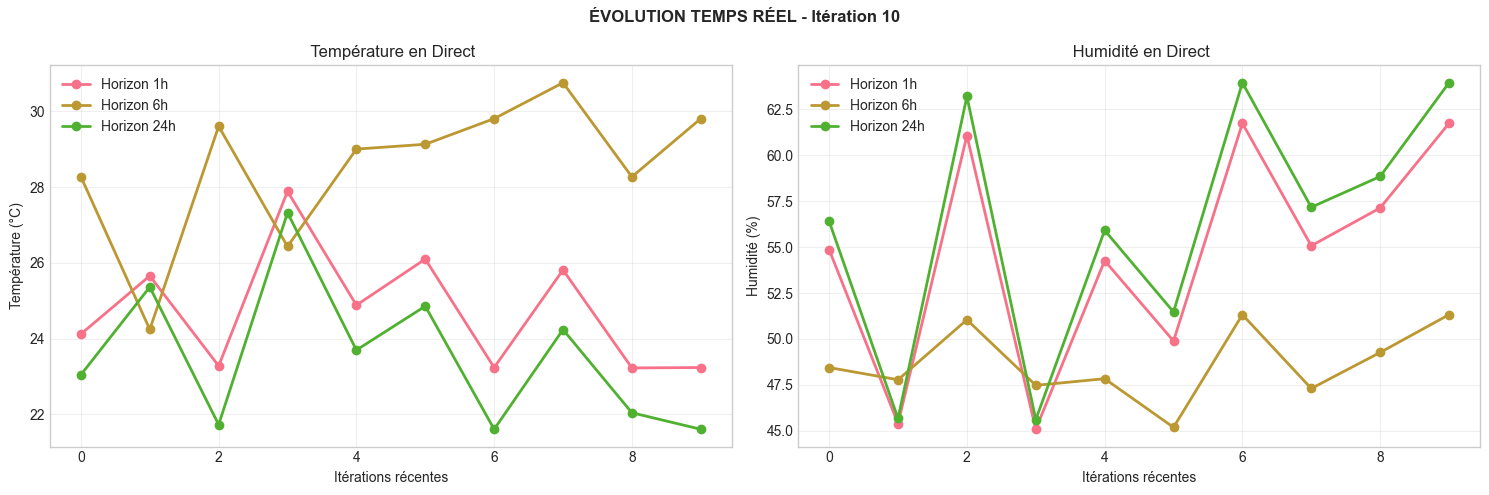


 RECOMMANDATIONS EN DIRECT:
----------------------------------------
🔴 Conditions dangereuses
   • Augmenter la ventilation IMMÉDIATEMENT
   • Ajuster le chauffage/refroidissement
   • Vérifier les niveaux de gaz
🔥 Température: Risque d'hypothermie - Chauffage requis

 Prochaine mise à jour dans 30 secondes...

 DÉMONSTRATION TERMINÉE - 10 itérations effectuées

 STATISTIQUES DÉMONSTRATION:
   • Durée: 5 minutes
   • Itérations: 10
   • Intervalle: 30 secondes
   • Graphiques: Toutes les 5 itérations


In [48]:
print("=== DÉMONSTRATION TEMPS RÉEL AVEC GRAPHIQUES DYNAMIQUES ===")

import time
import random
from IPython.display import clear_output
import matplotlib.pyplot as plt

class RealTimeDemoWithGraphs:
    """Démonstration temps réel avec graphiques dynamiques"""
    
    def __init__(self, predictor, X_test, y_test, feature_columns):
        self.predictor = predictor
        self.X_test = X_test
        self.y_test = y_test
        self.feature_columns = feature_columns
        self.history = []  # Pour stocker l'historique des prédictions
        
    def simulate_real_time_data(self, n_samples=20):
        """Simule des données temps réel"""
        indices = random.sample(range(len(self.X_test)), n_samples)
        return [(self.X_test[i], self.y_test[i]) for i in indices]
    
    def create_dynamic_dashboard(self, age_jours, duration_minutes=5):
        """Crée un dashboard temps réel avec graphiques"""
        
        print(f" DÉMARRAGE DÉMONSTRATION TEMPS RÉEL")
        print(f"  Durée: {duration_minutes} minutes")
        print(f" Âge du lot: {age_jours} jours")
        print(f" Modèle: {self.predictor.model_name}")
        print("\n" + "="*70)
        
        real_time_samples = self.simulate_real_time_data(30)
        start_time = time.time()
        end_time = start_time + (duration_minutes * 60)
        
        iteration = 0
        while time.time() < end_time:
            iteration += 1
            clear_output(wait=True)
            
            # Sélection d'un échantillon aléatoire
            sample_data, actual_values = random.choice(real_time_samples)
            
            print(f" ITÉRATION {iteration} - TEMPS ÉCOULÉ: {time.time() - start_time:.1f}s")
            print("="*70)
            
            # Stocker les résultats pour graphiques
            iteration_results = {'timestamp': time.time(), 'horizons': {}}
            
            # Prédictions pour les 3 horizons
            for horizon in ['1h', '6h', '24h']:
                try:
                    result = self.predictor.predict_with_analysis(sample_data, age_jours, horizon)
                    iteration_results['horizons'][horizon] = result
                    
                    print(f"\n HORIZON {horizon}:")
                    print("-" * 40)
                    
                    pred = result['predictions']
                    env_analysis = result['environmental_analysis']
                    
                    # Affichage compact
                    print(f"  {pred['temperature']:.1f}°C | "
                          f" {pred['humidity']:.1f}% | "
                          f" {pred['nh3']:.4f}ppm | "
                          f" {pred['co']:.4f}ppm")
                    
                    print(f" Risque: {env_analysis['risque_global'].split(' - ')[0]}")
                    
                    # Alertes critiques
                    risk_level = env_analysis['risque_global']
                    if 'CRITIQUE' in risk_level:
                        print(f" ALERTE CRITIQUE: {risk_level}")
                        print(f" ACTION: ÉVACUATION IMMÉDIATE REQUISE!")
                    elif 'DANGER' in risk_level:
                        print(f" ALERTE DANGER: {risk_level}")
                        print(f"  ACTION: VENTILATION ET CONTRÔLE URGENT!")
                    
                except Exception as e:
                    print(f" Erreur horizon {horizon}: {e}")
            
            self.history.append(iteration_results)
            
            # Graphiques dynamiques toutes les 5 itérations
            if iteration % 5 == 0:
                self.create_live_graphs(age_jours, iteration)
            
            # Recommandations
            self.show_recommendations(iteration_results)
            
            print(f"\n Prochaine mise à jour dans 30 secondes...")
            time.sleep(30)
        
        print(f"\n DÉMONSTRATION TERMINÉE - {iteration} itérations effectuées")
        return iteration
    
    def create_live_graphs(self, age_jours, iteration):
        """Crée des graphiques en direct"""
        
        if len(self.history) < 2:
            return
            
        print(f"\n GRAPHIQUES EN DIRECT (Itération {iteration}):")
        print("-" * 50)
        
        # Extraire les données pour les graphiques
        horizons = ['1h', '6h', '24h']
        variables = ['temperature', 'humidity']
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'ÉVOLUTION TEMPS RÉEL - Itération {iteration}', fontweight='bold')
        
        # Graphique température
        for horizon in horizons:
            temps = []
            for result in self.history[-10:]:  # Dernières 10 itérations
                if horizon in result['horizons']:
                    temp = result['horizons'][horizon]['predictions']['temperature']
                    temps.append(temp)
            
            if temps:
                axes[0].plot(range(len(temps)), temps, 'o-', label=f'Horizon {horizon}', linewidth=2)
        
        axes[0].set_title(' Température en Direct')
        axes[0].set_xlabel('Itérations récentes')
        axes[0].set_ylabel('Température (°C)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Graphique humidité
        for horizon in horizons:
            hums = []
            for result in self.history[-10:]:
                if horizon in result['horizons']:
                    hum = result['horizons'][horizon]['predictions']['humidity']
                    hums.append(hum)
            
            if hums:
                axes[1].plot(range(len(hums)), hums, 'o-', label=f'Horizon {horizon}', linewidth=2)
        
        axes[1].set_title(' Humidité en Direct')
        axes[1].set_xlabel('Itérations récentes')
        axes[1].set_ylabel('Humidité (%)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def show_recommendations(self, results):
        """Affiche les recommandations en direct"""
        
        print(f"\n RECOMMANDATIONS EN DIRECT:")
        print("-" * 40)
        
        # Analyser le risque global du dernier horizon
        if '1h' in results['horizons']:
            risk_global = results['horizons']['1h']['environmental_analysis']['risque_global']
            
            if 'OPTIMAL' in risk_global:
                print(" Conditions excellentes")
                print("   • Maintenir les paramètres actuels")
                print("   • Surveiller régulièrement")
                
            elif 'ATTENTION' in risk_global:
                print("⚠️  Conditions sous-optimales")
                print("   • Vérifier la ventilation")
                print("   • Surveiller la température")
                print("   • Contrôler l'humidité")
                
            elif 'DANGER' in risk_global:
                print("🔴 Conditions dangereuses")
                print("   • Augmenter la ventilation IMMÉDIATEMENT")
                print("   • Ajuster le chauffage/refroidissement")
                print("   • Vérifier les niveaux de gaz")
                
            elif 'CRITIQUE' in risk_global:
                print("💀 CONDITIONS CRITIQUES")
                print("   • ÉVACUATION IMMÉDIATE")
                print("   • ALERTER LES SECOURS")
                print("   • COUPER LES SYSTÈMES")
            
            # Recommandations spécifiques par variable
            env_analysis = results['horizons']['1h']['environmental_analysis']
            
            temp_status = env_analysis['temperature']['niveau_risque']
            if 'Danger' in temp_status or 'Critique' in temp_status:
                print(f"🔥 Température: {env_analysis['temperature']['description']}")
            
            hum_status = env_analysis['humidity']['niveau_risque']
            if 'Danger' in hum_status or 'Critique' in hum_status:
                print(f"💧 Humidité: {env_analysis['humidity']['description']}")
            
            nh3_status = env_analysis['nh3']['niveau_risque']
            if 'Danger' in nh3_status or 'Critique' in nh3_status:
                print(f"☠️ NH3: {env_analysis['nh3']['description']}")
            
            co_status = env_analysis['co']['niveau_risque']
            if 'Danger' in co_status or 'Critique' in co_status:
                print(f"🔥 CO: {env_analysis['co']['description']}")

# Lancement de la démonstration
print(" PRÉPARATION DÉMONSTRATION TEMPS RÉEL AVEC GRAPHIQUES")

# Création du démonstrateur
demo_with_graphs = RealTimeDemoWithGraphs(
    predictor=predictor_dl,
    X_test=X_test_scaled,
    y_test=y_test,
    feature_columns=feature_columns
)

# Démonstration de 5 minutes avec graphiques
demo_duration = 5  # minutes
demo_age = 25      # jours

print(f"\n LANCEMENT DÉMO AVEC GRAPHIQUES - {demo_duration} MINUTES")
demo_iterations = demo_with_graphs.create_dynamic_dashboard(demo_age, demo_duration)

print(f"\n STATISTIQUES DÉMONSTRATION:")
print(f"   • Durée: {demo_duration} minutes")
print(f"   • Itérations: {demo_iterations}")
print(f"   • Intervalle: 30 secondes")
print(f"   • Graphiques: Toutes les 5 itérations")

In [ ]:
# print("=== CONVERSION MOBILE & COMPARAISON ===")

# import tensorflow as tf
# import numpy as np
# from sklearn.metrics import mean_absolute_error, r2_score
# import time
# import json
# import os

# def convert_to_mobile_corrected(original_model, X_test, y_test, model_name):
#     """Convertit le modèle pour mobile avec corrections et compare les performances"""
    
#     print(f"🔄 CONVERSION DU MODÈLE {model_name} POUR MOBILE")
#     print("=" * 60)
    
#     # Créer le dossier si nécessaire
#     os.makedirs("saved_models_dl_comparison", exist_ok=True)
    
#     # 1. CONVERSION AVEC PARAMÈTRES SPÉCIAUX POUR COMPATIBILITÉ
#     print("1. Conversion avec paramètres de compatibilité...")
    
#     try:
#         # Méthode 1: Conversion standard avec support étendu
#         converter = tf.lite.TFLiteConverter.from_keras_model(original_model)
        
#         # PARAMÈTRES CRITIQUES POUR ÉVITER LES ERREURS:
#         converter.optimizations = [tf.lite.Optimize.DEFAULT]
#         converter.target_spec.supported_ops = [
#             tf.lite.OpsSet.TFLITE_BUILTINS,  # Opérations standard TFLite
#             tf.lite.OpsSet.SELECT_TF_OPS,    # Support des opérations TensorFlow
#         ]
        
#         # Désactiver certaines vérifications problématiques
#         converter.experimental_new_converter = True
#         converter.allow_custom_ops = True  # Autoriser les opérations personnalisées
        
#         # Conversion
#         tflite_model = converter.convert()
        
#         tflite_model_path = f"saved_models_dl_comparison/{model_name}_mobile_compatible.tflite"
#         with open(tflite_model_path, 'wb') as f:
#             f.write(tflite_model)
        
#         print(f"✅ Modèle TFLite sauvegardé: {tflite_model_path}")
#         print(f"📦 Taille: {len(tflite_model) / (1024*1024):.2f} MB")
        
#     except Exception as e:
#         print(f"❌ Erreur méthode 1: {e}")
        
#         # Méthode 2: Conversion avec sauvegarde intermédiaire
#         try:
#             print("🔄 Tentative avec sauvegarde intermédiaire...")
            
#             # Sauvegarder le modèle Keras d'abord
#             temp_model_path = f"saved_models_dl_comparison/{model_name}_temp"
#             original_model.save(temp_model_path)
            
#             # Charger et convertir depuis le fichier
#             converter = tf.lite.TFLiteConverter.from_saved_model(temp_model_path)
#             converter.optimizations = [tf.lite.Optimize.DEFAULT]
#             converter.target_spec.supported_ops = [
#                 tf.lite.OpsSet.TFLITE_BUILTINS,
#                 tf.lite.OpsSet.SELECT_TF_OPS,
#             ]
#             converter.allow_custom_ops = True
            
#             tflite_model = converter.convert()
            
#             tflite_model_path = f"saved_models_dl_comparison/{model_name}_mobile_from_saved.tflite"
#             with open(tflite_model_path, 'wb') as f:
#                 f.write(tflite_model)
                
#             print(f"✅ Modèle sauvegardé puis converti: {tflite_model_path}")
            
#         except Exception as e2:
#             print(f"❌ Échec méthode 2: {e2}")
#             return None, None
    
#     # 2. TEST DU MODÈLE CONVERTI
#     print("\n2. Test du modèle converti...")
    
#     try:
#         interpreter = tf.lite.Interpreter(model_content=tflite_model)
#         interpreter.allocate_tensors()
        
#         input_details = interpreter.get_input_details()
#         output_details = interpreter.get_output_details()
        
#         print(f"📱 Détails du modèle mobile:")
#         print(f"   • Input: {input_details[0]['shape']} ({input_details[0]['dtype']})")
#         print(f"   • Output: {output_details[0]['shape']} ({output_details[0]['dtype']})")
        
#     except Exception as e:
#         print(f"❌ Erreur initialisation interpréteur: {e}")
#         return None, None
    
#     # 3. COMPARAISON DES PERFORMANCES
#     print("\n3. Comparaison des performances...")
    
#     # Prédictions modèle original
#     original_predictions = original_model.predict(X_test, verbose=0)
    
#     # Prédictions modèle mobile
#     mobile_predictions = []
    
#     for i in range(len(X_test)):
#         try:
#             input_data = X_test[i:i+1].astype(np.float32)
            
#             # Vérifier et ajuster la forme si nécessaire
#             expected_shape = tuple(input_details[0]['shape'])
#             if input_data.shape != expected_shape:
#                 input_data = input_data.reshape(expected_shape)
            
#             interpreter.set_tensor(input_details[0]['index'], input_data)
#             interpreter.invoke()
#             output_data = interpreter.get_tensor(output_details[0]['index'])
#             mobile_predictions.append(output_data[0])
            
#         except Exception as e:
#             print(f"⚠️  Erreur prédiction {i}: {e}")
#             mobile_predictions.append(np.zeros_like(original_predictions[0]))
    
#     mobile_predictions = np.array(mobile_predictions)
    
#     # 4. MÉTRIQUES DE PERFORMANCE
#     print("\n4. Métriques de performance:")
    
#     # Métriques modèle original
#     mae_original = mean_absolute_error(y_test, original_predictions)
#     r2_original = r2_score(y_test, original_predictions)
    
#     # Métriques modèle mobile
#     mae_mobile = mean_absolute_error(y_test, mobile_predictions)
#     r2_mobile = r2_score(y_test, mobile_predictions)
    
#     # Différences
#     mae_diff = mae_mobile - mae_original
#     r2_diff = r2_mobile - r2_original
#     mae_percent_change = (mae_diff / mae_original) * 100 if mae_original != 0 else 0
#     r2_percent_change = (r2_diff / r2_original) * 100 if r2_original != 0 else 0
    
#     print(f"📊 MODÈLE ORIGINAL:")
#     print(f"   • MAE: {mae_original:.4f}")
#     print(f"   • R²: {r2_original:.4f}")
    
#     print(f"📱 MODÈLE MOBILE:")
#     print(f"   • MAE: {mae_mobile:.4f}")
#     print(f"   • R²: {r2_mobile:.4f}")
    
#     print(f"📈 COMPARAISON:")
#     print(f"   • Δ MAE: {mae_diff:+.4f} ({mae_percent_change:+.2f}%)")
#     print(f"   • Δ R²: {r2_diff:+.4f} ({r2_percent_change:+.2f}%)")
    
#     # 5. TEST DE VITESSE
#     print("\n5. Test de vitesse...")
    
#     n_speed_test = min(50, len(X_test))
#     start_time = time.time()
    
#     for i in range(n_speed_test):
#         input_data = X_test[i:i+1].astype(np.float32)
#         expected_shape = tuple(input_details[0]['shape'])
#         if input_data.shape != expected_shape:
#             input_data = input_data.reshape(expected_shape)
        
#         interpreter.set_tensor(input_details[0]['index'], input_data)
#         interpreter.invoke()
#         _ = interpreter.get_tensor(output_details[0]['index'])
    
#     mobile_inference_time = (time.time() - start_time) / n_speed_test
    
#     print(f"   • Temps d'inférence: {mobile_inference_time*1000:.2f} ms")
#     print(f"   • Prédictions/seconde: {1/mobile_inference_time:.0f}")
    
#     # 6. ÉVALUATION FINALE
#     print("\n6. Évaluation finale...")
    
#     if abs(mae_percent_change) < 1.0 and abs(r2_percent_change) < 1.0:
#         quality = "✅ EXCELLENTE"
#         quality_level = "Excellent"
#     elif abs(mae_percent_change) < 3.0 and abs(r2_percent_change) < 3.0:
#         quality = "✅ BONNE" 
#         quality_level = "Bon"
#     elif abs(mae_percent_change) < 5.0 and abs(r2_percent_change) < 5.0:
#         quality = "⚠️  MODÉRÉE"
#         quality_level = "Modéré"
#     else:
#         quality = "🔴 MAUVAISE"
#         quality_level = "Mauvais"
    
#     print(f"   • Qualité: {quality}")
#     print(f"   • Perte précision: {abs(r2_percent_change):.2f}%")
    
#     # 7. RAPPORT FINAL
#     mobile_stats = {
#         'model_name': model_name,
#         'conversion_quality': quality_level,
#         'performance_metrics': {
#             'original_mae': float(mae_original),
#             'original_r2': float(r2_original),
#             'mobile_mae': float(mae_mobile),
#             'mobile_r2': float(r2_mobile),
#             'mae_change_percent': float(mae_percent_change),
#             'r2_change_percent': float(r2_percent_change)
#         },
#         'technical_specs': {
#             'model_size_mb': len(tflite_model) / (1024*1024),
#             'inference_time_ms': mobile_inference_time * 1000,
#             'predictions_per_second': 1/mobile_inference_time
#         }
#     }
    
#     # Sauvegarde du rapport
#     report_path = f"saved_models_dl_comparison/{model_name}_mobile_report.json"
#     with open(report_path, 'w', encoding='utf-8') as f:
#         json.dump(mobile_stats, f, indent=2, ensure_ascii=False)
    
#     print(f"\n💾 Rapport sauvegardé: {report_path}")
    
#     return mobile_stats, tflite_model_path

# # CONVERSION DU MEILLEUR MODÈLE
# print("🎯 CONVERSION DU MEILLEUR MODÈLE EN MOBILE")

# # Utiliser un petit échantillon pour tester
# X_test_sample = X_test_scaled[:200]
# y_test_sample = y_test[:200]

# print(f"📊 Échantillon de test: {len(X_test_sample)} échantillons")

# # Conversion
# mobile_results, tflite_path = convert_to_mobile_corrected(
#     original_model=best_model,
#     X_test=X_test_sample,
#     y_test=y_test_sample,
#     model_name=best_model_name
# )

# if mobile_results:
#     print(f"\n✅ CONVERSION RÉUSSIE!")
#     print(f"📱 Modèle mobile prêt: {tflite_path}")
# else:
#     print(f"\n❌ ÉCHEC DE LA CONVERSION")
#     print("💡 Essayez de simplifier l'architecture du modèle")

=== CONVERSION MOBILE CORRIGÉE & COMPARAISON ===
🎯 CONVERSION DU MEILLEUR MODÈLE EN MOBILE
📊 Échantillon de test: 200 échantillons
🔄 CONVERSION CORRIGÉE DU MODÈLE CNN-BiLSTM-Attention POUR MOBILE
1. Conversion avec paramètres de compatibilité...
INFO:tensorflow:Assets written to: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmp8pxf88ht/assets


INFO:tensorflow:Assets written to: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmp8pxf88ht/assets
2025-11-05 11:21:52.838270: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2025-11-05 11:21:52.838292: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-05 11:21:52.838538: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmp8pxf88ht
2025-11-05 11:21:52.901168: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2025-11-05 11:21:52.901191: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/tmp8pxf88ht
2025-11-05 11:21:53.136666: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2025-11-05 11:21:53.628082: I tensorflow/cc/saved_model/loader.cc:215] Running initialization

✅ Modèle TFLite sauvegardé: saved_models_dl_comparison/CNN-BiLSTM-Attention_mobile_compatible.tflite
📦 Taille: 0.27 MB

2. Test du modèle converti...
📱 Détails du modèle mobile:
   • Input: [  1 168  47] (<class 'numpy.float32'>)
   • Output: [ 1 12] (<class 'numpy.float32'>)

3. Comparaison des performances...


INFO: Created TensorFlow Lite delegate for select TF ops.
INFO: TfLiteFlexDelegate delegate: 6 nodes delegated out of 98 nodes with 4 partitions.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



4. Métriques de performance:
📊 MODÈLE ORIGINAL:
   • MAE: 0.7346
   • R²: 0.1797
📱 MODÈLE MOBILE:
   • MAE: 0.7376
   • R²: 0.1783
📈 COMPARAISON:
   • Δ MAE: +0.0031 (+0.42%)
   • Δ R²: -0.0014 (-0.78%)

5. Test de vitesse...
   • Temps d'inférence: 19.63 ms
   • Prédictions/seconde: 51

6. Évaluation finale...
   • Qualité: ✅ EXCELLENTE
   • Perte précision: 0.78%

💾 Rapport sauvegardé: saved_models_dl_comparison/CNN-BiLSTM-Attention_mobile_report.json

✅ CONVERSION RÉUSSIE!
📱 Modèle mobile prêt: saved_models_dl_comparison/CNN-BiLSTM-Attention_mobile_compatible.tflite


🔍 Chargement du modèle Deep Learning...
✅ Modèle chargé avec succès
🚀 SYSTÈME DE PRÉDICTION SIMPLIFIÉ
🎯 DÉMONSTRATION DE PRÉDICTION SIMPLIFIÉE

🐔 PRÉDICTIONS POUR LOT DE 5 JOURS:
------------------------------
   1h: Temp=20.7°C, Hum=56.1%, NH3=9ppb, CO=13ppb
   6h: Temp=20.2°C, Hum=57.2%, NH3=6ppb, CO=6ppb
   24h: Temp=20.9°C, Hum=55.9%, NH3=8ppb, CO=5ppb


/var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/ipykernel_1957/602774261.py:152: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  plt.tight_layout()
/var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/ipykernel_1957/602774261.py:152: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
/var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/ipykernel_1957/602774261.py:152: UserWarning: Glyph 128167 (\N{DROPLET}) missing from current font.
  plt.tight_layout()
/var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/ipykernel_1957/602774261.py:152: UserWarning: Glyph 9760 (\N{SKULL AND CROSSBONES}) missing from current font.
  plt.tight_layout()
/var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/ipykernel_1957/602774261.py:152: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.tight_layout()
/Users/MankanCAMARA/Documents/ProjetSt/.venv/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 1

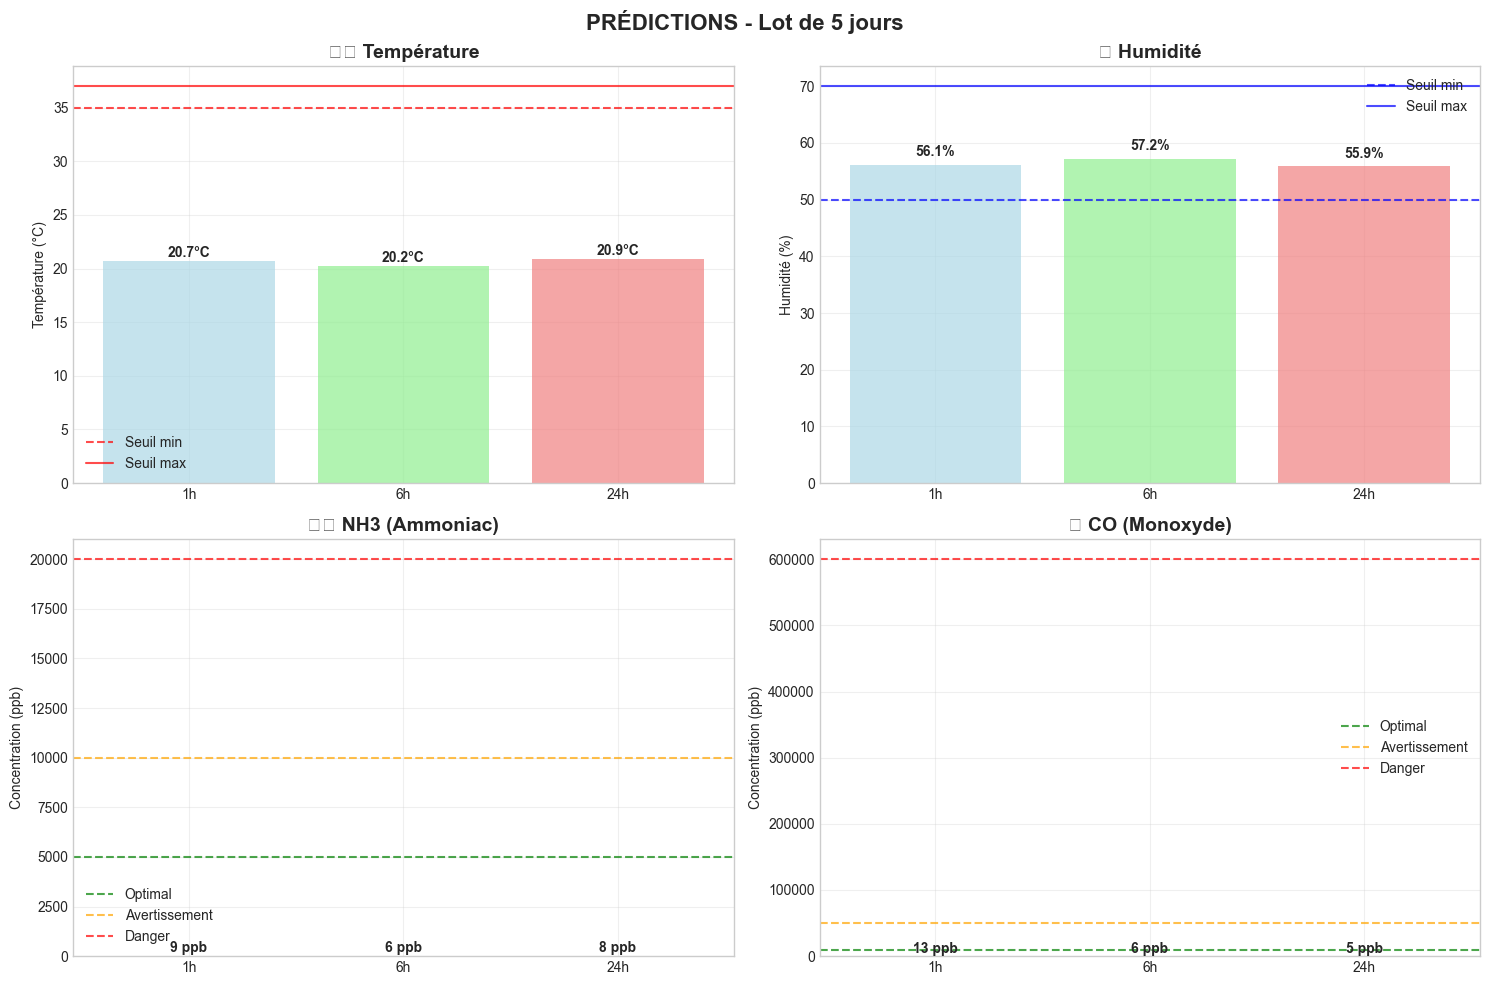


🐔 PRÉDICTIONS POUR LOT DE 15 JOURS:
------------------------------
   1h: Temp=20.7°C, Hum=56.1%, NH3=9ppb, CO=13ppb
   6h: Temp=20.2°C, Hum=57.2%, NH3=6ppb, CO=6ppb
   24h: Temp=20.9°C, Hum=55.9%, NH3=8ppb, CO=5ppb


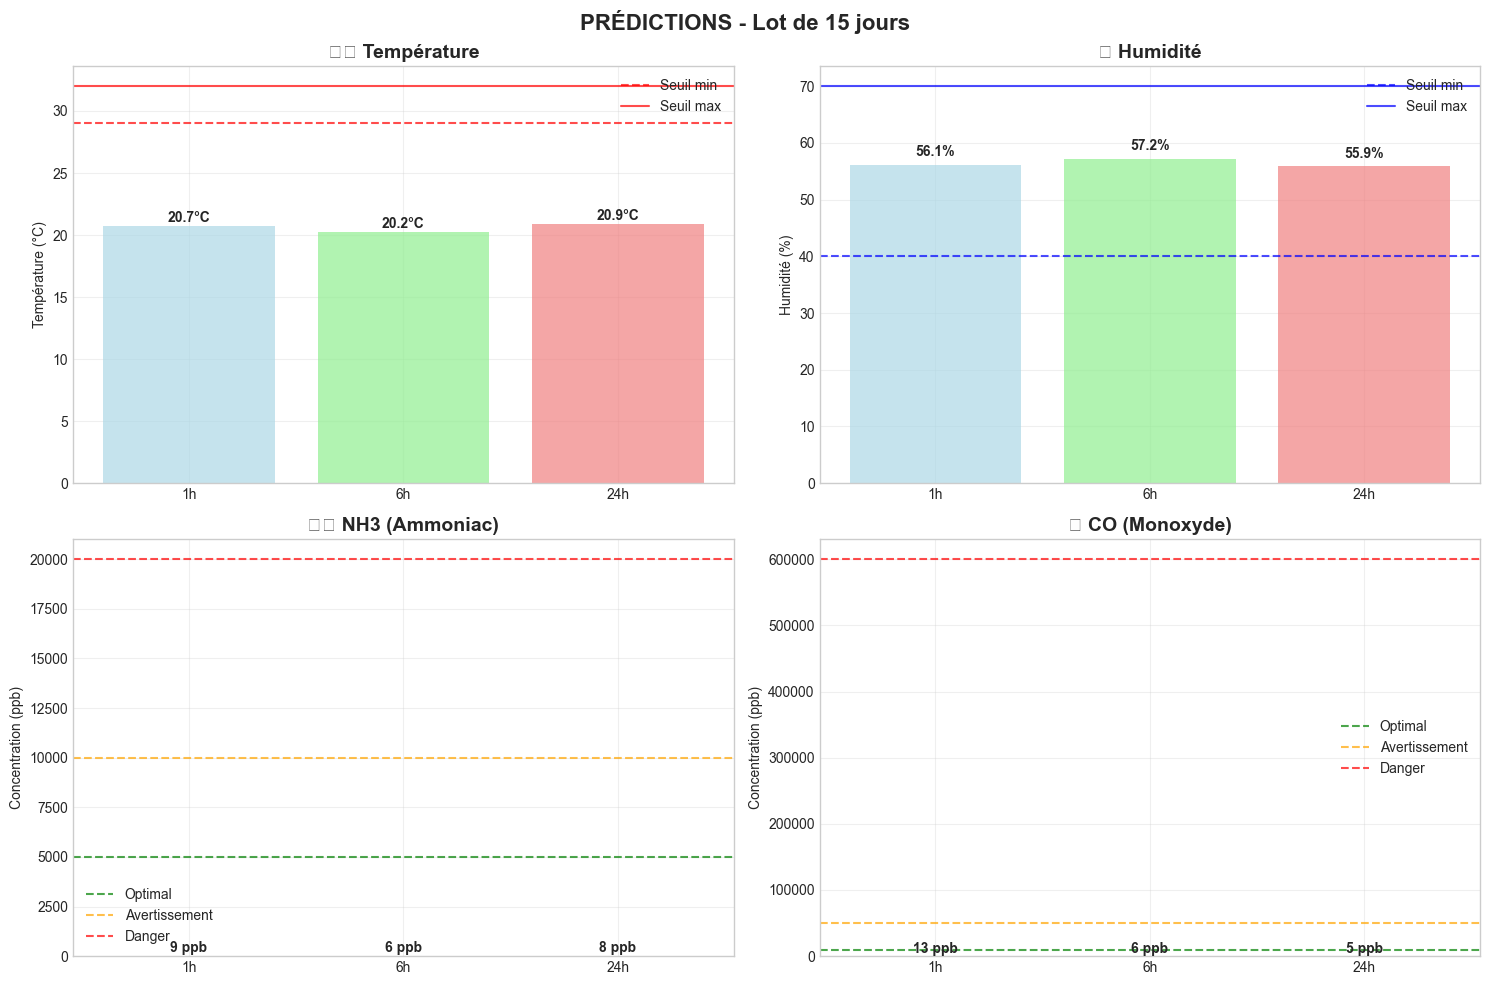


🐔 PRÉDICTIONS POUR LOT DE 25 JOURS:
------------------------------
   1h: Temp=20.7°C, Hum=56.1%, NH3=9ppb, CO=13ppb
   6h: Temp=20.2°C, Hum=57.2%, NH3=6ppb, CO=6ppb
   24h: Temp=20.9°C, Hum=55.9%, NH3=8ppb, CO=5ppb


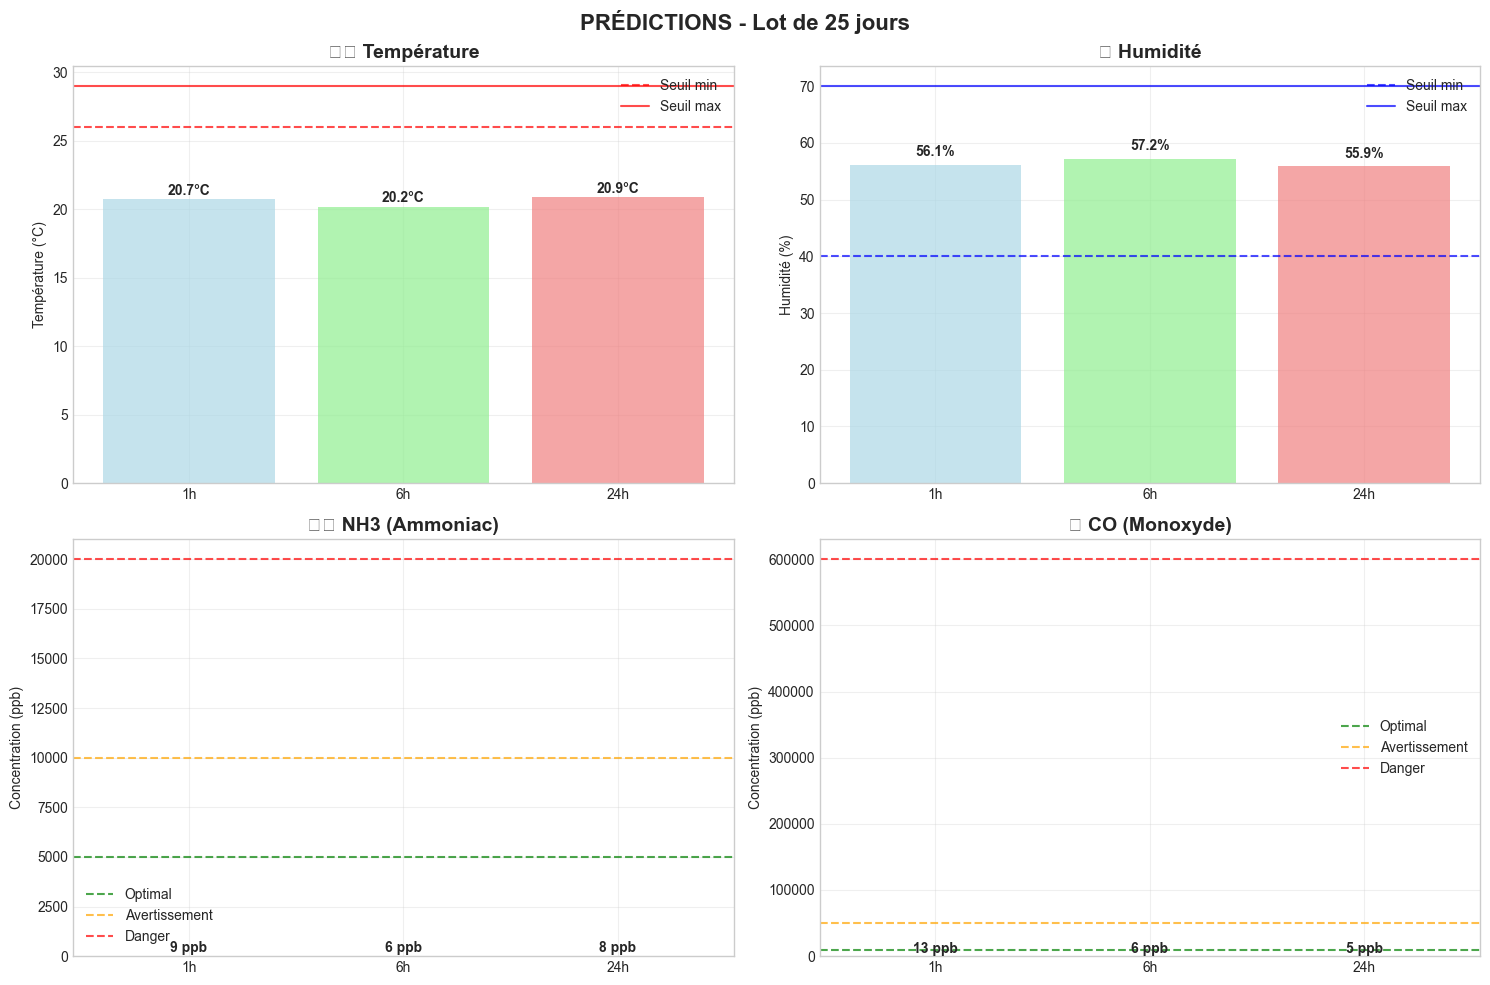


🐔 PRÉDICTIONS POUR LOT DE 40 JOURS:
------------------------------
   1h: Temp=20.7°C, Hum=56.1%, NH3=9ppb, CO=13ppb
   6h: Temp=20.2°C, Hum=57.2%, NH3=6ppb, CO=6ppb
   24h: Temp=20.9°C, Hum=55.9%, NH3=8ppb, CO=5ppb


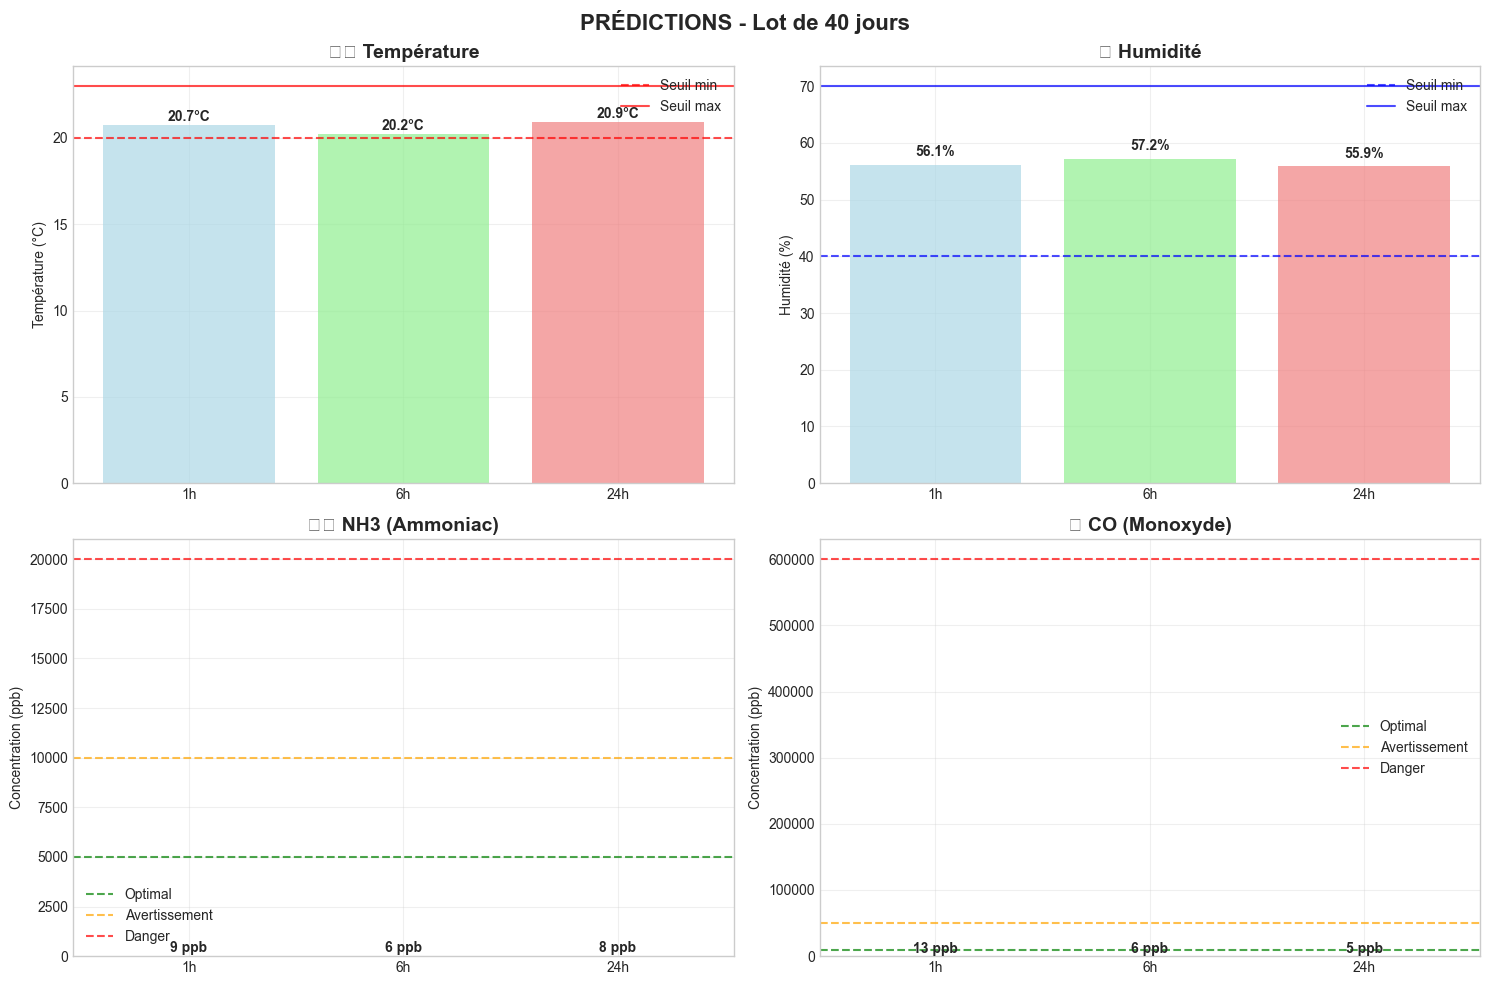


📈 Création du graphique d'évolution des seuils...


/var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/ipykernel_1957/602774261.py:197: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  plt.tight_layout()
/var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/ipykernel_1957/602774261.py:197: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
/var/folders/_b/hgh1rxn16cq0y0_k44qf57y80000gs/T/ipykernel_1957/602774261.py:197: UserWarning: Glyph 128167 (\N{DROPLET}) missing from current font.
  plt.tight_layout()


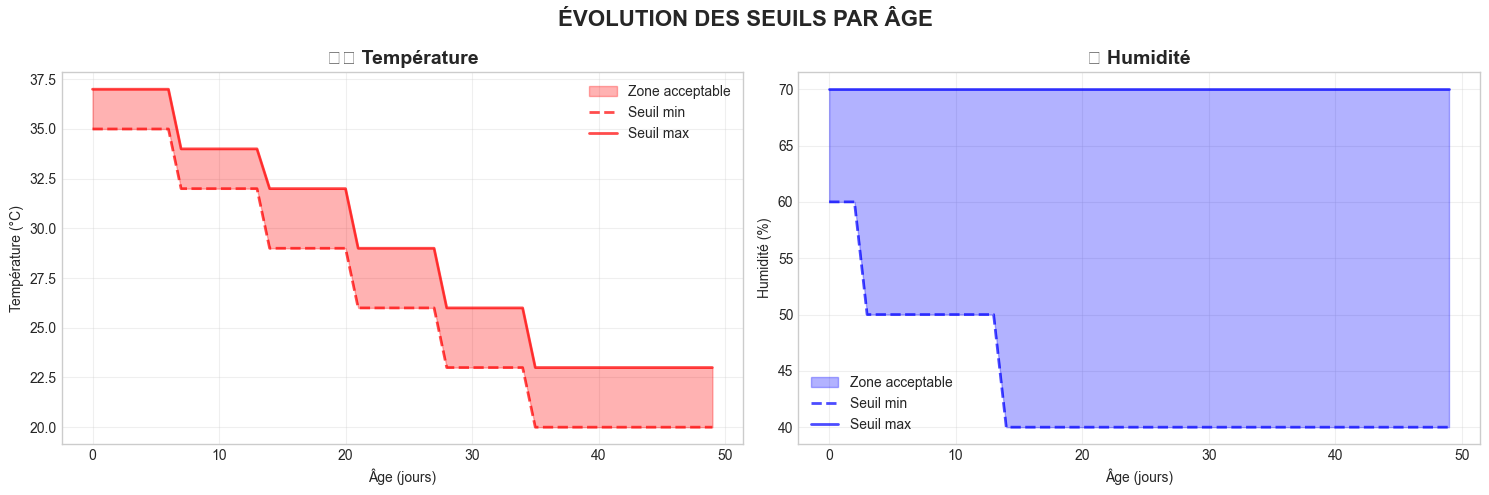


✅ Prêt pour les prédictions!
💡 Utilisez quick_predict() pour faire des prédictions rapides


In [78]:
# ✅ SYSTÈME DE PRÉDICTION SIMPLIFIÉ - GRAPHIQUES ESSENTIELS
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from datetime import datetime

# Configuration des styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1. CHARGEMENT DU MODÈLE
print("🔍 Chargement du modèle Deep Learning...")

try:
    best_model = tf.keras.models.load_model('saved_models_dl_comparison/BEST_DL_MODEL.h5')
    print("✅ Modèle chargé avec succès")
except Exception as e:
    print(f"❌ Erreur: {e}")
    raise

# 2. SYSTÈME DE SEUILS SIMPLIFIÉ
class SimpleThresholds:
    def __init__(self):
        self.thresholds = {
            'temperature': {
                (0, 7): (35, 37), (7, 14): (32, 34), (14, 21): (29, 32),
                (21, 28): (26, 29), (28, 35): (23, 26), (35, 1000): (20, 23)
            },
            'humidity': {
                (0, 3): (60, 70), (3, 14): (50, 70), (14, 1000): (40, 70)
            }
        }
    
    def get_thresholds(self, param, age_jours):
        for age_range, (min_val, max_val) in self.thresholds[param].items():
            if age_range[0] <= age_jours < age_range[1]:
                return min_val, max_val
        return 20, 23 if param == 'temperature' else 40, 70

# 3. PRÉDICTEUR SIMPLIFIÉ
class SimplePredictor:
    def __init__(self, model):
        self.model = model
        self.thresholds = SimpleThresholds()
    
    def predict_simple(self, input_data, age_jours, horizon='1h'):
        """Prédiction simple sans analyse complexe"""
        # Prétraitement basique (à adapter selon vos données)
        input_processed = input_data.reshape(1, 168, -1)
        
        # Prédiction
        predictions = self.model.predict(input_processed, verbose=0)[0]
        
        # Sélection de l'horizon
        horizon_indices = {'1h': [0,1,2,3], '6h': [4,5,6,7], '24h': [8,9,10,11]}[horizon]
        
        return {
            'temperature': float(predictions[horizon_indices[0]]),
            'humidity': float(predictions[horizon_indices[1]]),
            'nh3': float(predictions[horizon_indices[2]]),
            'co': float(predictions[horizon_indices[3]]),
            'age_jours': age_jours,
            'horizon': horizon
        }

# 4. GRAPHIQUES SIMPLIFIÉS
def create_simple_prediction_plot(predictions_dict, age_jours):
    """Crée un graphique simple des prédictions"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'PRÉDICTIONS - Lot de {age_jours} jours', fontsize=16, fontweight='bold')
    
    # Récupérer les seuils
    thresholds = SimpleThresholds()
    temp_min, temp_max = thresholds.get_thresholds('temperature', age_jours)
    hum_min, hum_max = thresholds.get_thresholds('humidity', age_jours)
    
    # Graphique Température
    horizons = list(predictions_dict.keys())
    temp_values = [predictions_dict[h]['temperature'] for h in horizons]
    
    bars = axes[0,0].bar(horizons, temp_values, color=['lightblue', 'lightgreen', 'lightcoral'], alpha=0.7)
    axes[0,0].axhline(y=temp_min, color='red', linestyle='--', alpha=0.7, label='Seuil min')
    axes[0,0].axhline(y=temp_max, color='red', linestyle='-', alpha=0.7, label='Seuil max')
    
    # Ajouter les valeurs sur les barres
    for bar, value in zip(bars, temp_values):
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                      f'{value:.1f}°C', ha='center', va='bottom', fontweight='bold')
    
    axes[0,0].set_title('🌡️ Température', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('Température (°C)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Graphique Humidité
    hum_values = [predictions_dict[h]['humidity'] for h in horizons]
    
    bars = axes[0,1].bar(horizons, hum_values, color=['lightblue', 'lightgreen', 'lightcoral'], alpha=0.7)
    axes[0,1].axhline(y=hum_min, color='blue', linestyle='--', alpha=0.7, label='Seuil min')
    axes[0,1].axhline(y=hum_max, color='blue', linestyle='-', alpha=0.7, label='Seuil max')
    
    for bar, value in zip(bars, hum_values):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                      f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    axes[0,1].set_title('💧 Humidité', fontsize=14, fontweight='bold')
    axes[0,1].set_ylabel('Humidité (%)')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Graphique NH3
    nh3_values = [predictions_dict[h]['nh3'] * 1000 for h in horizons]  # Conversion en ppb
    
    bars = axes[1,0].bar(horizons, nh3_values, color=['lightgreen', 'orange', 'red'], alpha=0.7)
    
    # Seuils NH3 (en ppb)
    axes[1,0].axhline(y=5 * 1000, color='green', linestyle='--', alpha=0.7, label='Optimal')
    axes[1,0].axhline(y=10 * 1000, color='orange', linestyle='--', alpha=0.7, label='Avertissement')
    axes[1,0].axhline(y=20 * 1000, color='red', linestyle='--', alpha=0.7, label='Danger')
    
    for bar, value in zip(bars, nh3_values):
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                      f'{value:.0f} ppb', ha='center', va='bottom', fontweight='bold')
    
    axes[1,0].set_title('☠️ NH3 (Ammoniac)', fontsize=14, fontweight='bold')
    axes[1,0].set_ylabel('Concentration (ppb)')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # Graphique CO
    co_values = [predictions_dict[h]['co'] * 1000 for h in horizons]  # Conversion en ppb
    
    bars = axes[1,1].bar(horizons, co_values, color=['lightgreen', 'orange', 'red'], alpha=0.7)
    
    # Seuils CO (en ppb)
    axes[1,1].axhline(y=10 * 1000, color='green', linestyle='--', alpha=0.7, label='Optimal')
    axes[1,1].axhline(y=50 * 1000, color='orange', linestyle='--', alpha=0.7, label='Avertissement')
    axes[1,1].axhline(y=600 * 1000, color='red', linestyle='--', alpha=0.7, label='Danger')
    
    for bar, value in zip(bars, co_values):
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                      f'{value:.0f} ppb', ha='center', va='bottom', fontweight='bold')
    
    axes[1,1].set_title('🔥 CO (Monoxyde)', fontsize=14, fontweight='bold')
    axes[1,1].set_ylabel('Concentration (ppb)')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def create_threshold_evolution_plot():
    """Graphique simple de l'évolution des seuils avec l'âge"""
    ages = np.arange(0, 50, 1)
    thresholds = SimpleThresholds()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('ÉVOLUTION DES SEUILS PAR ÂGE', fontsize=16, fontweight='bold')
    
    # Température
    temp_mins, temp_maxs = [], []
    for age in ages:
        min_temp, max_temp = thresholds.get_thresholds('temperature', age)
        temp_mins.append(min_temp)
        temp_maxs.append(max_temp)
    
    ax1.fill_between(ages, temp_mins, temp_maxs, alpha=0.3, color='red', label='Zone acceptable')
    ax1.plot(ages, temp_mins, 'r--', linewidth=2, label='Seuil min', alpha=0.7)
    ax1.plot(ages, temp_maxs, 'r-', linewidth=2, label='Seuil max', alpha=0.7)
    
    ax1.set_title('🌡️ Température', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Âge (jours)')
    ax1.set_ylabel('Température (°C)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Humidité
    hum_mins, hum_maxs = [], []
    for age in ages:
        min_hum, max_hum = thresholds.get_thresholds('humidity', age)
        hum_mins.append(min_hum)
        hum_maxs.append(max_hum)
    
    ax2.fill_between(ages, hum_mins, hum_maxs, alpha=0.3, color='blue', label='Zone acceptable')
    ax2.plot(ages, hum_mins, 'b--', linewidth=2, label='Seuil min', alpha=0.7)
    ax2.plot(ages, hum_maxs, 'b-', linewidth=2, label='Seuil max', alpha=0.7)
    
    ax2.set_title('💧 Humidité', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Âge (jours)')
    ax2.set_ylabel('Humidité (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 5. EXEMPLE D'UTILISATION
def demo_prediction_simple():
    """Démonstration simple de prédiction"""
    print("🎯 DÉMONSTRATION DE PRÉDICTION SIMPLIFIÉE")
    print("=" * 40)
    
    # Initialisation
    predictor = SimplePredictor(best_model)
    
    # Création de données d'exemple (à remplacer par vos vraies données)
    # Shape: (168 timesteps, nombre de features)
    example_data = np.random.randn(168, 47)  # 47 features comme dans votre modèle
    
    # Âges à tester
    test_ages = [5, 15, 25, 40]
    
    for age in test_ages:
        print(f"\n🐔 PRÉDICTIONS POUR LOT DE {age} JOURS:")
        print("-" * 30)
        
        # Prédictions pour les 3 horizons
        predictions = {}
        for horizon in ['1h', '6h', '24h']:
            try:
                pred = predictor.predict_simple(example_data, age, horizon)
                predictions[horizon] = pred
                
                print(f"   {horizon}: Temp={pred['temperature']:.1f}°C, "
                      f"Hum={pred['humidity']:.1f}%, "
                      f"NH3={pred['nh3']*1000:.0f}ppb, "
                      f"CO={pred['co']*1000:.0f}ppb")
                      
            except Exception as e:
                print(f"   ❌ Erreur {horizon}: {e}")
        
        # Création du graphique pour cet âge
        if predictions:
            create_simple_prediction_plot(predictions, age)
    
    # Graphique d'évolution des seuils
    print(f"\n📈 Création du graphique d'évolution des seuils...")
    create_threshold_evolution_plot()

# 6. FONCTION DE PRÉDICTION RAPIDE
def quick_predict(input_data, age_jours, horizon='1h'):
    """
    Fonction rapide pour faire une prédiction
    input_data: array de shape (168, nombre_de_features)
    age_jours: âge des volailles en jours
    horizon: '1h', '6h' ou '24h'
    """
    predictor = SimplePredictor(best_model)
    return predictor.predict_simple(input_data, age_jours, horizon)

# EXÉCUTION
if __name__ == "__main__":
    print("🚀 SYSTÈME DE PRÉDICTION SIMPLIFIÉ")
    print("=" * 35)
    
    # Lancement de la démonstration
    demo_prediction_simple()
    
    print(f"\n✅ Prêt pour les prédictions!")
    print("💡 Utilisez quick_predict() pour faire des prédictions rapides")

In [ ]:
# 1. Préparez vos données (168 timesteps × 47 features)
vos_donnees = np.random.randn(168, 47)  # Exemple

# 2. Faites une prédiction
resultat = quick_predict(vos_donnees, age_jours=25, horizon='1h')

# 3. Utilisez les résultats
print(f"🌡️  {resultat['temperature']:.1f}°C")
print(f"💧  {resultat['humidity']:.1f}%")

🌡️  20.1°C
💧  56.8%
